# Laboratorio 6 — Análisis de redes sociales (YouTube)

**Universidad del Valle de Guatemala — Facultad de Ingeniería**
Departamento de Ciencias de la Computación · **CC3084 Data Science** · Semestre II 2026

### Reproducibilidad

Ejecutar el notebook completo regenera todo: `outputs/tables/` (CSV), `outputs/figures/` (PNG) y
`data/processed/`. Las semillas están fijadas (`SEED = 42`), por lo que los *layouts* de red son
idénticos entre ejecuciones. Dependencias en `requirements.txt`.

## 0. Configuración del entorno

In [1]:
import re
import unicodedata
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

warnings.filterwarnings("ignore")

# --- Semilla global: layouts de red y cualquier muestreo son reproducibles ---
SEED = 42
np.random.seed(SEED)

# --- Rutas del proyecto ------------------------------------------------------
BASE = Path.cwd()
if not (BASE / "youtube_videos.csv").exists() and (BASE.parent / "youtube_videos.csv").exists():
    BASE = BASE.parent  # permite ejecutar el notebook desde una subcarpeta

DIR_FIG = BASE / "outputs" / "figures"
DIR_TAB = BASE / "outputs" / "tables"
DIR_PROC = BASE / "data" / "processed"
for d in (DIR_FIG, DIR_TAB, DIR_PROC):
    d.mkdir(parents=True, exist_ok=True)

# --- Estilo unificado de gráficos -------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "figure.facecolor": "white",
})
COL = {"autor": "#4C72B0", "video": "#DD8452", "acento": "#55A868",
       "alerta": "#C44E52", "gris": "#8C8C8C"}

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 70)


def guardar_fig(nombre):
    """Guarda la figura activa en outputs/figures/ con nombre estable."""
    plt.savefig(DIR_FIG / (nombre + ".png"))


def guardar_tabla(df, nombre, index=False):
    """Persiste una tabla de resultados en outputs/tables/ y la devuelve."""
    df.to_csv(DIR_TAB / (nombre + ".csv"), index=index, encoding="utf-8-sig")
    return df


print("Directorio base:", BASE)
print("pandas", pd.__version__, "| networkx", nx.__version__,
      "| matplotlib", matplotlib.__version__)

Directorio base: C:\Users\Cindy\OneDrive\Documents\GitHub\Laboratorio-6-Data-Science-
pandas 2.3.3 | networkx 3.6.1 | matplotlib 3.11.0


---
# 1. Carga, comprensión e integración de los datos

## 1.1. Carga de los archivos

Dos decisiones de lectura, ambas necesarias para no corromper las llaves:

- **`utf-8-sig`**: los archivos llevan BOM. Leídos como `utf-8` simple, la primera columna se
  llamaría `"﻿video_id"` y **todos los cruces por `video_id` fallarían en silencio**.
- **`dtype="string"` en los IDs**: evita que pandas infiera tipos numéricos en identificadores que
  empiezan por dígito o guion (p. ej. `-5puKGEqcUc`).

In [2]:
COLS_ID = ["video_id", "channel_id", "comment_id", "author_channel_id"]


def leer_csv(nombre):
    return pd.read_csv(BASE / nombre, encoding="utf-8-sig",
                       dtype={c: "string" for c in COLS_ID})


videos_raw = leer_csv("youtube_videos.csv")
comments_raw = leer_csv("youtube_comments.csv")

print("youtube_videos.csv   -> %4d filas x %2d columnas" % videos_raw.shape)
print("youtube_comments.csv -> %4d filas x %2d columnas" % comments_raw.shape)
print()
print("Columnas de videos      :", list(videos_raw.columns))
print()
print("Columnas de comentarios :", list(comments_raw.columns))

youtube_videos.csv   ->  293 filas x 20 columnas
youtube_comments.csv ->  406 filas x 17 columnas

Columnas de videos      : ['video_id', 'title', 'channel_name', 'channel_id', 'source_query', 'source_group', 'dataset_sources', 'channel_handle', 'published_time', 'view_count_text', 'description_snippet', 'video_url', 'query_hits', 'keywords', 'description', 'view_count', 'publish_date', 'upload_date', 'category', 'owner_handle']

Columnas de comentarios : ['video_id', 'comment_id', 'video_title', 'channel_name', 'channel_id', 'author_name', 'author_channel_id', 'text', 'source_query', 'source_group', 'dataset_sources', 'author_handle', 'published_text', 'like_count_text', 'reply_count', 'is_pinned', 'viewer_rating']


In [3]:
videos_raw.head(3)

,video_id,title,channel_name,channel_id,source_query,source_group,dataset_sources,channel_handle,published_time,view_count_text,description_snippet,video_url,query_hits,keywords,description,view_count,publish_date,upload_date,category,owner_handle
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias para el fin de semana e...,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,guatemala lluvias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatem...,/@T13NoticiasGuatemala,hace 2 días,"2,390 vistas",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en ...,https://www.youtube.com/watch?v=-5puKGEqcUc,"[""guatemala lluvias""]","[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno del Niño"", ""Guatema...",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en ...,2357,2026-08-28T22:00:20-07:00,2026-08-28T22:00:20-07:00,News & Politics,/@T13NoticiasGuatemala
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO EL FIN DE UNA ETAPA...,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,@GobiernodelaRepublicadeGuatema,topic,youtube_target_channels.csv,/@iDocumenta,hace 3 meses,4 vistas,"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio d...",https://www.youtube.com/watch?v=-E7OPOLjMug,"[""@GobiernodelaRepublicadeGuatema""]",[],"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio d...",4,2026-05-13T16:00:03-07:00,2026-05-13T16:00:03-07:00,People & Blogs,/@iDocumenta
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado por Guatemala... 🔔,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatem...,/@M%C3%A9xicoPoder,hace 1 día,"29,736 vistas",México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéxi...,https://www.youtube.com/watch?v=-KDglrIzRKo,"[""guatemala noticias""]","[""Mexico recupera petroleo"", ""petroleo robado Guatemala"", ""huachic...",#México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéx...,29736,2026-08-29T17:00:38-07:00,2026-08-29T17:00:38-07:00,People & Blogs,/@M%C3%A9xicoPoder


In [4]:
comments_raw.head(3)

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la ...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | yout...,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados de mujer señalados d...,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guatemala_plus_comments.csv,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,Me dejaron con ganas de demandar la ilegalidad de las reuniones vi...,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | yout...,/@iamjimalesssa,hace 1 año,4,0,False,NaN


Las dimensiones coinciden exactamente con lo declarado en el enunciado (293 videos × 20 variables;
406 comentarios × 17 variables), por lo que la lectura no perdió ni duplicó filas.

## 1.2. Unidad de observación, llave primaria y variables relevantes

In [5]:
def verificar_llave(df, llave):
    """Comprueba que una columna se comporte efectivamente como llave primaria."""
    return {
        "archivo_columna": llave,
        "filas": len(df),
        "valores_unicos": int(df[llave].nunique()),
        "nulos": int(df[llave].isna().sum()),
        "duplicados": int(df[llave].duplicated().sum()),
        "es_llave_primaria": bool(df[llave].is_unique and df[llave].notna().all()),
    }


chequeo_llaves = pd.DataFrame([
    verificar_llave(videos_raw, "video_id"),
    verificar_llave(comments_raw, "comment_id"),
])
guardar_tabla(chequeo_llaves, "t1_2_llaves_primarias")
chequeo_llaves

,archivo_columna,filas,valores_unicos,nulos,duplicados,es_llave_primaria
0,video_id,293,293,0,0,True
1,comment_id,406,406,0,0,True


### Resultado

| Archivo | Unidad de observación | Llave primaria |
|---|---|---|
| `youtube_videos.csv` | Un video | `video_id` — 293 únicos, sin nulos ni duplicados ✔ |
| `youtube_comments.csv` | Un comentario de primer nivel | `comment_id` — 406 únicos, sin nulos ni duplicados ✔ |

La unidad es el **comentario de primer nivel**, no el hilo: las respuestas no son filas, sólo se
cuentan en `reply_count`.

### Variables relevantes

| Rol | En videos | En comentarios |
|---|---|---|
| Identificadores | `video_id` (PK), `channel_id` | `comment_id` (PK), `video_id`, `author_channel_id`, `channel_id` |
| Etiquetas visibles | `title`, `channel_name`, `channel_handle` | `author_name`, `author_handle`, `video_title` |
| Métricas | `view_count`, `view_count_text` | `like_count_text`, `reply_count` |
| Contenido | `title`, `description`, `keywords` | `text` |
| Clasificación | `category`, `source_group` | `source_group` |
| Muestreo | `source_query`, `query_hits` | `source_query` |
| Temporales | `publish_date` (ISO), `published_time` (relativa) | `published_text` (relativa) |
| Sin uso | `upload_date`, `owner_handle` (redundantes) | `is_pinned` (constante), `viewer_rating` (vacía) |

> **Distinción crítica:** en comentarios, `channel_id` es el canal **dueño del video**;
> `author_channel_id` es **quien escribió el comentario**. Confundirlos invalidaría toda la red.

In [6]:
# Evidencia de que ambos conjuntos de entidades son disjuntos en estos datos
canales_dueños = set(comments_raw["channel_id"].dropna())
autores = set(comments_raw["author_channel_id"].dropna())

print("Canales dueños de video presentes en comentarios :", len(canales_dueños))
print("Autores de comentarios                           :", len(autores))
print("Intersección entre ambos conjuntos               :", len(canales_dueños & autores))


Canales dueños de video presentes en comentarios : 8
Autores de comentarios                           : 332
Intersección entre ambos conjuntos               : 0


La intersección es vacía: **ningún canal comentó en sus propios videos** dentro de esta muestra.
Esto confirma que autores y canales son poblaciones separadas y que la red bipartita no mezclará
tipos de entidad por error.

### Descripción de cada relación

| # | Relación | Llave | Card. | Nota |
|---|---|---|---|---|
| 1 | Canal → Video | `channel_id` | 1:N | El ID es estable; nombre y handle son mutables |
| 2 | Video → Comentario | `video_id` | 1:N | Llave foránea que une ambos archivos |
| 3 | Autor → Comentario | `author_channel_id` | 1:N | Un autor puede comentar varias veces, incluso en el mismo video |
| 4 | **Autor ↔ Video** | derivada de 2 y 3 | N:M | **Única relación de red observable**; base de la sección 4 |
| 5 | Video → Categoría | `category` | N:1 | Etiqueta de YouTube: describe el video, no sus comentarios |
| 6 | Video ↔ Consulta | `source_query`, `query_hits` | N:M | Describe **cómo se encontró** el video, no su tema |


In [7]:
resumen_entidades = pd.DataFrame([
    {"entidad": "Canal (dueño del video)", "identificador": "channel_id",
     "n_en_videos": videos_raw["channel_id"].nunique(),
     "n_en_comentarios": comments_raw["channel_id"].nunique()},
    {"entidad": "Video", "identificador": "video_id",
     "n_en_videos": videos_raw["video_id"].nunique(),
     "n_en_comentarios": comments_raw["video_id"].nunique()},
    {"entidad": "Comentario", "identificador": "comment_id",
     "n_en_videos": np.nan, "n_en_comentarios": comments_raw["comment_id"].nunique()},
    {"entidad": "Autor de comentario", "identificador": "author_channel_id",
     "n_en_videos": np.nan, "n_en_comentarios": comments_raw["author_channel_id"].nunique()},
    {"entidad": "Categoría", "identificador": "category",
     "n_en_videos": videos_raw["category"].nunique(), "n_en_comentarios": np.nan},
    {"entidad": "Consulta de búsqueda", "identificador": "source_query",
     "n_en_videos": videos_raw["source_query"].nunique(),
     "n_en_comentarios": comments_raw["source_query"].nunique()},
])
guardar_tabla(resumen_entidades, "t1_3_entidades")
resumen_entidades

,entidad,identificador,n_en_videos,n_en_comentarios
0,Canal (dueño del video),channel_id,97.0,8.0
1,Video,video_id,293.0,19.0
2,Comentario,comment_id,NaN,406.0
3,Autor de comentario,author_channel_id,NaN,332.0
4,Categoría,category,11.0,NaN
5,Consulta de búsqueda,source_query,21.0,6.0


## 1.4. Integración por `video_id` y cobertura del cruce

**`LEFT JOIN`** de comentarios sobre videos. Se conserva el lado izquierdo a propósito, para
**detectar y reportar** comentarios huérfanos en vez de perderlos en silencio como haría un
`INNER JOIN`. `validate="many_to_one"` falla si `video_id` no fuera único en videos: verificación
activa contra duplicación.

Las columnas redundantes de comentarios (`video_title`, `channel_name`, `channel_id`) se traen
también desde videos con sufijo `_video`, para comprobar su consistencia antes de descartarlas.

In [8]:
COLS_VIDEO_JOIN = [
    "video_id", "title", "channel_id", "channel_name", "channel_handle",
    "category", "view_count", "source_group", "source_query", "publish_date",
]

integrado = comments_raw.merge(
    videos_raw[COLS_VIDEO_JOIN],
    on="video_id", how="left", suffixes=("", "_video"), validate="many_to_one",
)

n_total = len(comments_raw)
n_emparejados = int(integrado["title"].notna().sum())
n_huerfanos = n_total - n_emparejados

videos_con_com = comments_raw["video_id"].nunique()
videos_sin_com = videos_raw["video_id"].nunique() - videos_con_com

cobertura = pd.DataFrame([
    ["Comentarios totales", n_total, 1.0],
    ["Comentarios asociados a un video del archivo", n_emparejados, n_emparejados / n_total],
    ["Comentarios huérfanos (video_id sin correspondencia)", n_huerfanos, n_huerfanos / n_total],
    ["Videos totales en youtube_videos.csv", len(videos_raw), 1.0],
    ["Videos CON al menos un comentario recolectado", videos_con_com, videos_con_com / len(videos_raw)],
    ["Videos SIN comentarios recolectados", videos_sin_com, videos_sin_com / len(videos_raw)],
], columns=["indicador", "n", "proporcion"])
cobertura["porcentaje"] = cobertura["proporcion"].map(lambda x: f"{x:.1%}")

guardar_tabla(cobertura, "t1_4_cobertura_join")
cobertura[["indicador", "n", "porcentaje"]]

,indicador,n,porcentaje
0,Comentarios totales,406,100.0%
1,Comentarios asociados a un video del archivo,406,100.0%
2,Comentarios huérfanos (video_id sin correspondencia),0,0.0%
3,Videos totales en youtube_videos.csv,293,100.0%
4,Videos CON al menos un comentario recolectado,19,6.5%
5,Videos SIN comentarios recolectados,274,93.5%


In [9]:
# Verificación activa de la integridad del join
assert integrado["comment_id"].is_unique, "El join duplicó comentarios"
assert len(integrado) == len(comments_raw), "El join alteró el número de filas"
print("Integridad del join verificada: 1 fila por comentario, sin duplicación.\n")

# ¿Las columnas redundantes coinciden con las del archivo de videos?
consistencia_join = pd.DataFrame([
    {"columna_en_comentarios": "video_title", "columna_en_videos": "title",
     "coincidencia": (integrado["video_title"] == integrado["title"]).mean()},
    {"columna_en_comentarios": "channel_id", "columna_en_videos": "channel_id_video",
     "coincidencia": (integrado["channel_id"] == integrado["channel_id_video"]).mean()},
    {"columna_en_comentarios": "channel_name", "columna_en_videos": "channel_name_video",
     "coincidencia": (integrado["channel_name"] == integrado["channel_name_video"]).mean()},
])
consistencia_join["coincidencia"] = consistencia_join["coincidencia"].map(lambda x: f"{x:.1%}")
guardar_tabla(consistencia_join, "t1_4_consistencia_redundantes")
consistencia_join

Integridad del join verificada: 1 fila por comentario, sin duplicación.



,columna_en_comentarios,columna_en_videos,coincidencia
0,video_title,title,100.0%
1,channel_id,channel_id_video,100.0%
2,channel_name,channel_name_video,100.0%


### Hallazgos del cruce

- **406 comentarios (100 %) se asociaron con un video.** Sin huérfanos: integridad referencial
  perfecta.
- **Sólo 19 de 293 videos (6.5 %) tienen comentarios recolectados.**
- Las columnas redundantes coinciden al **100 %** con las de videos: misma extracción, se pueden
  descartar sin pérdida.

In [10]:
# ¿De qué consultas provienen los comentarios? Evidencia directa del sesgo de muestreo.
origen_comentarios = (
    comments_raw.groupby(["source_group", "source_query"])
    .agg(n_comentarios=("comment_id", "count"),
         n_videos=("video_id", "nunique"),
         n_autores=("author_channel_id", "nunique"))
    .reset_index()
    .sort_values("n_comentarios", ascending=False)
)
origen_comentarios["pct_comentarios"] = (
    origen_comentarios["n_comentarios"] / len(comments_raw)).map(lambda x: f"{x:.1%}")

guardar_tabla(origen_comentarios, "t1_4_origen_comentarios")
origen_comentarios

,source_group,source_query,n_comentarios,n_videos,n_autores,pct_comentarios
0,channel,@quorumgt/videos,231,11,192,56.9%
5,topic,guatemala noticias,55,5,47,13.5%
3,topic,Gobierno de la República de Guatemala,45,1,32,11.1%
1,topic,@GobiernodeGuatemala,25,1,19,6.2%
2,topic,@quorumgt,25,1,24,6.2%
4,topic,Municipalidad de Guatemala,25,1,25,6.2%


La tabla anterior muestra que **el 63 % de los comentarios provienen de un solo canal**
(`@quorumgt`, sumando las consultas `@quorumgt/videos` y `@quorumgt`). Éste es el sesgo de
muestreo más importante del conjunto y debe tenerse presente al interpretar cualquier resultado
sobre "la conversación en YouTube Guatemala": lo que se observa es, en gran medida, **la
conversación alrededor de un canal específico de periodismo**, no una muestra representativa.

---
# 2. Calidad, limpieza y preprocesamiento

## 2.1. Diagnóstico inicial de calidad

Se construye un perfil columna por columna que reporta, para cada variable: tipo observado,
cantidad y porcentaje de faltantes, número de valores distintos, si la variable es **constante**
(un solo valor, sin poder informativo) y un valor de ejemplo. Sobre esa base se examinan después
duplicados, valores atípicos y consistencia entre identificadores, nombres y *handles*.

In [11]:
def perfil_calidad(df, nombre_df):
    """Perfil de calidad columna por columna."""
    filas = []
    for c in df.columns:
        s = df[c]
        no_nulos = int(s.notna().sum())
        # Un texto compuesto sólo de espacios se considera vacío en la práctica
        if s.dtype == object or str(s.dtype) == "string":
            vacios_texto = int(s.fillna("").astype(str).str.strip().eq("").sum())
        else:
            vacios_texto = 0
        n_unicos = int(s.nunique(dropna=True))
        ejemplo = s.dropna()
        ejemplo = str(ejemplo.iloc[0])[:45] if len(ejemplo) else ""
        filas.append({
            "dataset": nombre_df,
            "variable": c,
            "tipo_pandas": str(s.dtype),
            "no_nulos": no_nulos,
            "faltantes": int(s.isna().sum()),
            "pct_faltantes": round(100 * s.isna().mean(), 2),
            "vacios_o_espacios": vacios_texto,
            "n_unicos": n_unicos,
            "es_constante": bool(n_unicos <= 1),
            "ejemplo": ejemplo,
        })
    return pd.DataFrame(filas)


perfil_videos = perfil_calidad(videos_raw, "youtube_videos")
perfil_comments = perfil_calidad(comments_raw, "youtube_comments")
perfil = pd.concat([perfil_videos, perfil_comments], ignore_index=True)

guardar_tabla(perfil, "t2_1_perfil_calidad")
perfil_videos

,dataset,variable,tipo_pandas,no_nulos,faltantes,pct_faltantes,vacios_o_espacios,n_unicos,es_constante,ejemplo
0,youtube_videos,video_id,string,293,0,0.00,0,293,False,-5puKGEqcUc
1,youtube_videos,title,object,293,0,0.00,0,274,False,INSIVUMEH pronostica incremento de lluvias pa
2,youtube_videos,channel_name,object,293,0,0.00,0,97,False,T13 Noticias Guatemala
3,youtube_videos,channel_id,string,293,0,0.00,0,97,False,UCq0Cm-3SKthEySQc2JZBi1A
4,youtube_videos,source_query,object,293,0,0.00,0,21,False,guatemala lluvias
5,youtube_videos,source_group,object,293,0,0.00,0,3,False,topic
6,youtube_videos,dataset_sources,object,293,0,0.00,0,23,False,youtube_guatemala.csv | youtube_guatemala_lab
7,youtube_videos,channel_handle,object,293,0,0.00,0,97,False,/@T13NoticiasGuatemala
8,youtube_videos,published_time,object,280,13,4.44,13,80,False,hace 2 días
9,youtube_videos,view_count_text,object,280,13,4.44,13,259,False,"2,390 vistas"


In [12]:
perfil_comments

,dataset,variable,tipo_pandas,no_nulos,faltantes,pct_faltantes,vacios_o_espacios,n_unicos,es_constante,ejemplo
0,youtube_comments,video_id,string,406,0,0.0,0,19,False,j43HgwYFKfk
1,youtube_comments,comment_id,string,406,0,0.0,0,406,False,Ugw-J65a1iYL9hqhELh4AaABAg
2,youtube_comments,video_title,object,406,0,0.0,0,19,False,La cooptación de Walter Mazariegos en la USAC
3,youtube_comments,channel_name,object,406,0,0.0,0,8,False,Quorum
4,youtube_comments,channel_id,string,406,0,0.0,0,8,False,UCE4rsXcgDb6e1-a9iTbWzfg
5,youtube_comments,author_name,object,406,0,0.0,0,332,False,@MarcosCarillo-b1r
6,youtube_comments,author_channel_id,string,406,0,0.0,0,332,False,UCdFlugHJJa4l3YqWuNRmvXw
7,youtube_comments,text,object,406,0,0.0,0,404,False,Ese corrupto amigo de la vieja fiscal los ten
8,youtube_comments,source_query,object,406,0,0.0,0,6,False,@quorumgt
9,youtube_comments,source_group,object,406,0,0.0,0,2,False,topic


293 valores para el id del video y la fecha de publicación, mientras que existen 406 registros únicos del id de comentario.

### 2.1.a Faltantes

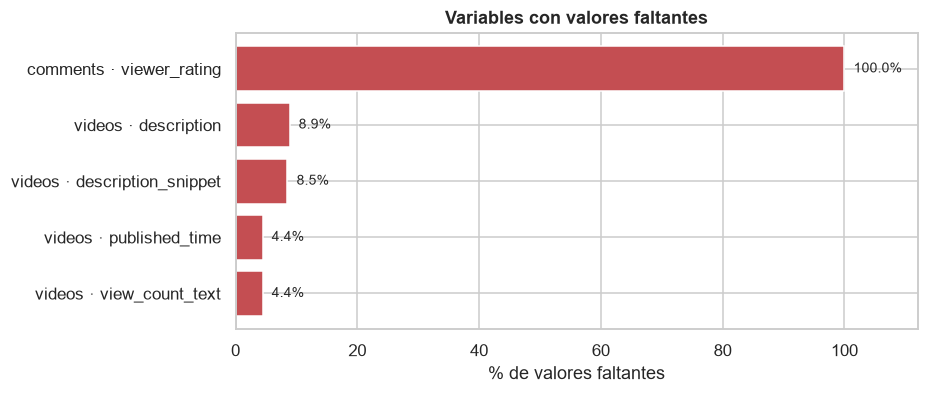

,dataset,variable,faltantes,pct_faltantes,n_unicos
36,youtube_comments,viewer_rating,406,100.00,0
14,youtube_videos,description,26,8.87,234
10,youtube_videos,description_snippet,25,8.53,236
8,youtube_videos,published_time,13,4.44,80
9,youtube_videos,view_count_text,13,4.44,259


In [13]:
faltantes = perfil[perfil["faltantes"] > 0].sort_values("pct_faltantes", ascending=False)
faltantes_disp = faltantes[["dataset", "variable", "faltantes", "pct_faltantes", "n_unicos"]]
guardar_tabla(faltantes_disp, "t2_1_faltantes")

fig, ax = plt.subplots(figsize=(8, 3.5))
etiquetas = faltantes_disp["dataset"].str.replace("youtube_", "") + " · " + faltantes_disp["variable"]
ax.barh(etiquetas, faltantes_disp["pct_faltantes"], color=COL["alerta"])
ax.invert_yaxis()
ax.set_xlabel("% de valores faltantes")
ax.set_title("Variables con valores faltantes")
for y, v in enumerate(faltantes_disp["pct_faltantes"]):
    ax.text(v + 1.5, y, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, 112)
guardar_fig("f2_1_faltantes")
plt.show()

faltantes_disp

**Lectura de los faltantes**

| Variable | Faltantes | Tratamiento |
|---|---|---|
| `viewer_rating` | 406 (100 %) | Se elimina: no aporta información. |
| `description` | 26 (8.9 %) | Se imputa con cadena vacía; **la fila no se elimina**, el resto del video es válido. |
| `description_snippet` | 25 (8.5 %) | Redundante con `description`; sólo respaldo. |
| `published_time` | 13 (4.4 %) | Irrelevante: `publish_date` (ISO 8601) está completa. |
| `view_count_text` | 13 (4.4 %) | Sin impacto: `view_count` está completa en los 293 videos. |

**Ningún faltante afecta a las llaves** (`video_id`, `comment_id`, `author_channel_id`,
`channel_id`), completas al 100 %: la construcción de la red no se ve comprometida.

### 2.1.b Duplicados

In [14]:
dups = pd.DataFrame([
    {"dataset": "youtube_videos", "criterio": "fila completa idéntica",
     "n_duplicados": int(videos_raw.duplicated().sum())},
    {"dataset": "youtube_videos", "criterio": "video_id repetido",
     "n_duplicados": int(videos_raw["video_id"].duplicated().sum())},
    {"dataset": "youtube_videos", "criterio": "video_url repetida",
     "n_duplicados": int(videos_raw["video_url"].duplicated().sum())},
    {"dataset": "youtube_videos", "criterio": "title repetido (distinto video)",
     "n_duplicados": int(videos_raw["title"].duplicated().sum())},
    {"dataset": "youtube_comments", "criterio": "fila completa idéntica",
     "n_duplicados": int(comments_raw.duplicated().sum())},
    {"dataset": "youtube_comments", "criterio": "comment_id repetido",
     "n_duplicados": int(comments_raw["comment_id"].duplicated().sum())},
    {"dataset": "youtube_comments", "criterio": "texto del comentario repetido",
     "n_duplicados": int(comments_raw["text"].duplicated().sum())},
    {"dataset": "youtube_comments", "criterio": "mismo autor + mismo video (comentarios múltiples)",
     "n_duplicados": int(comments_raw.duplicated(subset=["author_channel_id", "video_id"]).sum())},
])
guardar_tabla(dups, "t2_1_duplicados")
dups

,dataset,criterio,n_duplicados
0,youtube_videos,fila completa idéntica,0
1,youtube_videos,video_id repetido,0
2,youtube_videos,video_url repetida,0
3,youtube_videos,title repetido (distinto video),19
4,youtube_comments,fila completa idéntica,0
5,youtube_comments,comment_id repetido,0
6,youtube_comments,texto del comentario repetido,2
7,youtube_comments,mismo autor + mismo video (comentarios múltiples),63


In [15]:
# Los títulos repetidos NO son errores: son videos distintos con el mismo título
tit_rep = videos_raw[videos_raw["title"].duplicated(keep=False)].sort_values("title")
print("Videos con título repetido:", tit_rep["title"].nunique(),
      "títulos afectando a", len(tit_rep), "videos distintos\n")
display(tit_rep[["video_id", "title", "channel_name", "publish_date", "view_count"]].head(8))

# Los textos de comentario repetidos: ¿mismo autor o autores distintos?
txt_rep = comments_raw[comments_raw["text"].duplicated(keep=False)].sort_values("text")
display(txt_rep[["comment_id", "author_channel_id", "video_id", "text"]])

Videos con título repetido: 8 títulos afectando a 27 videos distintos



,video_id,title,channel_name,publish_date,view_count
273,vDVXM8ODuzM,#EnVivoDCA | Conferencia de Prensa del Gobierno de Guatemala,Diario de Centro América,2026-08-06T00:51:20-07:00,214
263,tEfZlrP4L5I,#EnVivoDCA | Conferencia de Prensa del Gobierno de Guatemala,Diario de Centro América,2026-08-10T21:38:33-07:00,265
178,Z_pWnOi7oRw,#EnVivoDCA | Conferencia de prensa del Gobierno de Guatemala,Diario de Centro América,2026-05-12T01:25:56-07:00,1329
144,RjG-y7Y2-k4,#EnVivoDCA | Conferencia de prensa del Gobierno de Guatemala,Diario de Centro América,2026-04-21T00:14:15-07:00,239
225,iWYddxEszoM,#EnVivoDCA | Conferencia de prensa del Gobierno de Guatemala,Diario de Centro América,2026-07-02T00:57:24-07:00,264
108,K1IA6oTGws8,#EnVivoDCA | Conferencia de prensa del Gobierno de Guatemala,Diario de Centro América,2026-04-28T00:34:45-07:00,530
89,FU5zLTb4inc,#EnVivoDCA | Conferencia de prensa del Gobierno de Guatemala,Diario de Centro América,2026-04-13T20:32:05-07:00,549
147,SryjaiL2B4Q,#EnVivoDCA | Conferencia de prensa del Gobierno de Guatemala,Diario de Centro América,2026-06-16T00:41:24-07:00,352


,comment_id,author_channel_id,video_id,text
116,Ugx8FxDKPAY-M_JhRgd4AaABAg,UCi1b_TRQfgO1Z9O2gNGGWNA,n8iP75gIpmw,Ahora se destapo la CORRUPCION Q EXISTIA Y AHORA SE CONTAMINO desp...
324,Ugz7WPxTOQEwmZpnx_V4AaABAg,UCi1b_TRQfgO1Z9O2gNGGWNA,n8iP75gIpmw,Ahora se destapo la CORRUPCION Q EXISTIA Y AHORA SE CONTAMINO desp...
112,Ugx74OPnWkWaFjpFuA94AaABAg.A7ki-1ED5b2A7nIcG2_svP,UCFjudnPLoaSL1BaRuLahyHg,n8iP75gIpmw,Cierto.
272,Ugy__nsWCBggw9EzOUd4AaABAg.A7lbRpGUZoHA7nJxaD37u-,UCFjudnPLoaSL1BaRuLahyHg,n8iP75gIpmw,Cierto.


**Conclusión sobre duplicados**

- **Ninguna fila duplicada exacta** ni identificador repetido en los dos archivos.
- Los **títulos repetidos** son videos distintos (`video_id` y fecha diferentes): noticieros diarios
  con el mismo nombre de programa.
- Los **textos repetidos** provienen de autores o videos distintos: expresiones cortas frecuentes,
  no registros duplicados.

> Decisión: **no se elimina ninguna fila por duplicación.** Hacerlo por texto repetido sesgaría a la
> baja la participación de los autores más recurrentes.

### 2.1.c Variables constantes

In [16]:
constantes = perfil[perfil["es_constante"]][
    ["dataset", "variable", "n_unicos", "no_nulos", "ejemplo"]]
guardar_tabla(constantes, "t2_1_constantes")

# Variables casi constantes: un valor concentra >95% de los registros
casi = []
for df, nom in [(videos_raw, "youtube_videos"), (comments_raw, "youtube_comments")]:
    for c in df.columns:
        vc = df[c].value_counts(dropna=True)
        if len(vc) > 1 and vc.iloc[0] / max(len(df), 1) > 0.95:
            casi.append({"dataset": nom, "variable": c,
                         "valor_dominante": str(vc.index[0])[:40],
                         "pct_dominante": round(100 * vc.iloc[0] / len(df), 1)})
casi_constantes = pd.DataFrame(casi)
guardar_tabla(casi_constantes, "t2_1_casi_constantes")

print("VARIABLES CONSTANTES (un solo valor):")
display(constantes)
print("\nVARIABLES CASI CONSTANTES (>95% un solo valor):")
display(casi_constantes if len(casi_constantes) else "Ninguna")

VARIABLES CONSTANTES (un solo valor):


,dataset,variable,n_unicos,no_nulos,ejemplo
35,youtube_comments,is_pinned,1,406,False
36,youtube_comments,viewer_rating,0,0,



VARIABLES CASI CONSTANTES (>95% un solo valor):


'Ninguna'

In [17]:
# Pares de columnas redundantes: ¿son idénticas en el 100% de los registros?
redundancias = pd.DataFrame([
    {"par": "videos: upload_date vs publish_date",
     "coincidencia": (videos_raw["upload_date"] == videos_raw["publish_date"]).mean()},
    {"par": "videos: owner_handle vs channel_handle",
     "coincidencia": (videos_raw["owner_handle"] == videos_raw["channel_handle"]).mean()},
    {"par": "comentarios: author_handle vs '/@'+author_name",
     "coincidencia": (comments_raw["author_handle"].str.lstrip("/@")
                      == comments_raw["author_name"].str.lstrip("@")).mean()},
])
redundancias["coincidencia"] = redundancias["coincidencia"].map(lambda x: f"{x:.1%}")
guardar_tabla(redundancias, "t2_1_redundancias")
redundancias

,par,coincidencia
0,videos: upload_date vs publish_date,100.0%
1,videos: owner_handle vs channel_handle,100.0%
2,comentarios: author_handle vs '/@'+author_name,96.6%


**Variables constantes y redundantes detectadas**

| Variable | Situación | Tratamiento |
|---|---|---|
| `viewer_rating` | 100 % nula | **Eliminar.** Sin varianza y sin contenido. |
| `is_pinned` | Constante `False` en los 406 registros | **Eliminar del análisis.** No distingue comentarios; en particular, no se puede estudiar el efecto de fijar comentarios. |
| `upload_date` | Idéntica a `publish_date` en el 100 % | **Eliminar** una de las dos; se conserva `publish_date`. |
| `owner_handle` | Idéntica a `channel_handle` en el 100 % | **Eliminar** una de las dos; se conserva `channel_handle`. |
| `video_title`, `channel_name`, `channel_id` (en comentarios) | Recuperables por el `JOIN` con videos (§1.4, coincidencia 100 %) | Redundantes; se conservan sólo por trazabilidad. |

### 2.1.d Consistencia entre identificadores, nombres y *handles*

Se comprueba si la correspondencia ID ↔ nombre ↔ handle es **biunívoca**. Dos fallos posibles:

- un mismo ID asociado a **varios** nombres (el canal/usuario cambió de nombre durante la
  recolección), o
- un mismo nombre asociado a **varios** IDs (homónimos, o suplantación).

In [18]:
def consistencia_id(df, col_id, col_etiqueta, etiqueta_legible):
    ids_multi = df.groupby(col_id)[col_etiqueta].nunique()
    etq_multi = df.groupby(col_etiqueta)[col_id].nunique()
    return {
        "relación": etiqueta_legible,
        "n_ids": int(df[col_id].nunique()),
        "n_etiquetas": int(df[col_etiqueta].nunique()),
        "ids_con_mas_de_1_etiqueta": int((ids_multi > 1).sum()),
        "etiquetas_con_mas_de_1_id": int((etq_multi > 1).sum()),
        "biunivoca": bool((ids_multi <= 1).all() and (etq_multi <= 1).all()),
    }


consistencia = pd.DataFrame([
    consistencia_id(videos_raw, "channel_id", "channel_name", "channel_id ↔ channel_name"),
    consistencia_id(videos_raw, "channel_id", "channel_handle", "channel_id ↔ channel_handle"),
    consistencia_id(comments_raw, "author_channel_id", "author_name", "author_channel_id ↔ author_name"),
    consistencia_id(comments_raw, "author_channel_id", "author_handle", "author_channel_id ↔ author_handle"),
    consistencia_id(comments_raw, "video_id", "video_title", "video_id ↔ video_title"),
])
guardar_tabla(consistencia, "t2_1_consistencia_ids")
consistencia

,relación,n_ids,n_etiquetas,ids_con_mas_de_1_etiqueta,etiquetas_con_mas_de_1_id,biunivoca
0,channel_id ↔ channel_name,97,97,0,0,True
1,channel_id ↔ channel_handle,97,97,0,0,True
2,author_channel_id ↔ author_name,332,332,0,0,True
3,author_channel_id ↔ author_handle,332,332,0,0,True
4,video_id ↔ video_title,19,19,0,0,True


**Resultado:** todas las correspondencias son **biunívocas**. Ningún canal ni autor cambió de nombre
durante la recolección, ni hay nombres compartidos por cuentas distintas.

Esto **no autoriza a sustituir los IDs por nombres**: la biunivocidad es propiedad de *esta muestra*,
no una garantía de YouTube. Los nombres se usan sólo como etiquetas (§2.3).

### 2.1.e Valores atípicos

Se examinan las tres variables cuantitativas del conjunto: `view_count` (videos), y `reply_count`
y los "me gusta" (comentarios). Se usa el criterio de Tukey (1.5 × RIC) tanto en escala original
como en escala logarítmica, porque las métricas de audiencia siguen distribuciones fuertemente
asimétricas en las que el criterio en escala original marca como "atípico" casi cualquier valor
alto legítimo.

In [19]:
def resumen_atipicos(serie, nombre):
    s = pd.to_numeric(serie, errors="coerce").dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    ric = q3 - q1
    lim_sup = q3 + 1.5 * ric
    # Mismo criterio sobre log1p, apropiado para distribuciones muy asimétricas
    ls = np.log1p(s)
    lq1, lq3 = ls.quantile([0.25, 0.75])
    lric = lq3 - lq1
    lim_sup_log = np.expm1(lq3 + 1.5 * lric)
    return {
        "variable": nombre, "n": len(s),
        "min": s.min(), "mediana": s.median(), "media": round(s.mean(), 1), "max": s.max(),
        "p95": s.quantile(0.95), "asimetria": round(float(s.skew()), 2),
        "lim_sup_Tukey": round(float(lim_sup), 1),
        "n_atipicos_Tukey": int((s > lim_sup).sum()),
        "lim_sup_Tukey_log": round(float(lim_sup_log), 1),
        "n_atipicos_log": int((s > lim_sup_log).sum()),
    }


# La conversión formal de like_count_text ocurre en 2.4; aquí sólo se necesita el valor numérico
likes_prov = pd.to_numeric(
    comments_raw["like_count_text"].astype(str).str.replace(r"[^\d]", "", regex=True)
    .replace("", np.nan), errors="coerce").fillna(0)

atipicos = pd.DataFrame([
    resumen_atipicos(videos_raw["view_count"], "view_count (videos)"),
    resumen_atipicos(comments_raw["reply_count"], "reply_count (comentarios)"),
    resumen_atipicos(likes_prov, "me gusta (comentarios)"),
])
guardar_tabla(atipicos, "t2_1_atipicos")
atipicos

,variable,n,min,mediana,media,max,p95,asimetria,lim_sup_Tukey,n_atipicos_Tukey,lim_sup_Tukey_log,n_atipicos_log
0,view_count (videos),293,2.0,1175.0,60430.1,8190449.0,130467.0,14.26,18340.0,49,1517186.8,2
1,reply_count (comentarios),406,0.0,0.0,0.1,7.0,1.0,7.20,0.0,30,0.0,30
2,me gusta (comentarios),406,0.0,1.0,5.7,405.0,14.0,9.88,5.0,48,14.6,19


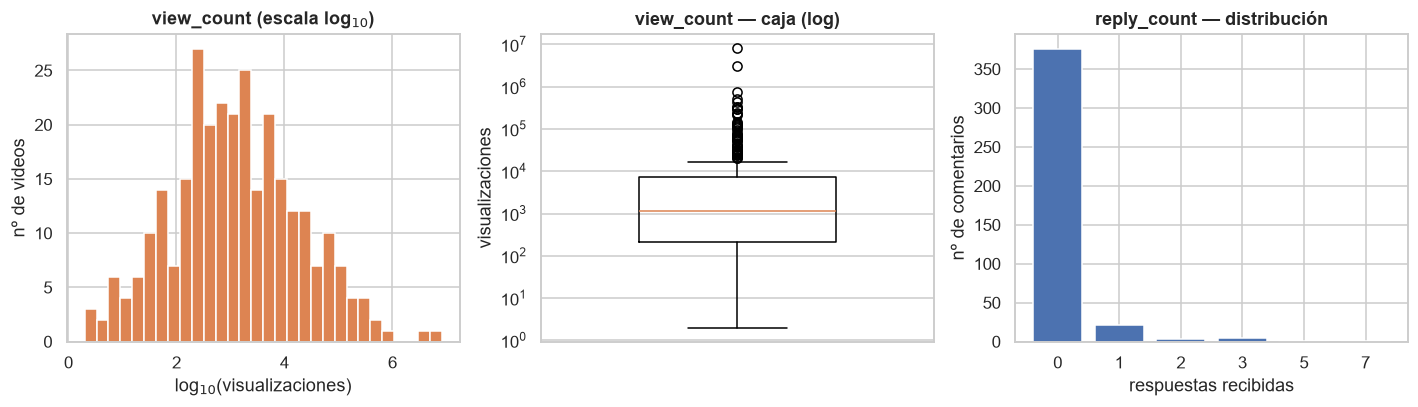

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

vc = videos_raw["view_count"]
axes[0].hist(np.log10(vc.clip(lower=1)), bins=30, color=COL["video"], edgecolor="white")
axes[0].set_title("view_count (escala log$_{10}$)")
axes[0].set_xlabel("log$_{10}$(visualizaciones)")
axes[0].set_ylabel("nº de videos")

axes[1].boxplot(vc, vert=True, widths=0.5)
axes[1].set_yscale("log")
axes[1].set_title("view_count — caja (log)")
axes[1].set_ylabel("visualizaciones")
axes[1].set_xticks([])

conteo_rep = comments_raw["reply_count"].value_counts().sort_index()
axes[2].bar(conteo_rep.index.astype(str), conteo_rep.values, color=COL["autor"])
axes[2].set_title("reply_count — distribución")
axes[2].set_xlabel("respuestas recibidas")
axes[2].set_ylabel("nº de comentarios")

plt.tight_layout()
guardar_fig("f2_1_atipicos")
plt.show()

In [21]:
top_views = (videos_raw.nlargest(8, "view_count")
             [["video_id", "title", "channel_name", "category", "view_count", "source_group"]])
guardar_tabla(top_views, "t2_1_top_views")
top_views

,video_id,title,channel_name,category,view_count,source_group
148,THY2YBne3QE,"Los ALUCINANTES autobuses de Guatemala | ""Burras""",Luisito Comunica,Comedy,8190449,topic
245,n4xHxJPNr78,🚫LOS FAMOSOS BUSES ESMERALDA los mas RÁPIDOS DE GUATEMALA 😱,De todo Gt,People & Blogs,3152619,topic
113,KkNQhX_kg8A,🇬🇹HISTORIA de GUATEMALA en 17 minutos🇬🇹 - El Mapa de Sebas,El Mapa de Sebas,Education,749356,topic
56,Aa7hIDCRh3g,Este BUS me LLEVO a UN PARAISO EN GUATEMALA,De todo Gt,People & Blogs,504374,topic
126,NnKpTEfhWjI,✅ ASÍ es una EXHIBICION DE BUSES EN GUATEMALA,De todo Gt,Travel & Events,424874,topic
180,_1VIxOLyaUQ,Sonido de trafico y ciudad 💤 ruido de calle para dormir bebés y re...,Ambient Sound Explorer,Entertainment,330057,topic
159,VfBrLONPnFM,ME quité el MIEDO de viajar en los buses de GUATEMALA 🔥,De todo Gt,People & Blogs,329489,topic
182,_Lcbi4NCHRA,Tercer Informe General de la República,Gobierno de Guatemala,News & Politics,305269,topic


**Lectura de los atípicos**

- `view_count` abarca **7 órdenes de magnitud** (de 2 a 8 190 449), con mediana 1 175 y media
  60 430: la media está inflada por unos pocos videos masivos. Es una distribución de **ley de
  potencias**, esperable en plataformas de contenido.
- Tukey en escala original marca decenas de atípicos; en **escala logarítmica** caen drásticamente.
  Los valores altos son **la cola natural**, no errores.
- **Decisión: no se elimina ni recorta ningún atípico.** Los videos más vistos son los casos
  interesantes. En su lugar se usa **escala logarítmica y correlaciones de rango (Spearman)**,
  robustas a la asimetría.
- `reply_count` es casi siempre 0 (máximo 7). No se usa como arista; sólo describe la discusión
  derivada.

### 2.1.f Coherencia interna de los conteos: `view_count` vs `view_count_text`

El enunciado recomienda usar `view_count`. Se verifica si ambas versiones coinciden, porque una
discrepancia sistemática revelaría algo sobre el procedimiento de recolección.

In [22]:
cmp_views = videos_raw.dropna(subset=["view_count_text"]).copy()
cmp_views["vistas_desde_texto"] = (
    cmp_views["view_count_text"].str.replace(r"[^\d]", "", regex=True).astype(int))
cmp_views["difiere"] = cmp_views["vistas_desde_texto"] != cmp_views["view_count"]
cmp_views["dif_relativa"] = (
    (cmp_views["vistas_desde_texto"] - cmp_views["view_count"]) / cmp_views["view_count"])

n_dif = int(cmp_views["difiere"].sum())
print(f"Videos comparables (view_count_text no nulo) : {len(cmp_views)}")
print(f"Videos donde ambos conteos difieren          : {n_dif} ({n_dif/len(cmp_views):.1%})")
print(f"Diferencia relativa mediana en esos casos    : "
      f"{cmp_views.loc[cmp_views['difiere'], 'dif_relativa'].abs().median():.4%}")
print(f"Diferencia relativa máxima                   : "
      f"{cmp_views.loc[cmp_views['difiere'], 'dif_relativa'].abs().max():.2%}")

display(cmp_views.loc[cmp_views["difiere"],
        ["video_id", "view_count_text", "vistas_desde_texto", "view_count", "dif_relativa"]].head(6))

Videos comparables (view_count_text no nulo) : 280
Videos donde ambos conteos difieren          : 53 (18.9%)
Diferencia relativa mediana en esos casos    : 0.0509%
Diferencia relativa máxima                   : 40.00%


,video_id,view_count_text,vistas_desde_texto,view_count,dif_relativa
0,-5puKGEqcUc,"2,390 vistas",2390,2357,0.014001
5,0LTLUY7LBlA,"6,098 vistas",6098,6099,-0.000164
6,0a4_g1R1-aA,"15,436 vistas",15436,15455,-0.001229
16,2iqOSL9YguA,"5,180 vistas",5180,5181,-0.000193
25,3onMfRym3OU,"4,485 vistas",4485,4484,0.000223
27,4DD1nlxWk2s,"27,107 vistas",27107,27111,-0.000148


El 19 % de los videos discrepa entre ambos conteos, pero la magnitud es **minúscula**
(mediana ≈ 0.004 %: unas pocas visualizaciones). Los dos campos se capturaron en **momentos
ligeramente distintos** del *scraping*, y las vistas siguen acumulándose entre uno y otro.

> Es evidencia empírica directa de una limitación que el enunciado exige discutir: **los conteos son
> una fotografía del instante de recolección, no valores definitivos.** Se adopta `view_count` como
> fuente única.

## 2.2. Variables que no pueden utilizarse o requieren precauciones

| Variable | Problema | Tratamiento |
|---|---|---|
| `viewer_rating` | 100 % vacía | **Descartada.** Imputarla inventaría datos. |
| `is_pinned` | Constante `False` | **Descartada.** Sin varianza, no diferencia nada. |
| `reply_count` | Cuenta respuestas pero **no identifica autores** | **Prohibido usarla como arista**; sólo atributo descriptivo. Tratarla como vínculo autor–autor crearía una red inexistente. |
| `published_time`, `published_text` | Fechas **relativas**, dependientes del instante de recolección | **No convertidas a fecha absoluta**: "hace 1 año" cubre 365 días. Uso sólo ordinal. Para videos se usa `publish_date` (ISO 8601, exacta). |
| `like_count_text` | Texto; 189 registros con espacio en blanco | Convertida a entero (§2.4); el espacio = **0 me gusta** (YouTube oculta el contador en cero). |
| `view_count_text` | Texto con millares, 13 faltantes, discrepa de `view_count` (§2.1.f) | Se usa `view_count` como fuente única. |
| `source_query`, `source_group`, `query_hits` | Describen el **muestreo**, no el tema | Sólo para caracterizar el sesgo de recolección, nunca como variable temática. |
| `channel_name`, `author_name`, handles | Etiquetas visibles y **mutables** | **Nunca como identificador**; sólo etiqueta, junto al ID estable (§2.3). |
| `category` | Asignada por YouTube al video; hay noticias etiquetadas `Entertainment` | Se reporta como etiqueta de plataforma, no como clasificación temática validada. |
| `keywords` | **162 de 293 (55 %) tienen lista vacía** | Se parsea, pero **no se usa como base principal de temas**. |
| `description_snippet` | Truncamiento de `description` | Descartada por redundante; `description` se imputa con cadena vacía. |
| `upload_date`, `owner_handle` | Duplican al 100 % a `publish_date` y `channel_handle` | **Descartadas.** |
| `text` | Emojis, URL, menciones, ortografía informal | Íntegro en `texto_original` (auditoría y sentimiento); normalizado en `texto_limpio` (§2.5–2.6). |

## 2.3. Normalización de identificadores y nombres

**Principio rector: los identificadores nunca se sustituyen por nombres visibles.** `channel_id`,
`video_id`, `comment_id` y `author_channel_id` siguen siendo las llaves; los nombres se normalizan
sólo como etiquetas legibles.

| Sobre | Operaciones |
|---|---|
| **Identificadores** | Recorte de espacios; verificación de no-vacíos; **se preserva el uso de mayúsculas** — los IDs de YouTube las distinguen (`UCa...` ≠ `uca...`) y un `lower()` los corrompería |
| **Nombres y handles** | NFKC; colapso de espacios; handle canónico sin `/@` en columna nueva (`*_handle_norm`), dejando el original intacto |

In [23]:
def norm_id(s):
    """Normalización conservadora de identificadores: NO altera mayúsculas."""
    return s.astype("string").str.strip()


def norm_nombre(s):
    """Normalización de etiquetas visibles: NFKC + colapso de espacios."""
    return (s.astype("string")
            .map(lambda x: unicodedata.normalize("NFKC", x) if pd.notna(x) else x)
            .str.replace(r"\s+", " ", regex=True)
            .str.strip())


def norm_handle(s):
    """Handle canónico: sin prefijo '/@' ni '@', en minúsculas (los handles no distinguen caso)."""
    return (norm_nombre(s)
            .str.replace(r"^/?@?", "", regex=True)
            .str.lower())


videos = videos_raw.copy()
comments = comments_raw.copy()

for col in ["video_id", "channel_id"]:
    videos[col] = norm_id(videos[col])
for col in ["video_id", "comment_id", "channel_id", "author_channel_id"]:
    comments[col] = norm_id(comments[col])

for col in ["channel_name", "title"]:
    videos[col] = norm_nombre(videos[col])
videos["channel_handle_norm"] = norm_handle(videos["channel_handle"])

for col in ["author_name", "channel_name", "video_title"]:
    comments[col] = norm_nombre(comments[col])
comments["author_handle_norm"] = norm_handle(comments["author_handle"])

# Verificaciones posteriores a la normalización
assert videos["video_id"].is_unique and videos["video_id"].notna().all()
assert comments["comment_id"].is_unique and comments["comment_id"].notna().all()
assert comments["video_id"].isin(videos["video_id"]).all(), "Se rompió la integridad referencial"
assert (videos["video_id"].str.len() > 0).all()

print("Normalización aplicada sin romper llaves ni integridad referencial.\n")
print("IDs conservados como llaves : video_id, channel_id, comment_id, author_channel_id")
print("Etiquetas normalizadas      : channel_name, title, author_name, video_title")
print("Handles canónicos añadidos  : channel_handle_norm, author_handle_norm")
print()
display(comments[["author_channel_id", "author_name", "author_handle",
                  "author_handle_norm"]].head(5))

Normalización aplicada sin romper llaves ni integridad referencial.

IDs conservados como llaves : video_id, channel_id, comment_id, author_channel_id
Etiquetas normalizadas      : channel_name, title, author_name, video_title
Handles canónicos añadidos  : channel_handle_norm, author_handle_norm



,author_channel_id,author_name,author_handle,author_handle_norm
0,UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,/@MarcosCarillo-b1r,marcoscarillo-b1r
1,UCvl1tzQeBeGy6efPTRJXSCw,@RaulPerez-cw2vi,/@RaulPerez-cw2vi,raulperez-cw2vi
2,UCRAquv8el-tQ30bN7MlmySQ,@iamjimalesssa,/@iamjimalesssa,iamjimalesssa
3,UCkbsS_3D-pvg1iHOld9uvIg,@gonzalo6075,/@gonzalo6075,gonzalo6075
4,UCOLHH4ZpMxPYF-Q6e6wvn5A,@luisroldan7374,/@luisroldan7374,luisroldan7374


In [24]:
# ¿La normalización de handles provocó colisiones entre autores distintos?
colision = comments.groupby("author_handle_norm")["author_channel_id"].nunique()
print("Handles normalizados que colisionan (mismo handle, distinto ID):",
      int((colision > 1).sum()))
print("→ Las etiquetas siguen siendo distinguibles; aun así, la llave de la red es "
      "author_channel_id, no el handle.")

Handles normalizados que colisionan (mismo handle, distinto ID): 0
→ Las etiquetas siguen siendo distinguibles; aun así, la llave de la red es author_channel_id, no el handle.


## 2.4. Conversión a numérico de los conteos almacenados como texto

Dos variables de conteo llegan como texto: `view_count_text` y `like_count_text`. Se implementa un
convertidor explícito que documenta cada caso.

### Reglas de conversión

| Caso | Ejemplo | Regla |
|---|---|---|
| Separador de millares | `"2,390 vistas"` | Se elimina la coma (o el punto) → `2390` |
| Sufijo textual | `" vistas"`, `" visualizaciones"` | Se elimina |
| **Abreviaturas** | `"1.2 mil"`, `"3.4 M"`, `"12 K"` | ×10³ / ×10⁶. **Verificado: 0 casos en estos datos**; la regla queda implementada por reproducibilidad |
| **Cadena en blanco** | `" "` (189 en `like_count_text`) | → **0**: YouTube omite el contador cuando vale cero |
| Nulo | 13 en `view_count_text` | Faltante, **no 0**: se desconoce el valor |
| Texto no numérico | *no presente* | Faltante, contabilizado como inválido |

> **Distinción deliberada entre "cero" y "desconocido".** En `like_count_text` el blanco es un cero
> informativo; en `view_count_text` el `NaN` es ausencia de dato. Igualarlos metería 13 ceros falsos
> en la variable de popularidad.

In [25]:
MULTIPLICADORES = {"mil": 1_000, "k": 1_000, "m": 1_000_000, "mm": 1_000_000,
                   "millones": 1_000_000, "millón": 1_000_000, "b": 1_000_000_000}

PAT_ABREV = re.compile(r"([\d.,]+)\s*(mil|millones|millón|k|mm|m|b)\b", re.IGNORECASE)


def texto_a_entero(valor, vacio_es_cero=False):
    """
    Convierte un conteo en texto a entero.

    vacio_es_cero=True  -> "" o "   " se interpretan como 0 (caso like_count_text).
    vacio_es_cero=False -> "" o NaN quedan como faltante (caso view_count_text).

    Devuelve (valor, motivo) para poder auditar cada conversión.
    """
    if valor is None or (isinstance(valor, float) and np.isnan(valor)):
        return (0, "vacio_a_cero") if vacio_es_cero else (np.nan, "nulo")

    s = unicodedata.normalize("NFKC", str(valor)).strip().lower()
    if s == "":
        return (0, "vacio_a_cero") if vacio_es_cero else (np.nan, "vacio_a_nulo")

    s = re.sub(r"\b(vistas?|visualizaciones|views?|reproducciones)\b", "", s).strip()

    m = PAT_ABREV.search(s)
    if m:
        num = m.group(1).replace(".", "X").replace(",", ".").replace("X", "")
        try:
            return int(round(float(num) * MULTIPLICADORES[m.group(2)])), "abreviatura"
        except ValueError:
            return np.nan, "abreviatura_invalida"

    solo_digitos = re.sub(r"[^\d]", "", s)          # elimina comas/puntos de millares
    if solo_digitos == "":
        return (0, "vacio_a_cero") if vacio_es_cero else (np.nan, "no_numerico")
    return int(solo_digitos), "entero_directo"


# --- Aplicación a los comentarios ("me gusta") -------------------------------
conv_likes = comments["like_count_text"].map(lambda v: texto_a_entero(v, vacio_es_cero=True))
comments["like_count"] = [v for v, _ in conv_likes]
motivo_likes = pd.Series([m for _, m in conv_likes], name="motivo")

# --- Aplicación a los videos (visualizaciones desde texto) -------------------
conv_views = videos["view_count_text"].map(lambda v: texto_a_entero(v, vacio_es_cero=False))
videos["view_count_from_text"] = [v for v, _ in conv_views]
motivo_views = pd.Series([m for _, m in conv_views], name="motivo")

auditoria_conv = pd.concat([
    motivo_likes.value_counts().rename("like_count_text (comentarios)"),
    motivo_views.value_counts().rename("view_count_text (videos)"),
], axis=1).fillna(0).astype(int).reset_index().rename(columns={"index": "motivo"})

guardar_tabla(auditoria_conv, "t2_4_auditoria_conversion")
auditoria_conv

,motivo,like_count_text (comentarios),view_count_text (videos)
0,entero_directo,217,280
1,vacio_a_cero,189,0
2,nulo,0,13


In [26]:
# Pruebas del convertidor, incluyendo formatos no presentes en los datos
pruebas = ["2,390 vistas", "8,190,449 vistas", "1.2 mil vistas", "3.4 M", "12 K",
           "  ", "", None, "sin datos", "45"]
tabla_pruebas = pd.DataFrame(
    [{"entrada": repr(p),
      "como_like (vacío=0)": texto_a_entero(p, True),
      "como_view (vacío=NaN)": texto_a_entero(p, False)} for p in pruebas])
guardar_tabla(tabla_pruebas, "t2_4_pruebas_conversion")
tabla_pruebas

,entrada,como_like (vacío=0),como_view (vacío=NaN)
0,"'2,390 vistas'","(2390, entero_directo)","(2390, entero_directo)"
1,"'8,190,449 vistas'","(8190449, entero_directo)","(8190449, entero_directo)"
2,'1.2 mil vistas',"(12000, abreviatura)","(12000, abreviatura)"
3,'3.4 M',"(34000000, abreviatura)","(34000000, abreviatura)"
4,'12 K',"(12000, abreviatura)","(12000, abreviatura)"
5,' ',"(0, vacio_a_cero)","(nan, vacio_a_nulo)"
6,'',"(0, vacio_a_cero)","(nan, vacio_a_nulo)"
7,None,"(0, vacio_a_cero)","(nan, nulo)"
8,'sin datos',"(0, vacio_a_cero)","(nan, no_numerico)"
9,'45',"(45, entero_directo)","(45, entero_directo)"


In [27]:
print("MÉ GUSTA (like_count) tras la conversión")
print(comments["like_count"].describe().round(2).to_string())
print(f"\nComentarios con 0 me gusta : {(comments['like_count'] == 0).sum()} "
      f"({(comments['like_count'] == 0).mean():.1%})")
print(f"Máximo de me gusta         : {comments['like_count'].max()}")
print(f"Total de me gusta          : {int(comments['like_count'].sum())}")

# view_count ya venía numérica y completa: se usa como fuente única
videos["view_count"] = pd.to_numeric(videos["view_count"], errors="coerce").astype("Int64")
print(f"\nview_count numérica, faltantes: {int(videos['view_count'].isna().sum())}")

MÉ GUSTA (like_count) tras la conversión
count    406.00
mean       5.73
std       30.66
min        0.00
25%        0.00
50%        1.00
75%        2.00
max      405.00

Comentarios con 0 me gusta : 189 (46.6%)
Máximo de me gusta         : 405
Total de me gusta          : 2325

view_count numérica, faltantes: 0


## 2.5. Creación de `texto_original` y `texto_limpio`

| Columna | Contenido | Uso |
|---|---|---|
| `texto_original` | `text` **sin modificación alguna** | Auditoría y **análisis de sentimiento** |
| `texto_norm` | Minúsculas, sin URL/menciones/emojis/puntuación/dígitos, **con palabras vacías** | Inspección intermedia: permite auditar qué se perdió |
| `texto_limpio` | **Lemas** sin palabras vacías ni acentos | Frecuencias, bigramas, nubes |

Los elementos retirados se extraen a columnas propias (`urls`, `hashtags`, `menciones`, `emojis`) en
lugar de descartarse. **Nada se pierde: todo se relocaliza.**

## 2.6. Decisiones documentadas para `texto_limpio`

| # | Decisión | Justificación |
|---|---|---|
| 1 | Normalización **NFKC** | Unifica caracteres visualmente idénticos con codificaciones distintas. |
| 2 | **Minúsculas** | Evita contar `Gobierno`/`gobierno`/`GOBIERNO` como tres términos. Coste: se pierde el énfasis en mayúsculas, conservado en `texto_original`. |
| 3 | **URL fuera** (→ `urls`) | No son vocabulario; contaminarían las frecuencias con fragmentos de dominio. |
| 4 | **Hashtags separados** (→ `hashtags`) | `#Guatemala` y `Guatemala` son el mismo concepto; el *camelCase* (`#ParoNacional`) se divide en palabras. |
| 5 | **Menciones `@` fuera** (→ `menciones`) | Referencian una cuenta, no contenido; si no, los nombres de usuario dominarían las frecuencias. Se extraen como evidencia de interacción dirigida, aunque no permiten reconstruir la red. |
| 6 | **Puntuación fuera** | No aporta a las frecuencias; se preserva en `texto_original` por su valor para el sentimiento. |
| 7 | **Números fuera** | Aquí son cifras sueltas y años sin valor temático estable. Pérdida aceptada y documentada. |
| 8 | **Palabras vacías** | NLTK (313) + variantes sin tilde (la escritura informal las omite) + muletillas de chat (`q`, `xq`, `jaja`) + fórmulas de cortesía. Se **excluyen** de la lista términos sustantivos como `guatemala` o `gobierno`: son el objeto de estudio. |
| 9 | **Lematización** (`simplemma`) | Agrupa `corruptos`→`corrupto`, `hicieron`→`hacer`. Se evaluó primero spaCy, pero su carga falla aquí por una directiva de Control de aplicaciones de Windows que bloquea su extensión compilada. `simplemma` es Python puro y da lemas equivalentes. Se prefirió a un *stemmer* porque `corrupt`/`gobiern` no son palabras legibles. |
| 10 | **Emojis** (→ `emojis`) | Detectados por rango Unicode y guardados aparte: son señal de sentimiento (sección 9) pero rompen la tokenización. |
| 11 | **Acentos fuera**, al final | Unifica `también`/`tambien`. Se aplica **después** de lematizar, porque la lematización necesita las tildes. |
| 12 | Colapso de espacios | Higiene final. |

In [28]:
#pip install simplemma

In [29]:
import simplemma
from nltk.corpus import stopwords as nltk_stopwords

try:
    _ES = nltk_stopwords.words("spanish")
except LookupError:
    import nltk
    nltk.download("stopwords", quiet=True)
    _ES = nltk_stopwords.words("spanish")


def sin_acentos(t):
    """Elimina diacríticos preservando la ñ."""
    t = t.replace("ñ", "\x00").replace("Ñ", "\x01")
    t = "".join(ch for ch in unicodedata.normalize("NFD", t)
                if unicodedata.category(ch) != "Mn")
    return t.replace("\x00", "ñ").replace("\x01", "Ñ")


# Muletillas de chat, abreviaturas y fórmulas de cortesía sin valor discriminante
EXTRA_STOPWORDS = {
    "q", "k", "xq", "pq", "x", "d", "pa", "pal", "tb", "tmb", "porq", "xd", "pd",
    "jaja", "jajaja", "jajajaja", "jeje", "jejeje", "jiji", "ja", "je",
    "si", "asi", "aca", "ahi", "alla", "aqui", "ahora", "ya", "solo", "solamente",
    "tan", "tanto", "vez", "veces", "hacer", "hace", "ser", "estar", "ir", "haber",
    "decir", "dar", "poner", "saber", "querer", "poder", "deber", "tener",
    "bien", "mal", "mas", "menos", "cada", "todo", "toda", "nada", "algo", "alguien",
    "gracias", "saludos", "favor", "buenas", "buenos", "dias", "hola", "señor", "señora",
    "video", "canal", "youtube", "comentario", "gente", "cosa", "cosas", "año", "años",
}

STOPWORDS_ES = set()
for w in list(_ES) + list(EXTRA_STOPWORDS):
    STOPWORDS_ES.add(w)
    STOPWORDS_ES.add(sin_acentos(w))   # variante sin tilde: escritura informal

print(f"Palabras vacías de NLTK        : {len(set(_ES))}")
print(f"Ampliación propia              : {len(EXTRA_STOPWORDS)}")
print(f"Lista final (incl. sin acentos): {len(STOPWORDS_ES)}")

Palabras vacías de NLTK        : 313
Ampliación propia              : 77
Lista final (incl. sin acentos): 459


In [30]:
# --- Expresiones regulares del pipeline de limpieza --------------------------
RE_URL = re.compile(r"(https?://\S+|www\.\S+)", re.IGNORECASE)
RE_HASHTAG = re.compile(r"#(\w+)", re.UNICODE)
RE_MENCION = re.compile(r"@([\w.\-]+)", re.UNICODE)
RE_EMOJI = re.compile(
    "[" "\U0001F300-\U0001FAFF" "\U00002600-\U000027BF" "\U0001F1E6-\U0001F1FF"
    "\U00002190-\U000021FF" "\U00002B00-\U00002BFF" "\U0000FE0F" "\U0001F900-\U0001F9FF"
    "]+", flags=re.UNICODE)
RE_CAMEL = re.compile(r"(?<=[a-záéíóúñ])(?=[A-ZÁÉÍÓÚÑ])")
RE_NO_LETRA = re.compile(r"[^a-záéíóúüñ\s]", re.IGNORECASE)
RE_ESPACIOS = re.compile(r"\s+")


def extraer_elementos(texto):
    """Devuelve URLs, hashtags, menciones y emojis presentes en el texto original."""
    t = unicodedata.normalize("NFKC", str(texto))
    return {
        "urls": RE_URL.findall(t),
        "hashtags": [h.lower() for h in RE_HASHTAG.findall(t)],
        "menciones": [m.lower() for m in RE_MENCION.findall(t)],
        "emojis": RE_EMOJI.findall(t),
    }


def normalizar_texto(texto):
    """
    Pasos 1-7 y 12: versión legible del comentario, CONSERVANDO palabras vacías.
    Devuelve `texto_norm`.
    """
    t = unicodedata.normalize("NFKC", str(texto))
    t = RE_URL.sub(" ", t)                                  # 3. URL fuera
    t = RE_MENCION.sub(" ", t)                              # 5. menciones fuera
    t = RE_HASHTAG.sub(lambda m: " " + RE_CAMEL.sub(" ", m.group(1)) + " ", t)  # 4. hashtag → palabras
    t = RE_EMOJI.sub(" ", t)                                # 10. emojis fuera
    t = t.lower()                                           # 2. minúsculas
    t = RE_NO_LETRA.sub(" ", t)                             # 6-7. puntuación y números fuera
    return RE_ESPACIOS.sub(" ", t).strip()                  # 12. espacios


_cache_lema = {}


def lematizar(palabra):
    if palabra not in _cache_lema:
        try:
            _cache_lema[palabra] = simplemma.lemmatize(palabra, lang="es")
        except Exception:
            _cache_lema[palabra] = palabra
    return _cache_lema[palabra]


def tokenizar_limpio(texto_norm, min_len=3):
    """
    Pasos 8, 9 y 11: quita palabras vacías, lematiza y elimina acentos.
    Devuelve la lista de lemas de `texto_limpio`.
    """
    tokens = []
    for tok in texto_norm.split():
        if len(tok) < min_len or tok in STOPWORDS_ES:
            continue
        lema = sin_acentos(lematizar(tok).lower())
        if len(lema) >= min_len and lema not in STOPWORDS_ES:
            tokens.append(lema)
    return tokens

In [31]:
# ---- Construcción de las tres versiones del texto ---------------------------
comments["texto_original"] = comments["text"].astype(str)

elementos = comments["texto_original"].map(extraer_elementos)
for campo in ["urls", "hashtags", "menciones", "emojis"]:
    comments[campo] = elementos.map(lambda d, c=campo: d[c])
    comments["n_" + campo] = comments[campo].map(len)

comments["texto_norm"] = comments["texto_original"].map(normalizar_texto)
comments["tokens_limpios"] = comments["texto_norm"].map(tokenizar_limpio)
comments["texto_limpio"] = comments["tokens_limpios"].map(" ".join)
comments["n_tokens"] = comments["tokens_limpios"].map(len)
comments["len_original"] = comments["texto_original"].str.len()
comments["len_limpio"] = comments["texto_limpio"].str.len()

muestra = comments.loc[comments["n_emojis"] > 0,
                       ["texto_original", "texto_norm", "texto_limpio"]].head(4)
for i, fila in muestra.iterrows():
    print("ORIGINAL :", fila["texto_original"][:150])
    print("NORM     :", fila["texto_norm"][:150])
    print("LIMPIO   :", fila["texto_limpio"][:150])
    print("-" * 100)

ORIGINAL : Viva Guatemala 🇬🇹🇬🇹🇬🇹🥳🥳🥳
NORM     : viva guatemala
LIMPIO   : vivar guatemala
----------------------------------------------------------------------------------------------------
ORIGINAL : Otro pequeño truco es que tenés un plan mensual de Gb y redes ilimitadas y luego te mandan mensaje que consumiste el 95% de tu plan y ahi viene el cao
NORM     : otro pequeño truco es que tenés un plan mensual de gb y redes ilimitadas y luego te mandan mensaje que consumiste el de tu plan y ahi viene el caos ve
LIMPIO   : pequeño truco plan mensual red ilimitado luego mandar mensaje consumir plan venir caos verificar consumo dato utilizar red minimo internet ende recarg
----------------------------------------------------------------------------------------------------
ORIGINAL : Qué lujooo de contenidooooo 🔥
NORM     : qué lujooo de contenidooooo
LIMPIO   : lujooo contenidooooo
----------------------------------------------------------------------------------------------------
ORIGINAL :

In [32]:
ejemplos_pipeline = comments[["comment_id", "texto_original", "texto_norm", "texto_limpio",
                              "n_urls", "n_hashtags", "n_menciones", "n_emojis",
                              "n_tokens"]].head(12)
guardar_tabla(ejemplos_pipeline, "t2_6_ejemplos_pipeline")
ejemplos_pipeline[["texto_original", "texto_limpio", "n_emojis", "n_tokens"]]

,texto_original,texto_limpio,n_emojis,n_tokens
0,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la ...,corrupto amigo viejo fiscal verbo carcel,0,6
1,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no...",joven buscar trabajo suerte policia gustar vando vestido mujer ens...,0,11
2,Me dejaron con ganas de demandar la ilegalidad de las reuniones vi...,dejar gana demandar ilegalidad reunion virtual maquila,0,7
3,Veremos a este mafioso de Mazariegos en la cárcel y un buen tiempo...,ver mafioso mazariego carcel buen tiempo sombra,0,7
4,eso es para que salga de USA por su propio pie \r\nque se auto dep...,salir usar propio pie auto deportar,0,6
5,Imagine if they had to walk back home.,imaginar they had walk back home,0,6
6,buenísima investigacion :hand-purple-blue-peace::hand-purple-blue-...,bueno investigacion hand purple blue peace hand purple blue peace ...,0,14
7,"Lleven su lonchera, sacrifiquense un poco. Y reintevren ese dinero...",llevar lonchera sacrificar reintevren dinero robar,0,6
8,Viva Guatemala 🇬🇹🇬🇹🇬🇹🥳🥳🥳,vivar guatemala,1,2
9,LADRONES !!!!,ladron,0,1


## 2.7. Cuantificación del efecto de la limpieza

Se mide el impacto del preprocesamiento en tres dimensiones: **volumen de texto**, **textos que
quedan vacíos** y **duplicados antes y después**. La pregunta que interesa responder es si la
limpieza destruyó registros que sí contenían información.

In [33]:
n = len(comments)
vacios_orig = int(comments["texto_original"].str.strip().eq("").sum())
vacios_norm = int(comments["texto_norm"].str.strip().eq("").sum())
vacios_limpio = int(comments["texto_limpio"].str.strip().eq("").sum())

efecto = pd.DataFrame([
    ["Registros (comentarios)", n, n, n],
    ["Textos vacíos", vacios_orig, vacios_norm, vacios_limpio],
    ["Textos duplicados exactos", int(comments["texto_original"].duplicated().sum()),
     int(comments["texto_norm"].duplicated().sum()),
     int(comments["texto_limpio"].duplicated().sum())],
    ["Caracteres totales", int(comments["texto_original"].str.len().sum()),
     int(comments["texto_norm"].str.len().sum()),
     int(comments["texto_limpio"].str.len().sum())],
    ["Longitud mediana (caracteres)", int(comments["texto_original"].str.len().median()),
     int(comments["texto_norm"].str.len().median()),
     int(comments["texto_limpio"].str.len().median())],
    ["Vocabulario (términos distintos)",
     len({w for t in comments["texto_original"].str.lower() for w in t.split()}),
     len({w for t in comments["texto_norm"] for w in t.split()}),
     len({w for t in comments["texto_limpio"] for w in t.split()})],
], columns=["indicador", "texto_original", "texto_norm", "texto_limpio"])

efecto["reduccion_vs_original"] = np.where(
    efecto["texto_original"] > 0,
    (1 - efecto["texto_limpio"] / efecto["texto_original"]).map(lambda x: f"{x:.1%}"), "—")

guardar_tabla(efecto, "t2_7_efecto_limpieza")
efecto

,indicador,texto_original,texto_norm,texto_limpio,reduccion_vs_original
0,Registros (comentarios),406,406,406,0.0%
1,Textos vacíos,0,5,7,—
2,Textos duplicados exactos,2,10,13,-550.0%
3,Caracteres totales,56628,54516,31687,44.0%
4,Longitud mediana (caracteres),96,91,54,43.8%
5,Vocabulario (términos distintos),3171,2687,1793,43.5%


In [34]:
# ¿Qué comentarios quedaron vacíos tras la limpieza y por qué?
vacios = comments[comments["texto_limpio"].str.strip() == ""]
print(f"Comentarios que quedaron vacíos tras la limpieza: {len(vacios)} "
      f"({len(vacios)/n:.1%} del total)\n")
if len(vacios):
    diag = vacios[["comment_id", "texto_original", "n_emojis", "n_menciones", "len_original"]].copy()
    diag["motivo"] = np.where(
        diag["n_emojis"] > 0, "sólo emojis / sin palabras de contenido",
        np.where(diag["len_original"] <= 4, "texto extremadamente corto",
                 "sólo palabras vacías, números o puntuación"))
    guardar_tabla(diag, "t2_7_textos_vacios")
    display(diag.head(20))
    print("\nDistribución de motivos:")
    print(diag["motivo"].value_counts().to_string())

Comentarios que quedaron vacíos tras la limpieza: 7 (1.7% del total)



,comment_id,texto_original,n_emojis,n_menciones,len_original,motivo
38,UgwIlv8gtF3WKYfHSJJ4AaABAg,😮,1,0,1,sólo emojis / sin palabras de contenido
49,UgwSDn5aIUEZwOlx9c94AaABAg,❤🎉,1,0,2,sólo emojis / sin palabras de contenido
97,UgwxjmtBoAozs0ZUAcd4AaABAg.AaAbqoGVGipAaAjNG9oPRN,que?,0,0,4,texto extremadamente corto
129,UgxEE17R1iQyuDZebVF4AaABAg.A_UFk_pMAbMA_VZ_0Vdu89,😂😂,1,0,2,sólo emojis / sin palabras de contenido
139,UgxEsAK7q3l34wFdZ414AaABAg.A_zCnf5bSajAa0qEPC8tJc,​ @Murmullodelbarrio 👍🇬🇹,1,1,24,sólo emojis / sin palabras de contenido
187,UgxoLjEjkngSVGZvO1N4AaABAg,👏👏👏👏👏👏,1,0,6,sólo emojis / sin palabras de contenido
318,Ugz26waEPWK6VtsenFZ4AaABAg.ALglV0O_2mtALgq1_mUSB_,Ud y quienes mas😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂,1,0,34,sólo emojis / sin palabras de contenido



Distribución de motivos:
motivo
sólo emojis / sin palabras de contenido    6
texto extremadamente corto                 1


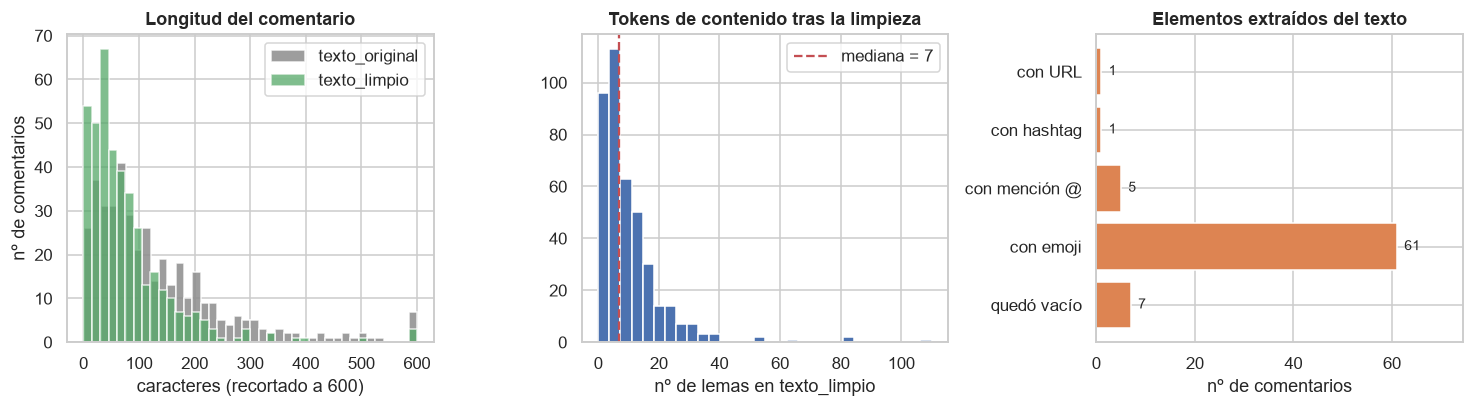

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

axes[0].hist(comments["len_original"].clip(upper=600), bins=40,
             color=COL["gris"], alpha=.85, label="texto_original")
axes[0].hist(comments["len_limpio"].clip(upper=600), bins=40,
             color=COL["acento"], alpha=.75, label="texto_limpio")
axes[0].set_title("Longitud del comentario")
axes[0].set_xlabel("caracteres (recortado a 600)")
axes[0].set_ylabel("nº de comentarios")
axes[0].legend()

axes[1].hist(comments["n_tokens"], bins=30, color=COL["autor"], edgecolor="white")
axes[1].axvline(comments["n_tokens"].median(), color=COL["alerta"], ls="--",
                label=f"mediana = {comments['n_tokens'].median():.0f}")
axes[1].set_title("Tokens de contenido tras la limpieza")
axes[1].set_xlabel("nº de lemas en texto_limpio")
axes[1].legend()

elem = pd.Series({
    "con URL": int((comments["n_urls"] > 0).sum()),
    "con hashtag": int((comments["n_hashtags"] > 0).sum()),
    "con mención @": int((comments["n_menciones"] > 0).sum()),
    "con emoji": int((comments["n_emojis"] > 0).sum()),
    "quedó vacío": len(vacios),
})
axes[2].barh(elem.index, elem.values, color=COL["video"])
axes[2].invert_yaxis()
axes[2].set_title("Elementos extraídos del texto")
axes[2].set_xlabel("nº de comentarios")
for y, v in enumerate(elem.values):
    axes[2].text(v + 1.5, y, str(v), va="center", fontsize=9)
axes[2].set_xlim(0, elem.max() * 1.22)

plt.tight_layout()
guardar_fig("f2_7_efecto_limpieza")
plt.show()

### Conclusiones del preprocesamiento

- **No se eliminó ningún registro.** La limpieza es aditiva (columnas nuevas), no destructiva.
- El texto se reduce un **43.9 %** (56 533 → 31 687 caracteres) y el vocabulario un **43.5 %**
  (3 171 → 1 793 términos): es el efecto buscado.
- **7 comentarios (1.7 %) quedan vacíos** tras la limpieza — sólo emojis, palabras vacías o textos
  muy cortos. **Se conservan**: siguen siendo participación válida y **siguen aportando aristas a la
  red**. Sólo se excluyen de los conteos de palabras.
- Los **duplicados de texto pasan de 2 a 13**: comentarios que sólo diferían en puntuación o tildes
  colapsan al mismo texto. **No motiva eliminación** (son `comment_id` distintos); de hecho es
  evidencia de que la normalización funciona.

In [36]:
# --- Persistencia de los conjuntos procesados --------------------------------
COLS_EXPORT_COM = [
    "comment_id", "video_id", "author_channel_id", "author_name", "author_handle_norm",
    "channel_id", "channel_name", "texto_original", "texto_norm", "texto_limpio",
    "n_tokens", "like_count", "reply_count", "n_urls", "n_hashtags", "n_menciones",
    "n_emojis", "source_group", "source_query", "published_text",
]
comments_proc = comments[COLS_EXPORT_COM].copy()
comments_proc.to_csv(DIR_PROC / "comentarios_limpios.csv", index=False, encoding="utf-8-sig")

COLS_EXPORT_VID = [
    "video_id", "title", "channel_id", "channel_name", "channel_handle_norm",
    "category", "view_count", "publish_date", "source_group", "source_query",
    "keywords", "description",
]
videos_proc = videos[COLS_EXPORT_VID].copy()
videos_proc.to_csv(DIR_PROC / "videos_limpios.csv", index=False, encoding="utf-8-sig")

print("Guardados en data/processed/:")
print(f"  comentarios_limpios.csv -> {comments_proc.shape[0]} filas x {comments_proc.shape[1]} columnas")
print(f"  videos_limpios.csv      -> {videos_proc.shape[0]} filas x {videos_proc.shape[1]} columnas")

Guardados en data/processed/:
  comentarios_limpios.csv -> 406 filas x 20 columnas
  videos_limpios.csv      -> 293 filas x 12 columnas


---
# 3. Análisis exploratorio

## Marco de lectura: dos universos distintos

| Universo | Tamaño | Para qué sirve |
|---|---|---|
| **A — Catálogo** | 293 videos, 97 canales | Categorías, visualizaciones, canales |
| **B — Con comentarios** | 19 videos, 8 canales, 406 comentarios, 332 autores | Participación, red y contenido |

> Las métricas de participación se calculan **sólo sobre el universo B**. Reportar "0 comentarios"
> para los 274 videos restantes confundiría *ausencia de datos* con *ausencia de participación*.

In [37]:
# Universo B: videos que efectivamente tienen comentarios recolectados
ids_con_com = set(comments["video_id"])
videos_b = videos[videos["video_id"].isin(ids_con_com)].copy()

# Tabla base para el análisis de participación (un registro por comentario, enriquecido)
part = comments.merge(
    videos[["video_id", "title", "channel_id", "channel_name", "channel_handle_norm",
            "category", "view_count", "publish_date", "source_group"]],
    on="video_id", how="left", suffixes=("", "_v"), validate="many_to_one")

print(f"UNIVERSO A — catálogo   : {videos['video_id'].nunique():>4} videos | "
      f"{videos['channel_id'].nunique():>3} canales")
print(f"UNIVERSO B — con comentarios: {videos_b['video_id'].nunique():>4} videos | "
      f"{videos_b['channel_id'].nunique():>3} canales | "
      f"{len(comments)} comentarios | {comments['author_channel_id'].nunique()} autores")

UNIVERSO A — catálogo   :  293 videos |  97 canales
UNIVERSO B — con comentarios:   19 videos |   8 canales | 406 comentarios | 332 autores


## 3.1. Descriptivos mínimos

### 3.1.a Conteos generales

In [38]:
resumen_general = pd.DataFrame([
    ["Videos en el catálogo (universo A)", videos["video_id"].nunique()],
    ["Canales en el catálogo (universo A)", videos["channel_id"].nunique()],
    ["Categorías de YouTube distintas", videos["category"].nunique()],
    ["Consultas de búsqueda distintas (videos)", videos["source_query"].nunique()],
    ["Videos con comentarios recolectados (universo B)", videos_b["video_id"].nunique()],
    ["Canales con comentarios recolectados (universo B)", videos_b["channel_id"].nunique()],
    ["Comentarios totales", len(comments)],
    ["Autores únicos de comentarios", comments["author_channel_id"].nunique()],
    ["Pares únicos autor–video (futuras aristas)",
     comments.groupby(["author_channel_id", "video_id"]).ngroups],
    ["Comentarios por autor (media)", round(len(comments) / comments["author_channel_id"].nunique(), 2)],
    ["Comentarios por video con comentarios (media)",
     round(len(comments) / videos_b["video_id"].nunique(), 1)],
    ["Total de 'me gusta' en comentarios", int(comments["like_count"].sum())],
    ["Total de respuestas declaradas (reply_count)", int(comments["reply_count"].sum())],
], columns=["indicador", "valor"])

guardar_tabla(resumen_general, "t3_1_resumen_general")
resumen_general

,indicador,valor
0,Videos en el catálogo (universo A),293.00
1,Canales en el catálogo (universo A),97.00
2,Categorías de YouTube distintas,11.00
3,Consultas de búsqueda distintas (videos),21.00
4,Videos con comentarios recolectados (universo B),19.00
5,Canales con comentarios recolectados (universo B),8.00
6,Comentarios totales,406.00
7,Autores únicos de comentarios,332.00
8,Pares únicos autor–video (futuras aristas),343.00
9,Comentarios por autor (media),1.22


### 3.1.b Videos por canal

In [39]:
videos_por_canal = (videos.groupby(["channel_id", "channel_name"])
                    .agg(n_videos=("video_id", "count"),
                         vistas_totales=("view_count", "sum"),
                         vistas_medianas=("view_count", "median"))
                    .reset_index().sort_values("n_videos", ascending=False))
guardar_tabla(videos_por_canal, "t3_1_videos_por_canal")

print("Distribución de videos por canal (universo A):")
print(videos_por_canal["n_videos"].describe().round(2).to_string())
print(f"\nCanales con un solo video: {(videos_por_canal['n_videos'] == 1).sum()} "
      f"de {len(videos_por_canal)} "
      f"({(videos_por_canal['n_videos'] == 1).mean():.1%})")
display(videos_por_canal.head(12))

Distribución de videos por canal (universo A):
count    97.00
mean      3.02
std       5.14
min       1.00
25%       1.00
50%       1.00
75%       2.00
max      32.00

Canales con un solo video: 65 de 97 (67.0%)


,channel_id,channel_name,n_videos,vistas_totales,vistas_medianas
3,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,32,56052,1230.5
54,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,27,452548,1562.0
26,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,18,31267,440.5
28,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,17,424888,5469.0
15,UC8u2nvyHewt-mjdWSj0HJmQ,Ministerio de Gobernación,14,141661,32.0
63,UCaivrAhro2BpsJdrPe-IyRg,Diario de Centro América,11,4769,265.0
17,UCAutgrPkiLhZxTB-Ujje1fw,CIV -Ministerio de Comunicaciones,11,5881,26.0
52,UCW_PHqwqCCalvQGOEsVU0jw,Concejales de Oposición - Muni Guate,10,2106,139.0
34,UCHsYnV67K3J0yJ4QeciVCww,PNCdeGuatemala,10,329798,18494.5
7,UC6SA1dVHvAkc6yNS_t5cbGw,Conred,8,1693,154.5


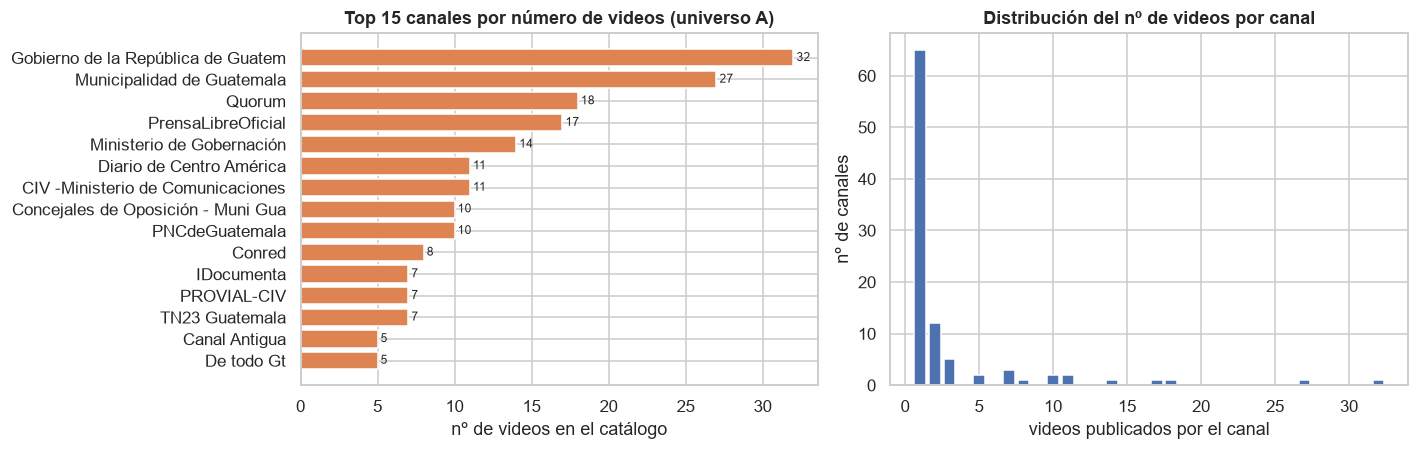

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

top_canales = videos_por_canal.head(15).iloc[::-1]
axes[0].barh(top_canales["channel_name"].str.slice(0, 34), top_canales["n_videos"],
             color=COL["video"])
axes[0].set_title("Top 15 canales por número de videos (universo A)")
axes[0].set_xlabel("nº de videos en el catálogo")
for y, v in enumerate(top_canales["n_videos"]):
    axes[0].text(v + .2, y, str(v), va="center", fontsize=8)

conteo = videos_por_canal["n_videos"].value_counts().sort_index()
axes[1].bar(conteo.index, conteo.values, color=COL["autor"])
axes[1].set_title("Distribución del nº de videos por canal")
axes[1].set_xlabel("videos publicados por el canal")
axes[1].set_ylabel("nº de canales")

plt.tight_layout()
guardar_fig("f3_1_videos_por_canal")
plt.show()

### 3.1.c Comentarios y autores únicos por video

In [41]:
por_video = (part.groupby("video_id")
             .agg(n_comentarios=("comment_id", "count"),
                  n_autores=("author_channel_id", "nunique"),
                  me_gusta=("like_count", "sum"),
                  respuestas=("reply_count", "sum"),
                  titulo=("title", "first"),
                  canal=("channel_name_v", "first"),
                  categoria=("category", "first"),
                  vistas=("view_count", "first"))
             .reset_index().sort_values("n_comentarios", ascending=False))
por_video["comentarios_por_autor"] = (por_video["n_comentarios"] / por_video["n_autores"]).round(2)
por_video["pct_del_total"] = (por_video["n_comentarios"] / len(comments) * 100).round(1)

guardar_tabla(por_video, "t3_1_por_video")
por_video[["titulo", "canal", "n_comentarios", "n_autores", "comentarios_por_autor",
           "me_gusta", "respuestas", "vistas", "pct_del_total"]]

,titulo,canal,n_comentarios,n_autores,comentarios_por_autor,me_gusta,respuestas,vistas,pct_del_total
14,Qué rico come tu diputado,Quorum,161,128,1.26,358,3,11775,39.7
12,La cooptación de Walter Mazariegos en la USAC,Quorum,50,49,1.02,91,0,10156,12.3
2,Inician los trabajos de recuperación del Puente Belice II.,Gobierno de la República de Guatemala,45,32,1.41,90,11,11670,11.1
13,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,25,25,1.00,1697,16,304089,6.2
5,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Gobierno de la República de Guatemala,25,19,1.32,20,4,3628,6.2
4,EE.UU. envía a mexicanos deportados a Guatemala antes de su regres...,Noticias Telemundo,25,18,1.39,25,13,14200,6.2
17,Arroz con pollo a la MONOPOLIO,Quorum,16,16,1.00,13,0,1954,3.9
0,Capturan a presuntos delincuentes disfrazados de mujer señalados d...,Noti7,14,13,1.08,12,1,6692,3.4
15,Internet: escoger el menos malo,Quorum,12,10,1.20,3,1,717,3.0
11,Capturan a ladrón que había quedado grabado mientras robaba en una...,TN23 Guatemala,7,7,1.00,0,1,4616,1.7


In [42]:
por_autor = (comments.groupby(["author_channel_id"])
             .agg(n_comentarios=("comment_id", "count"),
                  n_videos=("video_id", "nunique"),
                  me_gusta=("like_count", "sum"),
                  respuestas=("reply_count", "sum"),
                  autor=("author_name", "first"),
                  tokens=("n_tokens", "sum"))
             .reset_index().sort_values(["n_videos", "n_comentarios"], ascending=False))
guardar_tabla(por_autor, "t3_1_por_autor")

print("Distribución de comentarios por autor:")
print(por_autor["n_comentarios"].describe().round(2).to_string())
print(f"\nAutores con un solo comentario : {(por_autor['n_comentarios'] == 1).sum()} "
      f"({(por_autor['n_comentarios'] == 1).mean():.1%})")
print(f"Autores en un solo video       : {(por_autor['n_videos'] == 1).sum()} "
      f"({(por_autor['n_videos'] == 1).mean():.1%})")
print(f"Autores en más de un video     : {(por_autor['n_videos'] > 1).sum()} "
      f"({(por_autor['n_videos'] > 1).mean():.1%})  <-- son los únicos que conectan videos")
display(por_autor.head(12))

Distribución de comentarios por autor:
count    332.00
mean       1.22
std        0.68
min        1.00
25%        1.00
50%        1.00
75%        1.00
max        6.00

Autores con un solo comentario : 286 (86.1%)
Autores en un solo video       : 323 (97.3%)
Autores en más de un video     : 9 (2.7%)  <-- son los únicos que conectan videos


,author_channel_id,n_comentarios,n_videos,me_gusta,respuestas,autor,tokens
307,UCvcu1kR8xMYy_I1Ty-2mV2Q,4,3,0,0,@hashojea7348,12
276,UCpsKOkt5iWTbenzeuq7dsmQ,3,3,4,0,@inge_vergueta,16
98,UCHTGCgY2l-DQJIvlA_cpa_Q,3,2,14,0,@virgiliogarcia3039,47
325,UCylqlpsh8ENNM1LqgQ1KbxA,3,2,1,0,@Jel.Awesh.M,11
207,UCbrtvygfRT6QXqWDNrOf-cA,2,2,0,0,@Alejandro00710,16
211,UCdFlugHJJa4l3YqWuNRmvXw,2,2,0,1,@MarcosCarillo-b1r,11
250,UCjZgFEowMBrsjodqfovzdKw,2,2,0,0,@franciscoflores3120,5
287,UCsUCN0Yq_UyTvKjOJLmNrnQ,2,2,0,0,@moisesvaldez4043,11
330,UCzZ6dDCEsLMXbc5pCFXIprw,2,2,0,0,@josegil3813,17
241,UCi2KiZq63sRq8Mfbcp-MelQ,6,1,1,0,@eugeneramirez4405,50


> **Hallazgo decisivo para la red:** sólo **9 de 332 autores (2.7 %)** comentaron en más de un
> video. Son, literalmente, **los únicos puentes posibles**: la estructura de la sección 4 depende
> por completo de ellos.

### 3.1.d Visualizaciones, respuestas y 'me gusta'

In [43]:
def describir(serie, nombre, universo):
    s = pd.to_numeric(serie, errors="coerce").dropna()
    return {"variable": nombre, "universo": universo, "n": len(s),
            "media": round(s.mean(), 2), "mediana": s.median(),
            "desv_est": round(s.std(), 2), "min": s.min(),
            "p25": s.quantile(.25), "p75": s.quantile(.75),
            "p95": s.quantile(.95), "max": s.max(), "suma": int(s.sum())}


metricas = pd.DataFrame([
    describir(videos["view_count"], "view_count", "A · 293 videos"),
    describir(videos_b["view_count"], "view_count", "B · 19 videos con comentarios"),
    describir(comments["like_count"], "me gusta por comentario", "B · 406 comentarios"),
    describir(comments["reply_count"], "reply_count", "B · 406 comentarios"),
    describir(comments["n_tokens"], "tokens de contenido", "B · 406 comentarios"),
    describir(por_video["n_comentarios"], "comentarios por video", "B · 19 videos"),
    describir(por_video["n_autores"], "autores únicos por video", "B · 19 videos"),
    describir(por_autor["n_comentarios"], "comentarios por autor", "B · 332 autores"),
])
guardar_tabla(metricas, "t3_1_metricas")
metricas

,variable,universo,n,media,mediana,desv_est,min,p25,p75,p95,max,suma
0,view_count,A · 293 videos,293,60430.09,1175.0,515798.31,2,215.0,7465.0,130467.00,8190449,17706015
1,view_count,B · 19 videos con comentarios,19,20046.11,1954.0,68934.23,52,695.0,8424.0,43188.90,304089,380876
2,me gusta por comentario,B · 406 comentarios,406,5.73,1.0,30.66,0,0.0,2.0,14.00,405,2325
3,reply_count,B · 406 comentarios,406,0.13,0.0,0.58,0,0.0,0.0,1.00,7,51
4,tokens de contenido,B · 406 comentarios,406,10.22,7.0,11.23,0,4.0,13.0,27.75,110,4150
5,comentarios por video,B · 19 videos,19,21.37,7.0,36.82,1,2.5,25.0,61.10,161,406
6,autores únicos por video,B · 19 videos,19,18.05,7.0,29.46,1,2.5,18.5,56.90,128,343
7,comentarios por autor,B · 332 autores,332,1.22,1.0,0.68,1,1.0,1.0,2.00,6,406


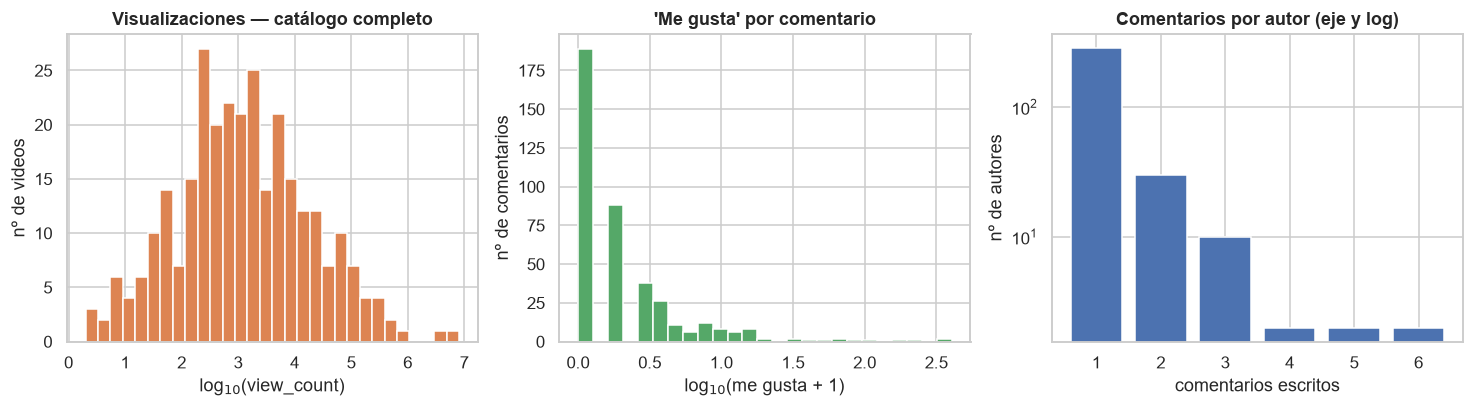

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))

axes[0].hist(np.log10(videos["view_count"].clip(lower=1).astype(float)), bins=30,
             color=COL["video"], edgecolor="white")
axes[0].set_title("Visualizaciones — catálogo completo")
axes[0].set_xlabel("log$_{10}$(view_count)")
axes[0].set_ylabel("nº de videos")

lk = comments["like_count"]
axes[1].hist(np.log10(lk + 1), bins=25, color=COL["acento"], edgecolor="white")
axes[1].set_title("'Me gusta' por comentario")
axes[1].set_xlabel("log$_{10}$(me gusta + 1)")
axes[1].set_ylabel("nº de comentarios")

vc = por_autor["n_comentarios"].value_counts().sort_index()
axes[2].bar(vc.index, vc.values, color=COL["autor"])
axes[2].set_yscale("log")
axes[2].set_title("Comentarios por autor (eje y log)")
axes[2].set_xlabel("comentarios escritos")
axes[2].set_ylabel("nº de autores")

plt.tight_layout()
guardar_fig("f3_1_distribuciones")
plt.show()

### 3.1.e Categorías y consultas de búsqueda

In [45]:
cat_a = (videos.groupby("category")
         .agg(n_videos=("video_id", "count"), vistas_medianas=("view_count", "median"),
              vistas_totales=("view_count", "sum")).reset_index())
cat_b = (part.groupby("category").agg(n_comentarios=("comment_id", "count"),
                                      n_videos_comentados=("video_id", "nunique")).reset_index())
categorias = cat_a.merge(cat_b, on="category", how="left").fillna(0)
categorias[["n_comentarios", "n_videos_comentados"]] = \
    categorias[["n_comentarios", "n_videos_comentados"]].astype(int)
categorias = categorias.sort_values("n_videos", ascending=False)
guardar_tabla(categorias, "t3_1_categorias")
categorias

,category,n_videos,vistas_medianas,vistas_totales,n_comentarios,n_videos_comentados
5,News & Politics,138,1068.0,2165695,335,16
7,People & Blogs,66,488.5,5116257,0,0
2,Entertainment,48,1378.0,558349,70,2
1,Education,19,521.0,873680,0,0
10,Travel & Events,8,9579.5,660990,0,0
8,Science & Technology,6,13251.5,128772,0,0
6,Nonprofits & Activism,3,167.0,602,1,1
3,Film & Animation,2,1424.5,2849,0,0
0,Comedy,1,8190449.0,8190449,0,0
4,Music,1,5262.0,5262,0,0


In [46]:
consultas = (videos.groupby(["source_group", "source_query"])
             .agg(n_videos=("video_id", "count"), vistas_medianas=("view_count", "median"))
             .reset_index().sort_values("n_videos", ascending=False))
guardar_tabla(consultas, "t3_1_consultas")

grupos = (videos.groupby("source_group")
          .agg(n_videos=("video_id", "count"), n_canales=("channel_id", "nunique"),
               vistas_medianas=("view_count", "median")).reset_index())

# Los comentarios se atribuyen al source_group DEL VIDEO en el que fueron publicados
# (columna source_group_v), que es la comparación con sentido frente al catálogo.
grupos_com = (part.groupby("source_group_v")
              .agg(n_comentarios=("comment_id", "count"),
                   n_videos_comentados=("video_id", "nunique"))
              .reset_index().rename(columns={"source_group_v": "source_group"}))
grupos = grupos.merge(grupos_com, on="source_group", how="left").fillna(0)
grupos[["n_comentarios", "n_videos_comentados"]] = \
    grupos[["n_comentarios", "n_videos_comentados"]].astype(int)
guardar_tabla(grupos, "t3_1_source_group")

print("Estrategias de recolección (source_group del VIDEO):")
display(grupos)

# Inconsistencia de etiquetado entre los dos archivos
print("\nEtiqueta source_group registrada en el ARCHIVO DE COMENTARIOS:")
print(comments["source_group"].value_counts().to_string())
print("\nEtiqueta source_group del VIDEO correspondiente:")
print(part["source_group_v"].value_counts().to_string())
cruce_sg = pd.crosstab(part["source_group_v"], part["source_group"])
guardar_tabla(cruce_sg.reset_index(), "t3_1_cruce_source_group")
print("\nCruce (filas = grupo del video, columnas = grupo anotado en el comentario):")
display(cruce_sg)

print("\nTop 12 consultas por número de videos recuperados:")
display(consultas.head(12))

Estrategias de recolección (source_group del VIDEO):


,source_group,n_videos,n_canales,vistas_medianas,n_comentarios,n_videos_comentados
0,channel,11,1,673.0,43,7
1,official_gov,105,31,521.0,0,0
2,topic,177,77,2214.0,363,12



Etiqueta source_group registrada en el ARCHIVO DE COMENTARIOS:
source_group
channel    231
topic      175

Etiqueta source_group del VIDEO correspondiente:
source_group_v
topic      363
channel     43

Cruce (filas = grupo del video, columnas = grupo anotado en el comentario):


source_group,channel,topic
source_group_v,,
channel,43,0
topic,188,175



Top 12 consultas por número de videos recuperados:


,source_group,source_query,n_videos,vistas_medianas
10,topic,@GobiernodelaRepublicadeGuatema,18,57.0
9,topic,@GobiernodeGuatemala,17,959.0
3,official_gov,Ministerio de Comunicaciones Guatemala,16,121.5
18,topic,guatemala noticias,16,17967.0
11,topic,@MunicipalidaddeGuatemala-1551,16,191.0
6,official_gov,PMT Guatemala,15,2383.0
1,official_gov,Conred Guatemala,15,200.0
14,topic,Gobierno de la República de Guatemala,15,1383.0
7,official_gov,Policia Nacional Civil Guatemala,13,15455.0
22,topic,guatemala transporte,13,134775.0


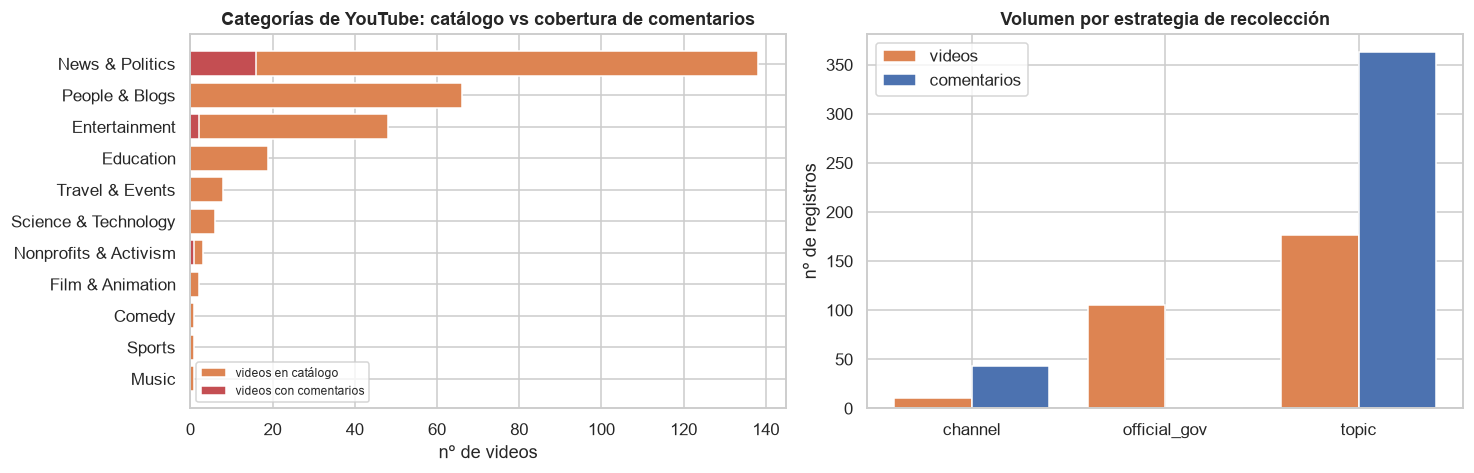

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))

c = categorias.sort_values("n_videos").tail(11)
y = np.arange(len(c))
axes[0].barh(y, c["n_videos"], color=COL["video"], label="videos en catálogo")
axes[0].barh(y, c["n_videos_comentados"], color=COL["alerta"], label="videos con comentarios")
axes[0].set_yticks(y)
axes[0].set_yticklabels(c["category"])
axes[0].set_title("Categorías de YouTube: catálogo vs cobertura de comentarios")
axes[0].set_xlabel("nº de videos")
axes[0].legend(fontsize=8)

g = grupos.set_index("source_group")
x = np.arange(len(g))
axes[1].bar(x - .2, g["n_videos"], .4, color=COL["video"], label="videos")
axes[1].bar(x + .2, g["n_comentarios"], .4, color=COL["autor"], label="comentarios")
axes[1].set_xticks(x)
axes[1].set_xticklabels(g.index)
axes[1].set_title("Volumen por estrategia de recolección")
axes[1].set_ylabel("nº de registros")
axes[1].legend()

plt.tight_layout()
guardar_fig("f3_1_categorias_consultas")
plt.show()

**Lectura.** `News & Politics` domina el catálogo (138 de 293) y concentra casi todos los videos
comentados. `Entertainment` incluye dos videos muy comentados que son contenido institucional del
Gobierno: **la etiqueta de YouTube no es una clasificación temática fiable** (§2.2).

El desbalance entre estrategias de recolección es **extremo**:

| `source_group` del video | En catálogo | Comentados | Comentarios |
|---|---:|---:|---:|
| `topic` | 177 (60 %) | 12 | **363** (89 %) |
| `channel` | 11 (4 %) | 7 | 43 (11 %) |
| `official_gov` | **105 (36 %)** | **0** | **0** |

**Los 105 videos de cuentas oficiales de gobierno —un tercio del catálogo, en 31 canales— no
aportaron ni un comentario.** Es el sesgo de cobertura más importante del conjunto.

Ojo: `source_group` describe **cómo se encontró** el video, no quién lo publicó. Los videos del
Gobierno y la Municipalidad que sí tienen comentarios están clasificados como `topic`; los 11 de
Quorum se reparten entre `channel` (7) y `topic` (4).

> **Inconsistencia de etiquetado.** `official_gov` existe en el archivo de videos pero **nunca
> aparece en el de comentarios**, que sólo usa `topic` y `channel`. Por eso los comentarios se
> atribuyen al `source_group` **del video** (`source_group_v`), que es la comparación con sentido.
> Confundir ambas columnas daría un recuento erróneo por estrategia.

### 3.1.f Hashtags

In [48]:
# Hashtags en COMENTARIOS
hash_com = Counter(h for lst in comments["hashtags"] for h in lst)
print(f"Comentarios con al menos un hashtag : {(comments['n_hashtags'] > 0).sum()} de {len(comments)}")
print(f"Hashtags distintos en comentarios   : {len(hash_com)}")
print("  ", dict(hash_com.most_common(10)) if hash_com else "—")

# Hashtags en DESCRIPCIONES DE VIDEO (mucho más ricas)
desc = videos["description"].fillna("")
hash_vid_series = desc.map(lambda t: [h.lower() for h in RE_HASHTAG.findall(t)])
hash_vid = Counter(h for lst in hash_vid_series for h in lst)
print(f"\nVideos con al menos un hashtag en la descripción: {(hash_vid_series.map(len) > 0).sum()} "
      f"de {len(videos)}")
print(f"Hashtags distintos en descripciones             : {len(hash_vid)}")

top_hash = pd.DataFrame(hash_vid.most_common(25), columns=["hashtag", "frecuencia"])
guardar_tabla(top_hash, "t3_1_hashtags_videos")
display(top_hash.head(20))

Comentarios con al menos un hashtag : 1 de 406
Hashtags distintos en comentarios   : 1
   {'ineptobran': 1}

Videos con al menos un hashtag en la descripción: 103 de 293
Hashtags distintos en descripciones             : 328


,hashtag,frecuencia
0,guatemala,48
1,larondagt,15
2,noticias,14
3,nacionales,7
4,like,7
5,comenta,7
6,comparte,7
7,siguenos,7
8,noticiasguatemala,6
9,pnc,5


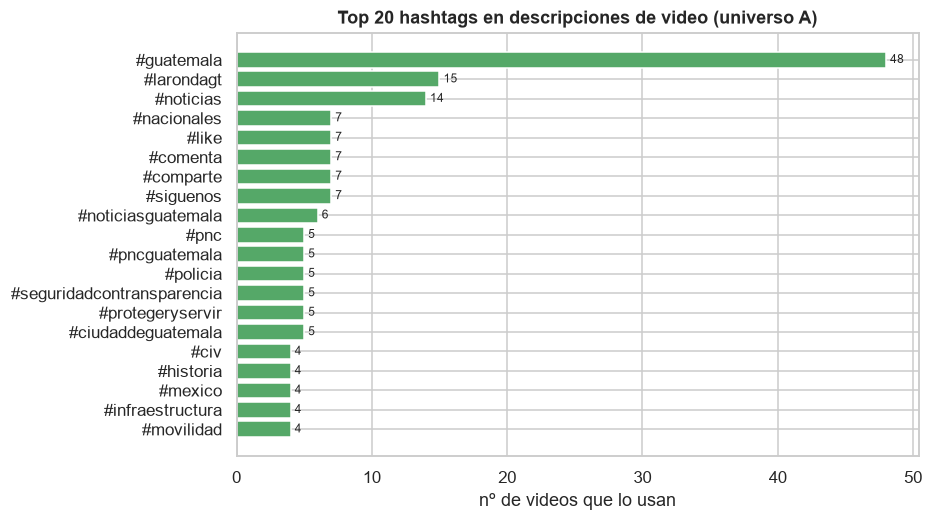

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))
th = top_hash.head(20).iloc[::-1]
ax.barh("#" + th["hashtag"], th["frecuencia"], color=COL["acento"])
ax.set_title("Top 20 hashtags en descripciones de video (universo A)")
ax.set_xlabel("nº de videos que lo usan")
for y, v in enumerate(th["frecuencia"]):
    ax.text(v + .3, y, str(v), va="center", fontsize=8)
guardar_fig("f3_1_hashtags")
plt.show()

Los hashtags son **casi inexistentes en los comentarios** (1 de 406) pero abundantes en las
descripciones de video (103 de 293): el hashtag es herramienta de **difusión del emisor**, no del
público que comenta.

### 3.1.g Palabras y bigramas frecuentes

In [50]:
tokens_todos = [t for lst in comments["tokens_limpios"] for t in lst]
frec_pal = Counter(tokens_todos)

bigramas = []
for lst in comments["tokens_limpios"]:
    bigramas += [f"{a} {b}" for a, b in zip(lst, lst[1:])]
frec_big = Counter(bigramas)

print(f"Tokens totales      : {len(tokens_todos):,}")
print(f"Vocabulario distinto: {len(frec_pal):,}")
print(f"Bigramas totales    : {len(bigramas):,}  |  distintos: {len(frec_big):,}")
print(f"Riqueza léxica (tipos/tokens): {len(frec_pal)/max(len(tokens_todos),1):.3f}")

top_palabras = pd.DataFrame(frec_pal.most_common(30), columns=["palabra", "frecuencia"])
top_bigramas = pd.DataFrame(frec_big.most_common(25), columns=["bigrama", "frecuencia"])
guardar_tabla(top_palabras, "t3_1_top_palabras")
guardar_tabla(top_bigramas, "t3_1_top_bigramas")

display(pd.concat([top_palabras.head(20).reset_index(drop=True),
                   top_bigramas.head(20).reset_index(drop=True)], axis=1))

Tokens totales      : 4,150
Vocabulario distinto: 1,793
Bigramas totales    : 3,751  |  distintos: 3,527
Riqueza léxica (tipos/tokens): 0.432


,palabra,frecuencia,bigrama,frecuencia
0,pueblo,56,bernardo arevalo,10
1,pais,56,presidente bernardo,9
2,guatemala,52,morir hambre,7
3,diputado,51,pagar sueldo,6
4,pagar,38,ciudad guatemala,6
5,presidente,35,buscar trabajo,5
6,dinero,34,nery roda,5
7,trabajo,31,bla bla,5
8,corrupto,30,pacto corrupto,5
9,seguir,24,vivar guatemala,4


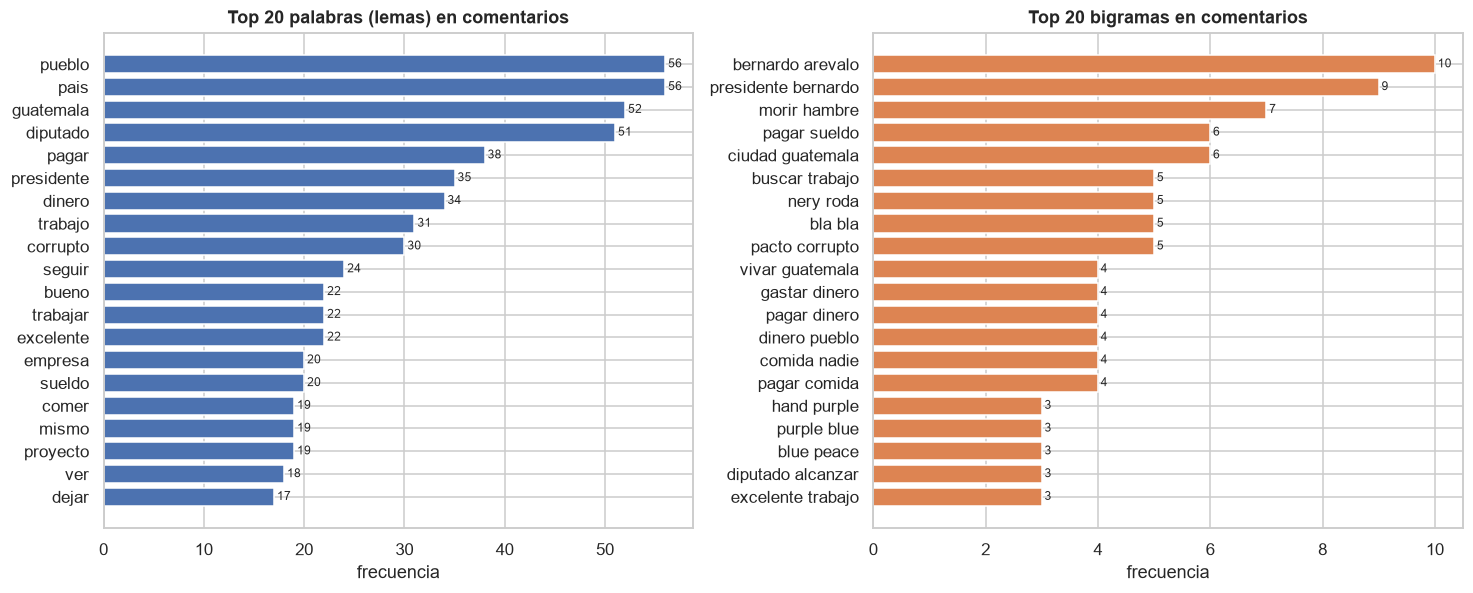

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5))

tp = top_palabras.head(20).iloc[::-1]
axes[0].barh(tp["palabra"], tp["frecuencia"], color=COL["autor"])
axes[0].set_title("Top 20 palabras (lemas) en comentarios")
axes[0].set_xlabel("frecuencia")
for y, v in enumerate(tp["frecuencia"]):
    axes[0].text(v + .3, y, str(v), va="center", fontsize=8)

tb = top_bigramas.head(20).iloc[::-1]
axes[1].barh(tb["bigrama"], tb["frecuencia"], color=COL["video"])
axes[1].set_title("Top 20 bigramas en comentarios")
axes[1].set_xlabel("frecuencia")
for y, v in enumerate(tb["frecuencia"]):
    axes[1].text(v + .05, y, str(v), va="center", fontsize=8)

plt.tight_layout()
guardar_fig("f3_1_palabras_bigramas")
plt.show()

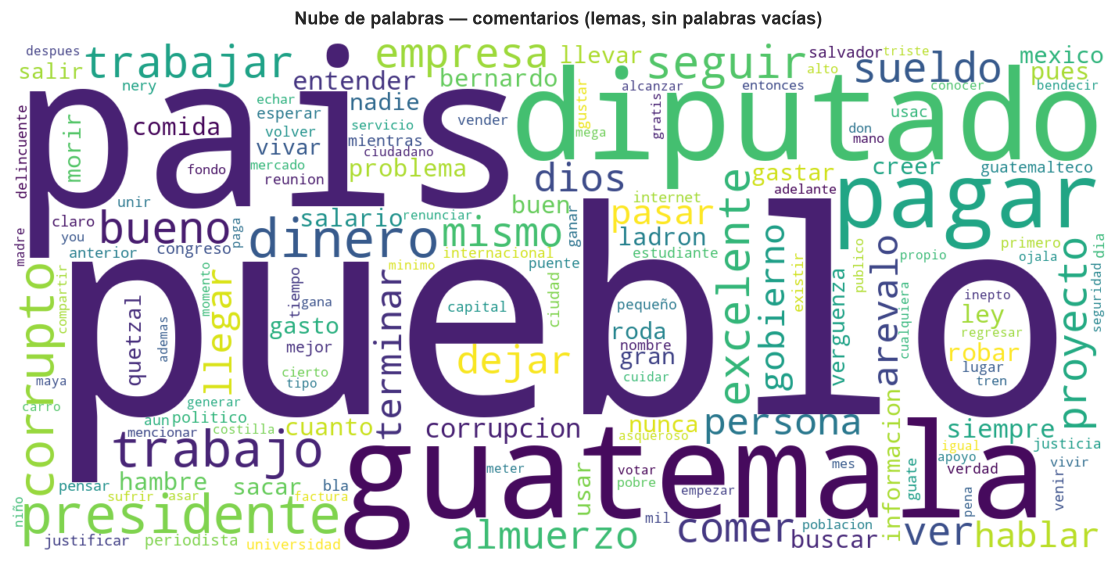

In [52]:
from wordcloud import WordCloud

nube = WordCloud(width=1400, height=650, background_color="white",
                 colormap="viridis", random_state=SEED,
                 max_words=160, collocations=False).generate_from_frequencies(frec_pal)

fig, ax = plt.subplots(figsize=(13, 6))
ax.imshow(nube, interpolation="bilinear")
ax.axis("off")
ax.set_title("Nube de palabras — comentarios (lemas, sin palabras vacías)", pad=12)
guardar_fig("f3_1_nube_palabras")
plt.show()

> La nube se incluye como apoyo visual, **no** como sustituto de los gráficos de frecuencia: no
> permite leer valores ni comparar magnitudes. Las conclusiones se sostienen en las tablas y
> barras anteriores.

## 3.2. Concentración de la participación

Tres instrumentos complementarios: **cuota de los k más activos**, **Gini** y **curva de Lorenz**.
El Gini vale 0 con reparto igualitario y tiende a 1 cuando todo se concentra en una unidad.

In [53]:
def gini(x):
    """Coeficiente de Gini sobre valores no negativos."""
    x = np.sort(np.asarray(x, dtype=float))
    if x.sum() == 0:
        return 0.0
    n = len(x)
    idx = np.arange(1, n + 1)
    return float((2 * (idx * x).sum()) / (n * x.sum()) - (n + 1) / n)


def cuota_top(serie, k):
    s = np.sort(np.asarray(serie, dtype=float))[::-1]
    return float(s[:k].sum() / s.sum())


por_canal_com = (part.groupby(["channel_id", "channel_name_v"])
                 .agg(n_comentarios=("comment_id", "count"),
                      n_videos=("video_id", "nunique"),
                      n_autores=("author_channel_id", "nunique"))
                 .reset_index().sort_values("n_comentarios", ascending=False))
guardar_tabla(por_canal_com, "t3_2_por_canal_comentarios")

concentracion = pd.DataFrame([
    {"unidad": "Videos (19 con comentarios)", "n_unidades": len(por_video),
     "gini": round(gini(por_video["n_comentarios"]), 3),
     "cuota_top1": cuota_top(por_video["n_comentarios"], 1),
     "cuota_top3": cuota_top(por_video["n_comentarios"], 3),
     "cuota_top5": cuota_top(por_video["n_comentarios"], 5)},
    {"unidad": "Canales (8 con comentarios)", "n_unidades": len(por_canal_com),
     "gini": round(gini(por_canal_com["n_comentarios"]), 3),
     "cuota_top1": cuota_top(por_canal_com["n_comentarios"], 1),
     "cuota_top3": cuota_top(por_canal_com["n_comentarios"], 3),
     "cuota_top5": cuota_top(por_canal_com["n_comentarios"], 5)},
    {"unidad": "Autores (332)", "n_unidades": len(por_autor),
     "gini": round(gini(por_autor["n_comentarios"]), 3),
     "cuota_top1": cuota_top(por_autor["n_comentarios"], 1),
     "cuota_top3": cuota_top(por_autor["n_comentarios"], 3),
     "cuota_top5": cuota_top(por_autor["n_comentarios"], 5)},
    {"unidad": "Visualizaciones (293 videos)", "n_unidades": len(videos),
     "gini": round(gini(videos["view_count"].astype(float)), 3),
     "cuota_top1": cuota_top(videos["view_count"].astype(float), 1),
     "cuota_top3": cuota_top(videos["view_count"].astype(float), 3),
     "cuota_top5": cuota_top(videos["view_count"].astype(float), 5)},
])
for c in ["cuota_top1", "cuota_top3", "cuota_top5"]:
    concentracion[c] = concentracion[c].map(lambda x: f"{x:.1%}")

guardar_tabla(concentracion, "t3_2_concentracion")
concentracion

,unidad,n_unidades,gini,cuota_top1,cuota_top3,cuota_top5
0,Videos (19 con comentarios),19,0.660,39.7%,63.1%,75.4%
1,Canales (8 con comentarios),8,0.664,63.1%,86.5%,96.1%
2,Autores (332),332,0.164,1.5%,4.2%,6.4%
3,Visualizaciones (293 videos),293,0.949,46.3%,68.3%,73.5%


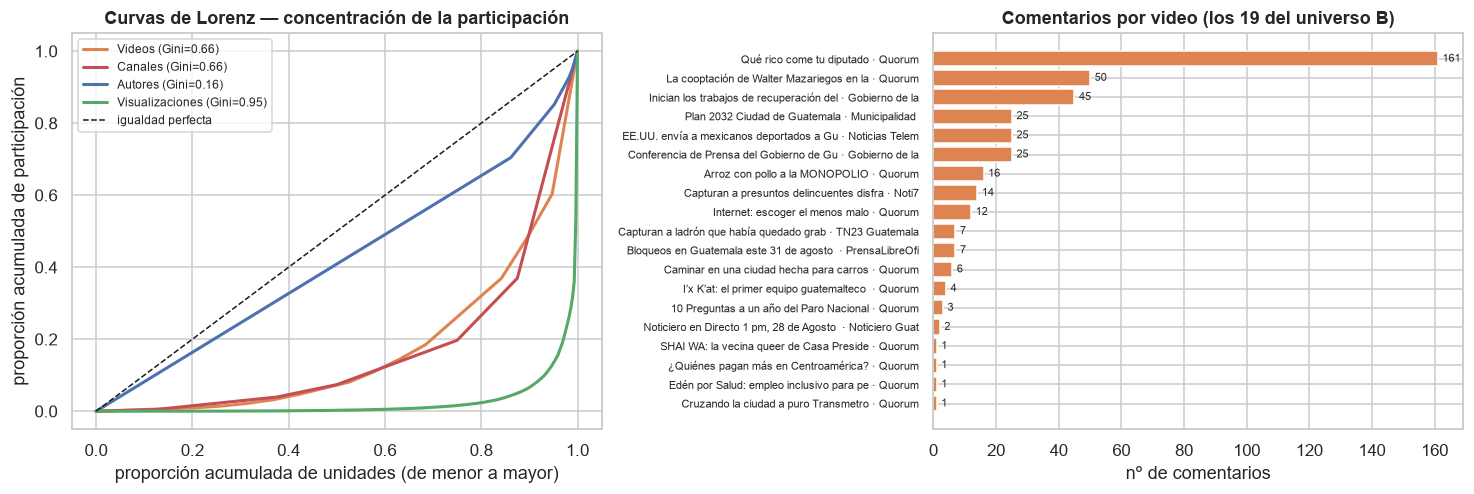

In [54]:
def lorenz(x):
    x = np.sort(np.asarray(x, dtype=float))
    acum = np.cumsum(x) / x.sum()
    return np.insert(np.arange(1, len(x) + 1) / len(x), 0, 0), np.insert(acum, 0, 0)


fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

series = [("Videos", por_video["n_comentarios"], COL["video"]),
          ("Canales", por_canal_com["n_comentarios"], COL["alerta"]),
          ("Autores", por_autor["n_comentarios"], COL["autor"]),
          ("Visualizaciones", videos["view_count"].astype(float), COL["acento"])]
for nombre, s, c in series:
    px, py = lorenz(s)
    axes[0].plot(px, py, lw=2, color=c, label=f"{nombre} (Gini={gini(s):.2f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="igualdad perfecta")
axes[0].set_title("Curvas de Lorenz — concentración de la participación")
axes[0].set_xlabel("proporción acumulada de unidades (de menor a mayor)")
axes[0].set_ylabel("proporción acumulada de participación")
axes[0].legend(fontsize=8, loc="upper left")

pv = por_video.sort_values("n_comentarios", ascending=True).tail(19)
etiquetas = pv["titulo"].str.slice(0, 40) + " · " + pv["canal"].str.slice(0, 14)
axes[1].barh(etiquetas, pv["n_comentarios"], color=COL["video"])
axes[1].set_title("Comentarios por video (los 19 del universo B)")
axes[1].set_xlabel("nº de comentarios")
axes[1].tick_params(axis="y", labelsize=7)
for y, v in enumerate(pv["n_comentarios"]):
    axes[1].text(v + 1.5, y, str(v), va="center", fontsize=7)

plt.tight_layout()
guardar_fig("f3_2_concentracion")
plt.show()

In [55]:
top3_v = por_video.head(3)
top1_c = por_canal_com.head(1)
print("CONCENTRACIÓN — cifras clave\n" + "-" * 62)
print(f"El video más comentado ('{top3_v.iloc[0]['titulo'][:45]}...')")
print(f"  concentra {top3_v.iloc[0]['n_comentarios']} de {len(comments)} comentarios "
      f"({top3_v.iloc[0]['n_comentarios']/len(comments):.1%})")
print(f"Los 3 videos más comentados concentran {top3_v['n_comentarios'].sum()} "
      f"({top3_v['n_comentarios'].sum()/len(comments):.1%})")
print(f"El canal más comentado ('{top1_c.iloc[0]['channel_name_v']}') concentra "
      f"{top1_c.iloc[0]['n_comentarios']} ({top1_c.iloc[0]['n_comentarios']/len(comments):.1%})")
print(f"El 10% de autores más activos concentra "
      f"{cuota_top(por_autor['n_comentarios'], max(1, int(.10*len(por_autor)))):.1%} de los comentarios")
display(por_canal_com)

CONCENTRACIÓN — cifras clave
--------------------------------------------------------------
El video más comentado ('Qué rico come tu diputado...')
  concentra 161 de 406 comentarios (39.7%)
Los 3 videos más comentados concentran 256 (63.1%)
El canal más comentado ('Quorum') concentra 256 (63.1%)
El 10% de autores más activos concentra 23.2% de los comentarios


,channel_id,channel_name_v,n_comentarios,n_videos,n_autores
1,UCE4rsXcgDb6e1-a9iTbWzfg,Quorum,256,11,214
0,UC-ZtFBHzgkYFh7whZkuR_Ag,Gobierno de la República de Guatemala,70,2,50
3,UCRwA1NUcUnwsly35ikGhp0A,Noticias Telemundo,25,1,18
5,UCXa6LVjBzUtmcM3cwbd9e2w,Municipalidad de Guatemala,25,1,25
4,UCVpSRoZgngfSL03Nlbjtq9A,Noti7,14,1,13
2,UCEepOY2svuxbsJ-zsAPT9Fg,PrensaLibreOficial,7,1,7
7,UCt5Dw7ePnn0AqPqRF8Xpjkw,TN23 Guatemala,7,1,7
6,UCdSVqHGHzyMTXSafUHY-e-w,Noticiero Guatevisión 13 Hrs.,2,1,2


### Interpretación

| Unidad | Gini | Cuota top-1 | Lectura |
|---|---:|---:|---|
| Videos | 0.660 | 39.7 % | Los 3 primeros suman el 63.1 % |
| Canales | 0.664 | 63.1 % | Quorum domina; los 3 primeros, el 86.5 % |
| Autores | **0.164** | 1.5 % | El 10 % más activo aporta sólo el 23.2 % |
| Visualizaciones | **0.949** | 46.3 % | El reparto más desigual de todos |

- La concentración **en videos y canales** está en buena parte **inducida por el muestreo**
  (`@quorumgt/videos` recorrió ese canal exhaustivamente), no por una audiencia más participativa.
- **Los autores apenas se concentran** (Gini 0.164, muy lejos del 80/20): la mayoría escribe un solo
  comentario. La participación es **ancha y superficial**, no dominada por usuarios hiperactivos.
- El **consumo pasivo está mucho más concentrado que la participación activa** (0.949 vs 0.164).

> **Distinción clave:** la concentración en videos y canales es artefacto del muestreo; la baja
> concentración entre autores es un patrón real de la muestra, independiente de qué videos se
> eligieron.

## 3.3. Popularidad frente a participación

Se compara `view_count` (consumo pasivo) con el número de comentarios (participación activa). Se usa
**Spearman** además de Pearson: ambas variables son muy asimétricas y Spearman opera sobre rangos,
robusto a los extremos.

In [56]:
from scipy import stats

d = por_video.dropna(subset=["vistas"]).copy()
d["vistas"] = d["vistas"].astype(float)

rho, p_rho = stats.spearmanr(d["vistas"], d["n_comentarios"])
r, p_r = stats.pearsonr(np.log10(d["vistas"]), np.log10(d["n_comentarios"]))
rho_a, p_a = stats.spearmanr(d["vistas"], d["n_autores"])

correlaciones = pd.DataFrame([
    {"relación": "view_count vs nº comentarios", "medida": "Spearman ρ",
     "coeficiente": round(rho, 3), "p_valor": round(p_rho, 4), "n": len(d)},
    {"relación": "log(view_count) vs log(nº comentarios)", "medida": "Pearson r",
     "coeficiente": round(r, 3), "p_valor": round(p_r, 4), "n": len(d)},
    {"relación": "view_count vs nº autores únicos", "medida": "Spearman ρ",
     "coeficiente": round(rho_a, 3), "p_valor": round(p_a, 4), "n": len(d)},
])
guardar_tabla(correlaciones, "t3_3_correlaciones")

d["tasa_com_por_1000_vistas"] = (d["n_comentarios"] / d["vistas"] * 1000).round(2)
guardar_tabla(d[["titulo", "canal", "vistas", "n_comentarios", "n_autores",
                 "tasa_com_por_1000_vistas"]].sort_values("tasa_com_por_1000_vistas",
                                                          ascending=False),
              "t3_3_tasa_participacion")
correlaciones

,relación,medida,coeficiente,p_valor,n
0,view_count vs nº comentarios,Spearman ρ,0.811,0.0000,19
1,log(view_count) vs log(nº comentarios),Pearson r,0.718,0.0005,19
2,view_count vs nº autores únicos,Spearman ρ,0.812,0.0000,19


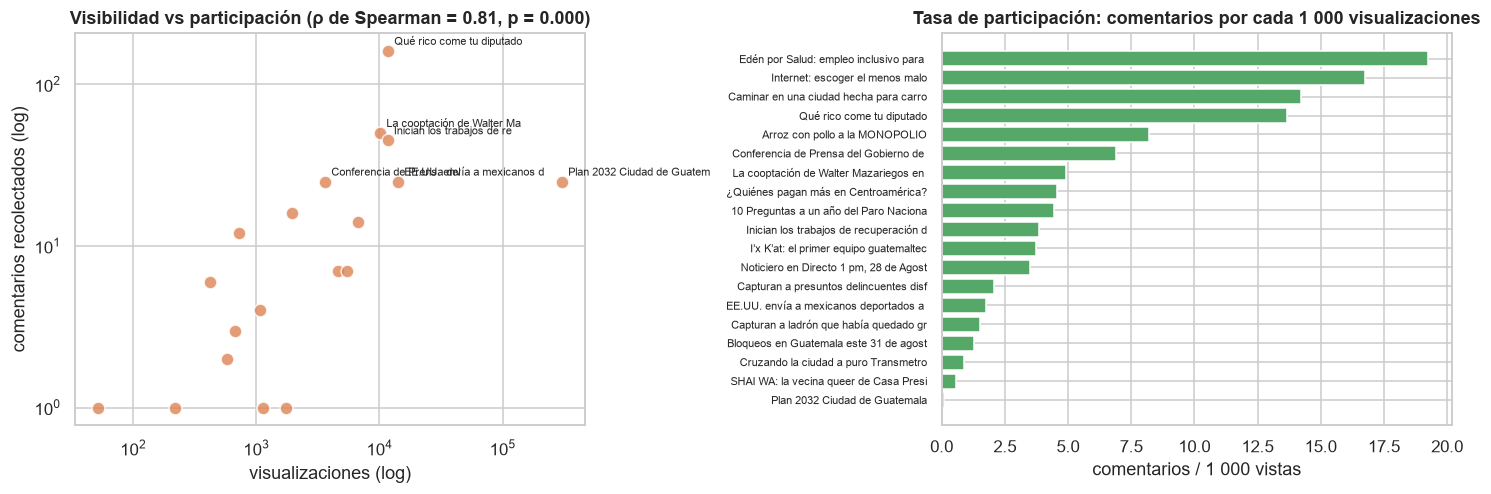

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))

axes[0].scatter(d["vistas"], d["n_comentarios"], s=70, alpha=.8,
                color=COL["video"], edgecolor="white", zorder=3)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("visualizaciones (log)")
axes[0].set_ylabel("comentarios recolectados (log)")
axes[0].set_title(f"Visibilidad vs participación (ρ de Spearman = {rho:.2f}, p = {p_rho:.3f})")
for _, fila in d.iterrows():
    if fila["n_comentarios"] >= 20 or fila["vistas"] > 1e5:
        axes[0].annotate(fila["titulo"][:26], (fila["vistas"], fila["n_comentarios"]),
                         fontsize=7, xytext=(4, 4), textcoords="offset points")

dd = d.sort_values("tasa_com_por_1000_vistas", ascending=True)
axes[1].barh(dd["titulo"].str.slice(0, 38), dd["tasa_com_por_1000_vistas"], color=COL["acento"])
axes[1].set_title("Tasa de participación: comentarios por cada 1 000 visualizaciones")
axes[1].set_xlabel("comentarios / 1 000 vistas")
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
guardar_fig("f3_3_popularidad_participacion")
plt.show()

### Interpretación

Entre los 19 videos observados hay una **asociación positiva fuerte y significativa**: Spearman
ρ = **0.811** (p < 0.001) frente a comentarios, ρ = 0.812 frente a autores únicos, y Pearson
r = 0.718 en escala logarítmica. En **orden**, los más vistos tienden a ser los más comentados.

Pero **la asociación en rangos no implica proporcionalidad**: la tasa de participación varía **240×**
entre videos.

| Video | Vistas | Comentarios | Por 1 000 vistas |
|---|---:|---:|---:|
| `Plan 2032` (Municipalidad) | 304 089 | 25 | **0.08** |
| `Qué rico come tu diputado` (Quorum) | 11 775 | 161 | **13.67** |

El video más visto tiene **26× más visualizaciones y 6× menos comentarios** que el más comentado.
La visibilidad no se traduce en participación a ritmo constante.

### Limitaciones de ambos conteos

La correlación no es una estimación fiable de la relación real, por cuatro razones acumulativas:

1. **Truncamiento por el recolector.** Los 161 comentarios no son "todos": son los capturados. El
   tope comprime la parte alta de la distribución y distorsiona la magnitud.
2. **Selección no aleatoria.** 11 de los 19 videos vienen de un mismo canal → **sesgo de selección**;
   con n = 19, el intervalo de confianza es además muy amplio.
3. **Horizontes temporales distintos.** `view_count` es un acumulado histórico; los comentarios son
   una muestra instantánea. Un video de hace ocho años acumuló vistas durante años. `published_time`
   es relativa, así que no se puede normalizar por antigüedad.
4. **Ninguno de los conteos es estable** (§2.1.f).

**Conclusión defendible:** ver y comentar **covarían en el orden**, pero **no en la intensidad**.
Ambas son afirmaciones descriptivas sobre la muestra, no inferencias causales ni generalizables.

## 3.4. Visualizaciones adicionales

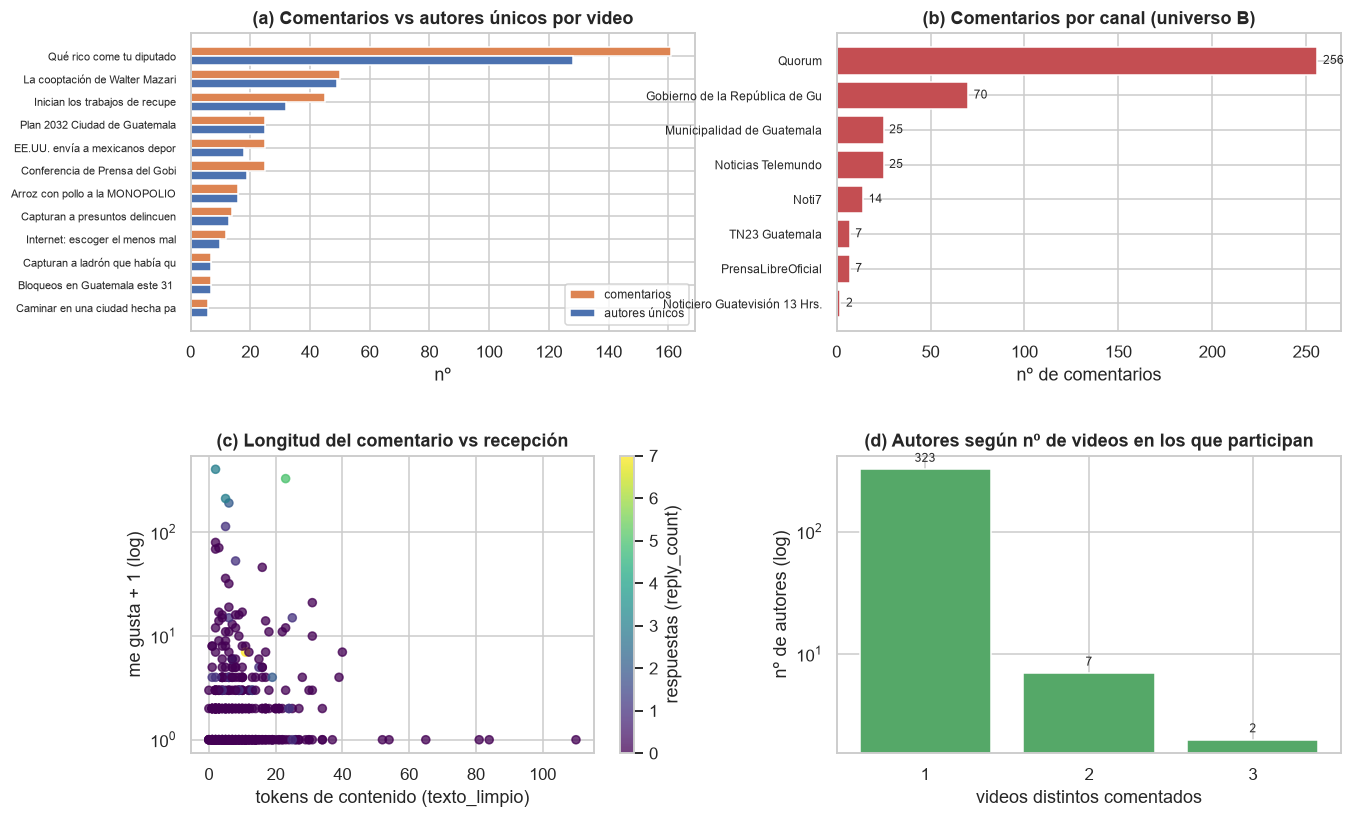

In [58]:
fig = plt.figure(figsize=(13.5, 8.5))
gs = fig.add_gridspec(2, 2, hspace=.42, wspace=.28)

# (a) Comentarios y autores únicos por video
ax = fig.add_subplot(gs[0, 0])
pv = por_video.sort_values("n_comentarios").tail(12)
y = np.arange(len(pv))
ax.barh(y + .2, pv["n_comentarios"], .4, color=COL["video"], label="comentarios")
ax.barh(y - .2, pv["n_autores"], .4, color=COL["autor"], label="autores únicos")
ax.set_yticks(y)
ax.set_yticklabels(pv["titulo"].str.slice(0, 30), fontsize=7)
ax.set_title("(a) Comentarios vs autores únicos por video")
ax.set_xlabel("nº")
ax.legend(fontsize=8)

# (b) Participación por canal
ax = fig.add_subplot(gs[0, 1])
pc = por_canal_com.sort_values("n_comentarios")
ax.barh(pc["channel_name_v"].str.slice(0, 30), pc["n_comentarios"], color=COL["alerta"])
ax.set_title("(b) Comentarios por canal (universo B)")
ax.set_xlabel("nº de comentarios")
ax.tick_params(axis="y", labelsize=8)
for i, v in enumerate(pc["n_comentarios"]):
    ax.text(v + 3, i, str(v), va="center", fontsize=8)

# (c) Relación me gusta / longitud
ax = fig.add_subplot(gs[1, 0])
sc = ax.scatter(comments["n_tokens"], comments["like_count"] + 1,
                c=comments["reply_count"], cmap="viridis", s=28, alpha=.75)
ax.set_yscale("log")
ax.set_xlabel("tokens de contenido (texto_limpio)")
ax.set_ylabel("me gusta + 1 (log)")
ax.set_title("(c) Longitud del comentario vs recepción")
plt.colorbar(sc, ax=ax, label="respuestas (reply_count)")

# (d) Recuento de autores según nº de videos en los que participan
ax = fig.add_subplot(gs[1, 1])
dist_v = por_autor["n_videos"].value_counts().sort_index()
barras = ax.bar(dist_v.index.astype(str), dist_v.values, color=COL["acento"])
ax.set_yscale("log")
ax.set_title("(d) Autores según nº de videos en los que participan")
ax.set_xlabel("videos distintos comentados")
ax.set_ylabel("nº de autores (log)")
for rect, v in zip(barras, dist_v.values):
    ax.text(rect.get_x() + rect.get_width() / 2, v * 1.15, str(v), ha="center", fontsize=8)

guardar_fig("f3_4_panel_exploratorio")
plt.show()

## 3.5. Preguntas obligatorias

Para las preguntas sobre temas y sentimiento se calcula un indicador **preliminar** de polaridad por
léxico. El tratamiento formal corresponde a la sección 9; aquí es sólo evidencia orientativa.

In [59]:
# --- Indicador PRELIMINAR de sentimiento (léxico en español + emojis) --------
LEX_POS = {
    "bueno", "buena", "excelente", "gracias", "felicidad", "feliz", "mejor", "bien",
    "genial", "hermoso", "lindo", "amor", "apoyo", "apoyar", "exito", "esperanza",
    "orgullo", "orgulloso", "admirar", "admiracion", "felicitar", "felicitacion",
    "bendicion", "bendecir", "gran", "grande", "maravilloso", "increible", "util",
    "interesante", "aprender", "ayudar", "ayuda", "positivo", "avanzar", "progreso",
    "justo", "justicia", "verdad", "libertad", "paz", "respeto", "valiente", "digno",
}
LEX_NEG = {
    "corrupto", "corrupcion", "malo", "mala", "peor", "pesimo", "robar", "robo", "ladron",
    "mentira", "mentiroso", "sinverguenza", "verguenza", "asco", "odio", "odiar",
    "basura", "porqueria", "estafa", "estafar", "delincuente", "criminal", "carcel",
    "impunidad", "narco", "traicion", "traidor", "fracaso", "fracasar", "pobreza",
    "miseria", "hambre", "violencia", "muerte", "matar", "morir", "miedo", "triste",
    "tristeza", "problema", "culpa", "culpable", "abuso", "abusar", "injusticia",
    "corrompido", "vendido", "payaso", "tonto", "estupido", "idiota", "inutil", "danar",
    "destruir", "desastre", "terrible", "horrible", "grave", "denunciar", "denuncia",
}
EMOJI_POS = set("😀😃😄😁😊🙂😍🥰😘👍👏🙌💪❤️❤🧡💛💚💙💜🤩😎🥳✨🎉🌟💯🙏")
EMOJI_NEG = set("😠😡🤬😤👎😢😭😞😔💔🤮🤢😱😨😰🙄😒🤡💩⚠️")


def polaridad_preliminar(fila):
    """Puntuación normalizada en [-1, 1] a partir de lemas y emojis."""
    toks = fila["tokens_limpios"]
    pos = sum(t in LEX_POS for t in toks)
    neg = sum(t in LEX_NEG for t in toks)
    for e in "".join(fila["emojis"]):
        if e in EMOJI_POS:
            pos += 1
        elif e in EMOJI_NEG:
            neg += 1
    return 0.0 if pos + neg == 0 else (pos - neg) / (pos + neg)


comments["polaridad_prelim"] = comments.apply(polaridad_preliminar, axis=1)
comments["sentimiento_prelim"] = pd.cut(
    comments["polaridad_prelim"], [-1.01, -0.05, 0.05, 1.01],
    labels=["negativo", "neutro", "positivo"])

part = comments.merge(
    videos[["video_id", "title", "channel_id", "channel_name", "category",
            "view_count", "source_group"]],
    on="video_id", how="left", suffixes=("", "_v"), validate="many_to_one")

dist_sent = comments["sentimiento_prelim"].value_counts().reindex(
    ["negativo", "neutro", "positivo"])
print("Distribución PRELIMINAR de sentimiento (léxico):")
print(dist_sent.to_string())
print(f"\nComentarios con al menos un término del léxico: "
      f"{(comments['polaridad_prelim'] != 0).sum()} de {len(comments)} "
      f"({(comments['polaridad_prelim'] != 0).mean():.1%})")
guardar_tabla(dist_sent.reset_index(), "t3_5_sentimiento_preliminar")

Distribución PRELIMINAR de sentimiento (léxico):
sentimiento_prelim
negativo     90
neutro      222
positivo     94

Comentarios con al menos un término del léxico: 184 de 406 (45.3%)


,sentimiento_prelim,count
0,negativo,90
1,neutro,222
2,positivo,94


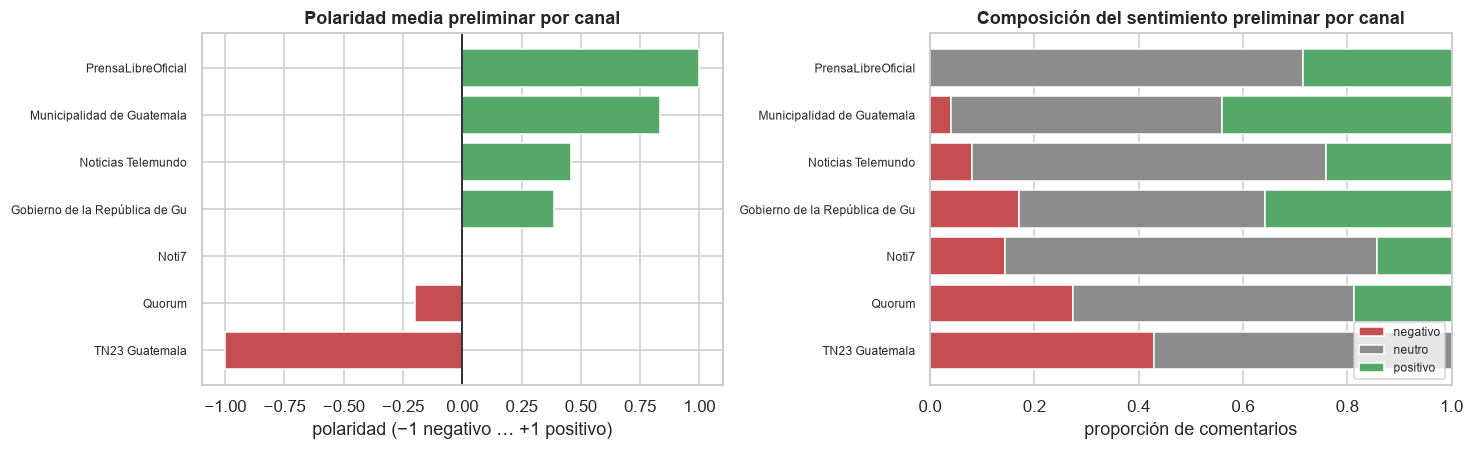

,channel_name_v,n_con_lexico,polaridad_media
6,TN23 Guatemala,3,-1.000
5,Quorum,118,-0.201
2,Noti7,4,0.000
0,Gobierno de la República de Guatemala,37,0.387
3,Noticias Telemundo,8,0.458
1,Municipalidad de Guatemala,12,0.833
4,PrensaLibreOficial,2,1.000


In [60]:
sent_canal = (part[part["polaridad_prelim"] != 0]
              .groupby("channel_name_v")
              .agg(n_con_lexico=("comment_id", "count"),
                   polaridad_media=("polaridad_prelim", "mean"))
              .reset_index().sort_values("polaridad_media"))
sent_canal["polaridad_media"] = sent_canal["polaridad_media"].round(3)
guardar_tabla(sent_canal, "t3_5_sentimiento_por_canal")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.2))
colores = [COL["alerta"] if v < 0 else COL["acento"] for v in sent_canal["polaridad_media"]]
axes[0].barh(sent_canal["channel_name_v"].str.slice(0, 30), sent_canal["polaridad_media"],
             color=colores)
axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("Polaridad media preliminar por canal")
axes[0].set_xlabel("polaridad (−1 negativo … +1 positivo)")
axes[0].tick_params(axis="y", labelsize=8)

ct = pd.crosstab(part["channel_name_v"], part["sentimiento_prelim"], normalize="index")
ct = ct.loc[sent_canal["channel_name_v"]]
izq = np.zeros(len(ct))
for col, c in [("negativo", COL["alerta"]), ("neutro", COL["gris"]), ("positivo", COL["acento"])]:
    if col in ct:
        axes[1].barh(ct.index.str.slice(0, 30), ct[col], left=izq, color=c, label=col)
        izq = izq + ct[col].values
axes[1].set_title("Composición del sentimiento preliminar por canal")
axes[1].set_xlabel("proporción de comentarios")
axes[1].tick_params(axis="y", labelsize=8)
axes[1].legend(fontsize=8, loc="lower right")

plt.tight_layout()
guardar_fig("f3_5_sentimiento_preliminar")
plt.show()
display(sent_canal)

In [61]:
# Temas por video más comentado: términos distintivos frente al resto del corpus
def terminos_distintivos(mascara, k=10, min_f=2):
    """Compara la frecuencia relativa dentro del grupo contra el resto del corpus."""
    dentro = Counter(t for lst in comments.loc[mascara, "tokens_limpios"] for t in lst)
    fuera = Counter(t for lst in comments.loc[~mascara, "tokens_limpios"] for t in lst)
    n_d, n_f = max(sum(dentro.values()), 1), max(sum(fuera.values()), 1)
    puntajes = {t: (c / n_d) / ((fuera.get(t, 0) / n_f) + 1e-6)
                for t, c in dentro.items() if c >= min_f}
    return sorted(puntajes.items(), key=lambda kv: -kv[1])[:k]


filas = []
for vid in por_video.head(5)["video_id"]:
    m = comments["video_id"] == vid
    tit = por_video.loc[por_video["video_id"] == vid, "titulo"].iloc[0]
    filas.append({
        "video": tit[:48],
        "n_comentarios": int(m.sum()),
        "polaridad_media": round(comments.loc[m & (comments['polaridad_prelim'] != 0),
                                              "polaridad_prelim"].mean(), 3),
        "terminos_distintivos": ", ".join(t for t, _ in terminos_distintivos(m, 8)),
    })
temas_video = pd.DataFrame(filas)
guardar_tabla(temas_video, "t3_5_temas_por_video")
temas_video

,video,n_comentarios,polaridad_media,terminos_distintivos
0,Qué rico come tu diputado,161,-0.509,"sueldo, comer, almuerzo, salario, comida, morir, gastar, roda"
1,La cooptación de Walter Mazariegos en la USAC,50,-0.095,"usac, estudiante, universitario, mazariego, csu, rector, lucha, vi..."
2,Inician los trabajos de recuperación del Puente,45,0.359,"obra, cambio, construccion, bukele, buje, rolar, chorro, vista"
3,Plan 2032 Ciudad de Guatemala,25,0.833,"ciudad, bello, guatebella, construir, encantar, bonito, alguno, fu..."
4,Conferencia de Prensa del Gobierno de Guatemala.,25,0.455,"colombia, parlacen, excelentisimo, acombatir, pandillero, maras, p..."


### Respuestas a las preguntas del inciso 3.5

**1) ¿Qué videos y canales concentran la mayor participación observada?**

**Videos:** `Qué rico come tu diputado` (Quorum) con 161 comentarios de 128 autores — el **39.7 %**
del total. Le siguen `La cooptación de Walter Mazariegos en la USAC` (50) y `Puente Belice II` (45).
Los tres suman el **63.1 %**.

**Canales:** Quorum con 256 comentarios (**63.1 %**) en 11 videos; Gobierno de Guatemala (70, en
2 videos); Noticias Telemundo y Municipalidad (25 cada uno).

*Advertencia:* el 57 % de los comentarios vienen de la consulta `@quorumgt/videos`, que recorrió
ese canal exhaustivamente. Es una **descripción de la muestra**, no evidencia de que Quorum genere
más conversación que otros canales.

**2) ¿Existen audiencias compartidas entre videos, canales o temas?**

**Sí, pero mínimas.** Sólo **9 de 332 autores (2.7 %)** comentaron en más de un video; el máximo
solapamiento es un autor en 3 videos. Las audiencias están **casi completamente segmentadas**.

Con 19 videos observados y comentarios truncados, la probabilidad de detectar dos veces al mismo
usuario es estructuralmente baja: lo medido es una **cota inferior** del solapamiento real.

**3) ¿Qué autores funcionan como puentes?**

Los **9 autores presentes en más de un video** son los únicos puentes posibles; el más conectado
aparece en 3 videos con 4 comentarios. La tabla siguiente los enumera; su papel estructural se
cuantifica en la sección 4 y, con centralidades, en la 8.

**4) ¿Qué temas y sentimientos caracterizan a las principales comunidades?**

Dominan la **crítica política y al gasto público** (`pueblo` 56, `pais` 56, `guatemala` 52,
`diputado` 51, `pagar` 38, `corrupto` 30) y el **comentario sobre trabajo** (`trabajo`, `sueldo`).
Bigramas: `bernardo arevalo`, `morir hambre`, `pagar sueldo`, `pacto corrupto`.

**Los temas se separan nítidamente por video, y con ellos el sentimiento:**

| Video | Términos distintivos | Polaridad |
|---|---|---:|
| `Qué rico come tu diputado` | sueldo, comer, almuerzo, salario | **−0.509** |
| `Cooptación de W. Mazariegos (USAC)` | usac, estudiante, rector, lucha | **−0.095** |
| `Puente Belice II` (Gobierno) | obra, construccion, cambio | **+0.359** |
| `Conferencia de Prensa` (Gobierno) | parlacen, maras, pandillero | **+0.455** |
| `Plan 2032` (Municipalidad) | ciudad, bello, construir, futuro | **+0.833** |

Emerge un eje claro: **fiscalización crítica frente a recepción institucional**. Los canales
periodísticos concentran la polaridad negativa (Quorum −0.201); los institucionales, la positiva.

*Precisiones:* positivos (94) y negativos (90) están casi empatados, con 222 neutros — pero **sólo
184 de 406 comentarios (45.3 %) contienen términos del léxico**, así que la mayoría de los neutros
lo son por *ausencia de evidencia*. TN23 (−1.0) y PrensaLibre (+1.0) se calculan sobre 3 y 2
comentarios: sin valor estadístico. La sección 9 requiere un modelo entrenado para español.

**5) ¿La visibilidad coincide con la participación observada?**

**Coincide en el orden, no en la intensidad.** Spearman ρ = **0.811** (p < 0.001, n = 19): los más
vistos tienden a estar entre los más comentados. Pero la **tasa** varía **240×** (de 0.08 a 19.23
comentarios por mil vistas): `Plan 2032` tiene 304 089 vistas y 25 comentarios, mientras
`Qué rico come tu diputado` tiene 11 775 vistas y 161.

**Alta visibilidad no equivale a alta participación.** Y, por lo dicho en §3.3, la correlación
describe la muestra sin estimar la relación real.

**6) ¿Qué conclusiones limita el procedimiento de recolección?**

| Conclusión aparente | Por qué está limitada |
|---|---|
| "Quorum genera más conversación" | Fue el único canal recorrido exhaustivamente: artefacto del diseño. |
| "El 93.5 % de los videos no tiene comentarios" | **Ausencia de datos**, no de participación. |
| "Las cuentas de gobierno no generan participación" | Los 105 videos `official_gov` tienen **0 comentarios recolectados**: nada puede afirmarse sobre ellos. |
| "Las audiencias no se solapan" | El solapamiento medido es una **cota inferior**. |
| "Los guatemaltecos comentan críticamente sobre política" | Muestra dominada por un canal de periodismo político; no representativa. |
| "Ver y comentar se relacionan (ρ = 0.81)" | Medido sobre 19 videos no aleatorios y con comentarios truncados: describe la muestra, no la población. |
| Cualquier análisis temporal | Las fechas son relativas y dependen del instante de extracción. |
| Cualquier conclusión sobre hilos | `reply_count` no identifica autores: **las respuestas son invisibles**. |

In [62]:
puentes = por_autor[por_autor["n_videos"] > 1].copy()
puentes = puentes.merge(
    comments.groupby("author_channel_id")["video_id"]
    .apply(lambda s: ", ".join(sorted(set(s)))).rename("videos_comentados"),
    on="author_channel_id", how="left")
puentes["canales_distintos"] = puentes["author_channel_id"].map(
    part.groupby("author_channel_id")["channel_name_v"].nunique())
puentes = puentes[["author_channel_id", "autor", "n_videos", "n_comentarios",
                   "canales_distintos", "me_gusta", "videos_comentados"]]
guardar_tabla(puentes, "t3_5_autores_puente")
puentes

,author_channel_id,autor,n_videos,n_comentarios,canales_distintos,me_gusta,videos_comentados
0,UCvcu1kR8xMYy_I1Ty-2mV2Q,@hashojea7348,3,4,1,0,"WIUZtitfLRw, ndAZjHqzzT8, yLZS3JiEBg8"
1,UCpsKOkt5iWTbenzeuq7dsmQ,@inge_vergueta,3,3,1,4,"j43HgwYFKfk, n8iP75gIpmw, ndAZjHqzzT8"
2,UCHTGCgY2l-DQJIvlA_cpa_Q,@virgiliogarcia3039,2,3,2,14,"PjmxCj-a9Hg, n8iP75gIpmw"
3,UCylqlpsh8ENNM1LqgQ1KbxA,@Jel.Awesh.M,2,3,1,1,"j43HgwYFKfk, n8iP75gIpmw"
4,UCbrtvygfRT6QXqWDNrOf-cA,@Alejandro00710,2,2,1,0,"ndAZjHqzzT8, yLZS3JiEBg8"
5,UCdFlugHJJa4l3YqWuNRmvXw,@MarcosCarillo-b1r,2,2,2,0,"is3Mk5oC19g, j43HgwYFKfk"
6,UCjZgFEowMBrsjodqfovzdKw,@franciscoflores3120,2,2,2,0,"06mFNPU0aB8, 6W4u8sGEnGM"
7,UCsUCN0Yq_UyTvKjOJLmNrnQ,@moisesvaldez4043,2,2,2,0,"b_Hkrkl3adA, n8iP75gIpmw"
8,UCzZ6dDCEsLMXbc5pCFXIprw,@josegil3813,2,2,1,0,"6W4u8sGEnGM, PjmxCj-a9Hg"


## 3.6. Preguntas adicionales formuladas a partir del análisis

### Pregunta A — ¿Los comentarios más largos reciben más "me gusta"?

*Motivación:* si la elaboración se recompensara, la participación de calidad tendría recompensa
visible; si no, la visibilidad dependería de otros factores.

In [63]:
rho_len, p_len = stats.spearmanr(comments["n_tokens"], comments["like_count"])
rho_len_c, p_len_c = stats.spearmanr(comments["len_original"], comments["like_count"])
rho_rep, p_rep = stats.spearmanr(comments["like_count"], comments["reply_count"])

comments["cuartil_longitud"] = pd.qcut(comments["n_tokens"].rank(method="first"), 4,
                                       labels=["Q1 muy corto", "Q2", "Q3", "Q4 muy largo"])
tabla_a = (comments.groupby("cuartil_longitud")
           .agg(n=("comment_id", "count"), tokens_medianos=("n_tokens", "median"),
                me_gusta_medio=("like_count", "mean"), me_gusta_mediano=("like_count", "median"),
                pct_con_me_gusta=("like_count", lambda s: round(100 * (s > 0).mean(), 1)))
           .reset_index())
guardar_tabla(tabla_a, "t3_6_a_longitud_likes")

print(f"Spearman  tokens vs me gusta        : ρ = {rho_len:.3f} (p = {p_len:.4f})")
print(f"Spearman  caracteres vs me gusta    : ρ = {rho_len_c:.3f} (p = {p_len_c:.4f})")
print(f"Spearman  me gusta vs respuestas    : ρ = {rho_rep:.3f} (p = {p_rep:.4f})")
display(tabla_a)

Spearman  tokens vs me gusta        : ρ = -0.027 (p = 0.5872)
Spearman  caracteres vs me gusta    : ρ = -0.000 (p = 0.9967)
Spearman  me gusta vs respuestas    : ρ = 0.251 (p = 0.0000)


,cuartil_longitud,n,tokens_medianos,me_gusta_medio,me_gusta_mediano,pct_con_me_gusta
0,Q1 muy corto,102,2.0,7.441176,1.0,55.9
1,Q2,101,5.0,7.821782,1.0,55.4
2,Q3,101,10.0,2.267327,1.0,52.5
3,Q4 muy largo,102,19.0,5.362745,0.5,50.0


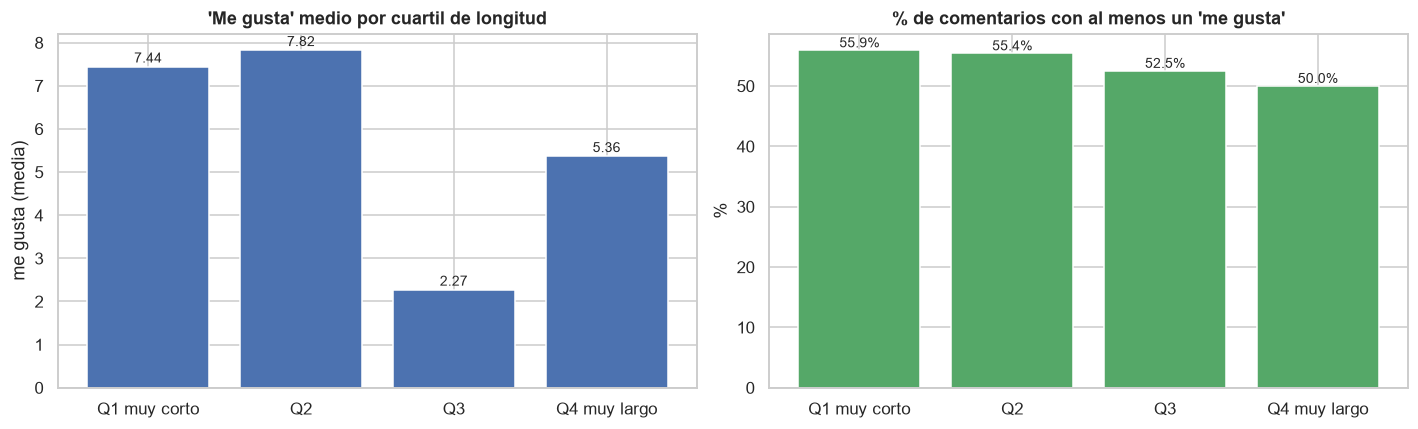

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(tabla_a["cuartil_longitud"].astype(str), tabla_a["me_gusta_medio"],
            color=COL["autor"])
axes[0].set_title("'Me gusta' medio por cuartil de longitud")
axes[0].set_ylabel("me gusta (media)")
for i, v in enumerate(tabla_a["me_gusta_medio"]):
    axes[0].text(i, v + .1, f"{v:.2f}", ha="center", fontsize=9)

axes[1].bar(tabla_a["cuartil_longitud"].astype(str), tabla_a["pct_con_me_gusta"],
            color=COL["acento"])
axes[1].set_title("% de comentarios con al menos un 'me gusta'")
axes[1].set_ylabel("%")
for i, v in enumerate(tabla_a["pct_con_me_gusta"]):
    axes[1].text(i, v + .5, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
guardar_fig("f3_6_a_longitud_likes")
plt.show()

**Respuesta A: no, la longitud es irrelevante.** La correlación es prácticamente **nula**:
ρ = −0.027 (p = 0.587) en tokens y ρ = −0.001 (p = 0.991) en caracteres.

Los cuartiles añaden un matiz: el porcentaje que recibe al menos un "me gusta" **desciende** con la
longitud (55.9 % → 50.0 %) y la mediana cae de 1 a 0.5. Si acaso, los comentarios largos son
*levemente* peor recibidos.

Esto desmiente la hipótesis de partida: **la elaboración no se recompensa**. La aprobación depende
de factores no observados aquí (posición en el hilo, momento, algoritmo de ordenación).

En cambio sí hay asociación entre las dos formas de recepción: **"me gusta" y respuestas covarían**
(ρ = 0.251, p < 0.001). Asociación descriptiva, no causal.

### Pregunta B — ¿La participación es igual en contenido institucional que en periodístico?

*Motivación:* si el tipo de emisor cambiara el patrón de participación, sería un hallazgo sustantivo
más allá del muestreo.

In [65]:
CANALES_INSTITUCIONALES = {"Gobierno de la República de Guatemala", "Municipalidad de Guatemala"}
part["tipo_emisor"] = np.where(part["channel_name_v"].isin(CANALES_INSTITUCIONALES),
                               "institucional", "medio periodístico")

tabla_b = (part.groupby("tipo_emisor")
           .agg(n_videos=("video_id", "nunique"), n_comentarios=("comment_id", "count"),
                n_autores=("author_channel_id", "nunique"),
                me_gusta_medio=("like_count", "mean"),
                me_gusta_mediano=("like_count", "median"),
                me_gusta_max=("like_count", "max"),
                tokens_medianos=("n_tokens", "median"),
                polaridad_media=("polaridad_prelim", "mean"),
                respuestas_totales=("reply_count", "sum"))
           .reset_index())
tabla_b["comentarios_por_video"] = (tabla_b["n_comentarios"] / tabla_b["n_videos"]).round(1)
tabla_b["autores_por_comentario"] = (tabla_b["n_autores"] / tabla_b["n_comentarios"]).round(3)
tabla_b[["me_gusta_medio", "polaridad_media"]] = tabla_b[["me_gusta_medio", "polaridad_media"]].round(3)
guardar_tabla(tabla_b, "t3_6_b_tipo_emisor")

# Prueba no paramétrica: ¿difieren las distribuciones de "me gusta"?
g1 = part.loc[part["tipo_emisor"] == "institucional", "like_count"]
g2 = part.loc[part["tipo_emisor"] == "medio periodístico", "like_count"]
u, p_u = stats.mannwhitneyu(g1, g2, alternative="two-sided")
print(f"Mann-Whitney U sobre 'me gusta' (institucional vs periodístico): U = {u:.0f}, p = {p_u:.5f}")

s1 = part.loc[part["tipo_emisor"] == "institucional", "polaridad_prelim"]
s2 = part.loc[part["tipo_emisor"] == "medio periodístico", "polaridad_prelim"]
u2, p_u2 = stats.mannwhitneyu(s1, s2, alternative="two-sided")
print(f"Mann-Whitney U sobre polaridad preliminar                     : U = {u2:.0f}, p = {p_u2:.5f}")
display(tabla_b)

Mann-Whitney U sobre 'me gusta' (institucional vs periodístico): U = 18488, p = 0.00008
Mann-Whitney U sobre polaridad preliminar                     : U = 18444, p = 0.00005


,tipo_emisor,n_videos,n_comentarios,n_autores,me_gusta_medio,me_gusta_mediano,me_gusta_max,tokens_medianos,polaridad_media,respuestas_totales,comentarios_por_video,autores_por_comentario
0,institucional,3,95,75,19.021,1.0,405,7.0,0.256,31,31.7,0.789
1,medio periodístico,16,311,259,1.666,0.0,31,7.0,-0.068,20,19.4,0.833


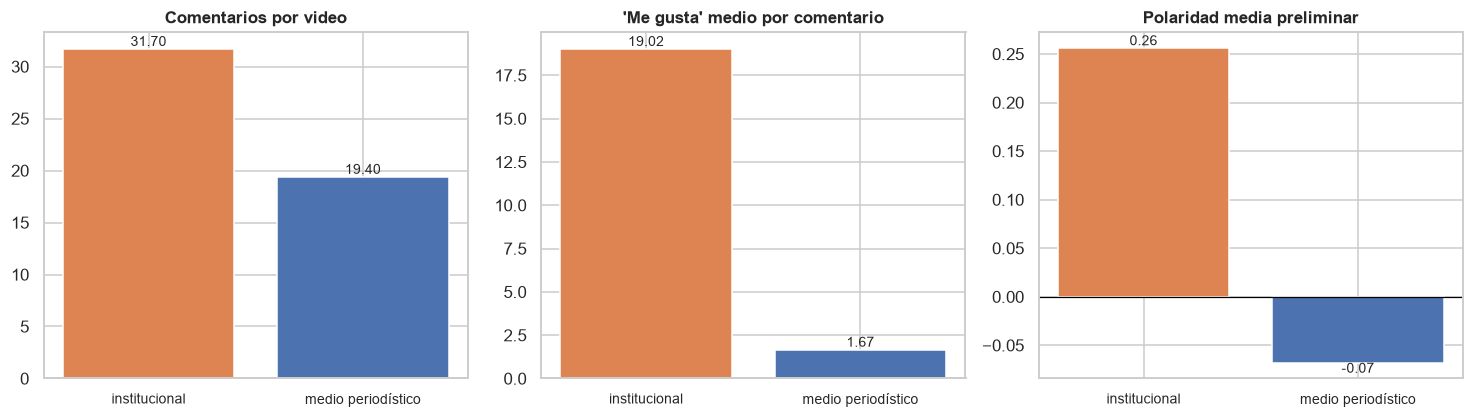

In [66]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))
for ax, col, tit in zip(
        axes,
        ["comentarios_por_video", "me_gusta_medio", "polaridad_media"],
        ["Comentarios por video", "'Me gusta' medio por comentario", "Polaridad media preliminar"]):
    colores = [COL["video"] if t == "institucional" else COL["autor"]
               for t in tabla_b["tipo_emisor"]]
    ax.bar(tabla_b["tipo_emisor"], tabla_b[col], color=colores)
    ax.set_title(tit, fontsize=11)
    ax.axhline(0, color="black", lw=.8)
    ax.tick_params(axis="x", labelsize=9)
    for i, v in enumerate(tabla_b[col]):
        ax.text(i, v, f"{v:.2f}", ha="center",
                va="bottom" if v >= 0 else "top", fontsize=9)
plt.tight_layout()
guardar_fig("f3_6_b_tipo_emisor")
plt.show()

**Respuesta B: sí, las diferencias son grandes y significativas.**

| Indicador | Institucional (3 videos) | Periodístico (16 videos) |
|---|---:|---:|
| Comentarios por video | **31.7** | 19.4 |
| "Me gusta" medio | **19.02** | 1.67 |
| Polaridad media | **+0.256** | −0.068 |

Mann-Whitney significativa en ambos: "me gusta" (U = 18 488, p = 0.00008) y polaridad
(U = 18 444, p = 0.00005). El contenido institucional recibe más comentarios por video, "me gusta"
**once veces más altos** en media y polaridad **positiva**; el periodístico genera conversación
**crítica** y con menor respaldo entre pares.

**Cautelas:** (i) la media de "me gusta" es sensible a extremos (hay comentarios con cientos), así
que la conclusión se apoya en el contraste de rangos, no en la media; (ii) sólo hay **3 videos
institucionales**; (iii) el tipo de emisor está **confundido** con el tema, la antigüedad y el
muestreo.

Con esas reservas: el contenido institucional convoca una audiencia que **valida**, el periodístico
una que **fiscaliza**. Es una asociación, no una relación causal.

### Pregunta C — ¿Cuánto depende la conectividad de la red del muestreo de un solo canal?

*Motivación:* si los 9 autores puente pertenecieran todos al mismo canal, la conectividad de la
sección 4 sería un subproducto del recorrido de `@quorumgt`, no una propiedad de la conversación.

In [67]:
canales_por_autor_puente = (part[part["author_channel_id"].isin(puentes["author_channel_id"])]
                            .groupby("author_channel_id")
                            .agg(n_videos=("video_id", "nunique"),
                                 n_canales=("channel_name_v", "nunique"),
                                 canales=("channel_name_v", lambda s: " | ".join(sorted(set(s)))))
                            .reset_index())
guardar_tabla(canales_por_autor_puente, "t3_6_c_puentes_canales")

n_intra = int((canales_por_autor_puente["n_canales"] == 1).sum())
n_inter = int((canales_por_autor_puente["n_canales"] > 1).sum())
print(f"Autores puente que conectan videos DEL MISMO canal : {n_intra}")
print(f"Autores puente que conectan videos DE CANALES DISTINTOS: {n_inter}")
print()

# Cuota de participación aportada por el canal dominante
cuota_quorum = part[part["channel_name_v"] == "Quorum"]
print(f"Comentarios de Quorum          : {len(cuota_quorum)} ({len(cuota_quorum)/len(part):.1%})")
print(f"Autores exclusivos de Quorum   : "
      f"{cuota_quorum['author_channel_id'].nunique()} de {part['author_channel_id'].nunique()}")
display(canales_por_autor_puente)

Autores puente que conectan videos DEL MISMO canal : 5
Autores puente que conectan videos DE CANALES DISTINTOS: 4

Comentarios de Quorum          : 256 (63.1%)
Autores exclusivos de Quorum   : 214 de 332


,author_channel_id,n_videos,n_canales,canales
0,UCHTGCgY2l-DQJIvlA_cpa_Q,2,2,Gobierno de la República de Guatemala | Quorum
1,UCbrtvygfRT6QXqWDNrOf-cA,2,1,Quorum
2,UCdFlugHJJa4l3YqWuNRmvXw,2,2,Quorum | TN23 Guatemala
3,UCjZgFEowMBrsjodqfovzdKw,2,2,Gobierno de la República de Guatemala | Noti7
4,UCpsKOkt5iWTbenzeuq7dsmQ,3,1,Quorum
5,UCsUCN0Yq_UyTvKjOJLmNrnQ,2,2,PrensaLibreOficial | Quorum
6,UCvcu1kR8xMYy_I1Ty-2mV2Q,3,1,Quorum
7,UCylqlpsh8ENNM1LqgQ1KbxA,2,1,Quorum
8,UCzZ6dDCEsLMXbc5pCFXIprw,2,1,Gobierno de la República de Guatemala


**Respuesta C: la dependencia del muestreo es muy fuerte, aunque no absoluta.** De los 9 autores
puente, **5 conectan videos del mismo canal** (Quorum 4, Gobierno 1) y **4 conectan canales
distintos** (Gobierno–Quorum, Quorum–TN23, Gobierno–Noti7, PrensaLibre–Quorum).

El dato decisivo es otro: **los 9, sin excepción, pasan por Quorum o por el Gobierno** — los dos
emisores más muestreados (63.1 % y 17.2 % de los comentarios). Ninguno conecta Telemundo con
Municipalidad, ni TN23 con PrensaLibre.

**Implicación para la sección 4:** el tamaño de la componente mayor **no mide la cohesión de la
conversación**, sino la intensidad con que se muestrearon dos emisores. Con muestreo uniforme, la
red sería aún más fragmentada.

Dicho esto, que **4 autores crucen fronteras de canal** —incluso entre un medio crítico y una cuenta
gubernamental— no es artefacto: hay un núcleo muy pequeño que participa en espacios de signo
opuesto. Su papel se cuantifica en las secciones 6 y 8.

---
# 4. Construcción de la red bipartita autor–video

## 4.1. Definición formal de la red

Se construye un grafo **bipartito y no dirigido** $G = (U \cup V,\; E,\; w)$ donde:

- $U$ = conjunto de **autores**, identificados por `author_channel_id` (332 nodos).
- $V$ = conjunto de **videos**, identificados por `video_id` (19 nodos: sólo los que tienen
  comentarios recolectados).
- $E \subseteq U \times V$ = existe la arista $(u, v)$ **si y sólo si** el autor $u$ escribió al
  menos un comentario en el video $v$.
- $w(u, v)$ = **número de comentarios** que $u$ publicó en $v$.

### ¿Por qué bipartita y no dirigida?

- **Bipartita**: no existe relación observable *dentro* de cada clase — ni autor–autor (no se sabe
  quién responde a quién) ni video–video. Los conjuntos son además **disjuntos** (§1.2).
- **No dirigida**: "participó en" no tiene orientación informativa. Toda arista iría de autor a
  video, así que la dirección sería constante y, por tanto, sin contenido.

**Los identificadores son los nodos** (`author_channel_id`, `video_id`); nombres, handles y títulos
entran sólo como atributos de etiqueta (§2.3).

In [68]:
import networkx as nx
from networkx.algorithms import bipartite

# --- Tabla de aristas: peso = nº de comentarios del autor en el video --------
aristas = (comments.groupby(["author_channel_id", "video_id"])
           .agg(weight=("comment_id", "count"),
                me_gusta=("like_count", "sum"),
                respuestas=("reply_count", "sum"),
                tokens=("n_tokens", "sum"),
                polaridad_media=("polaridad_prelim", "mean"))
           .reset_index())
aristas["polaridad_media"] = aristas["polaridad_media"].round(3)

print(f"Comentarios totales            : {len(comments)}")
print(f"Aristas únicas (autor, video)   : {len(aristas)}")
print(f"Suma de los pesos               : {int(aristas['weight'].sum())}  "
      f"(debe coincidir con los comentarios)")
assert aristas["weight"].sum() == len(comments), "Los pesos no conservan el total de comentarios"
print("\nDistribución de los pesos de arista:")
print(aristas["weight"].value_counts().sort_index().rename("nº de aristas").to_string())

Comentarios totales            : 406
Aristas únicas (autor, video)   : 343
Suma de los pesos               : 406  (debe coincidir con los comentarios)

Distribución de los pesos de arista:
weight
1    303
2     28
3      7
4      1
5      2
6      2


In [69]:
# --- Construcción del grafo --------------------------------------------------
G = nx.Graph()

autores_ids = sorted(comments["author_channel_id"].unique())
videos_ids = sorted(comments["video_id"].unique())

# bipartite=0 -> autores ; bipartite=1 -> videos  (convención de networkx)
G.add_nodes_from(autores_ids, bipartite=0, tipo="autor")
G.add_nodes_from(videos_ids, bipartite=1, tipo="video")

for _, fila in aristas.iterrows():
    G.add_edge(fila["author_channel_id"], fila["video_id"],
               weight=int(fila["weight"]),
               me_gusta=int(fila["me_gusta"]),
               respuestas=int(fila["respuestas"]),
               polaridad_media=float(fila["polaridad_media"]))

print(f"Nodos totales : {G.number_of_nodes()}  "
      f"({len(autores_ids)} autores + {len(videos_ids)} videos)")
print(f"Aristas       : {G.number_of_edges()}")
print(f"¿Es bipartito?: {bipartite.is_bipartite(G)}")
print(f"Densidad bipartita: {bipartite.density(G, autores_ids):.4f}")

Nodos totales : 351  (332 autores + 19 videos)
Aristas       : 343
¿Es bipartito?: True
Densidad bipartita: 0.0544


Sí es bipartito.

## 4.2. Aristas y pesos: verificación

La suma de pesos (406) coincide con el número de comentarios: **la ponderación conserva toda la
información** sin duplicarla ni perderla.

De las 343 aristas, 303 tienen **peso 1**; sólo 40 tienen peso ≥ 2 y el máximo es 6. **La
participación repetida en un mismo video es infrecuente.**

Aquí se observarán cuántas veces un usuario comenta en un
 video. A partir de ello se asigna el peso.

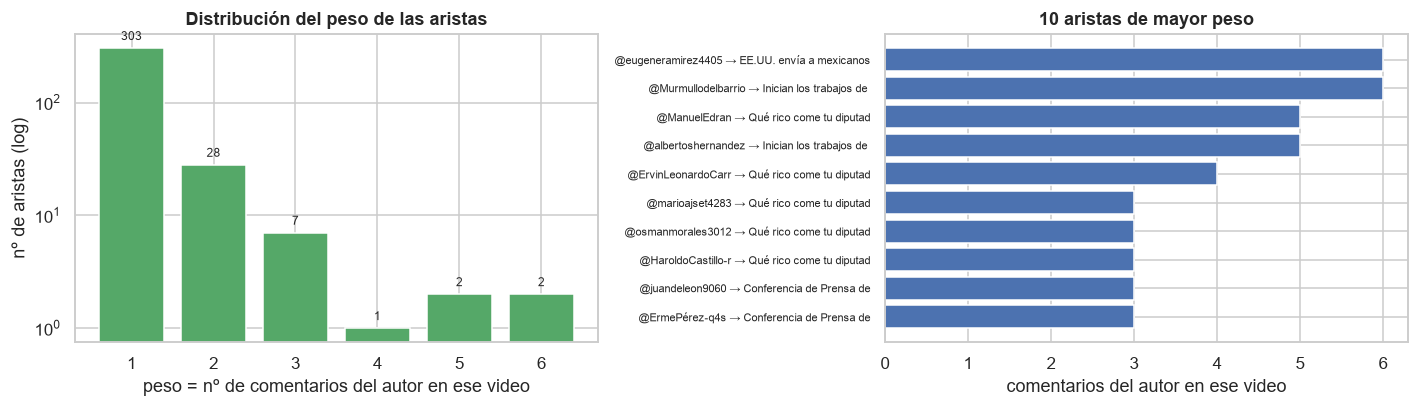

,indicador,valor
0,Comentarios en el conjunto de datos,406.000
1,Aristas únicas (pares autor–video),343.000
2,Suma de los pesos de las aristas,406.000
3,Aristas con peso = 1 (un solo comentario),303.000
4,Aristas con peso ≥ 2 (participación repetida),40.000
5,Peso máximo observado,6.000
6,Peso medio,1.184


In [70]:
verificacion_pesos = pd.DataFrame([
    ["Comentarios en el conjunto de datos", len(comments)],
    ["Aristas únicas (pares autor–video)", G.number_of_edges()],
    ["Suma de los pesos de las aristas", int(sum(d["weight"] for _, _, d in G.edges(data=True)))],
    ["Aristas con peso = 1 (un solo comentario)", int((aristas["weight"] == 1).sum())],
    ["Aristas con peso ≥ 2 (participación repetida)", int((aristas["weight"] >= 2).sum())],
    ["Peso máximo observado", int(aristas["weight"].max())],
    ["Peso medio", round(float(aristas["weight"].mean()), 3)],
], columns=["indicador", "valor"])
guardar_tabla(verificacion_pesos, "t4_2_verificacion_pesos")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
vc = aristas["weight"].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color=COL["acento"])
axes[0].set_yscale("log")
axes[0].set_title("Distribución del peso de las aristas")
axes[0].set_xlabel("peso = nº de comentarios del autor en ese video")
axes[0].set_ylabel("nº de aristas (log)")
for i, v in enumerate(vc.values):
    axes[0].text(i, v * 1.18, str(v), ha="center", fontsize=8)

top_ar = (aristas.merge(comments[["author_channel_id", "author_name"]].drop_duplicates(),
                        on="author_channel_id")
          .merge(videos[["video_id", "title"]], on="video_id")
          .nlargest(10, "weight").iloc[::-1])
etq = top_ar["author_name"].str.slice(0, 18) + " → " + top_ar["title"].str.slice(0, 24)
axes[1].barh(etq, top_ar["weight"], color=COL["autor"])
axes[1].set_title("10 aristas de mayor peso")
axes[1].set_xlabel("comentarios del autor en ese video")
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
guardar_fig("f4_2_pesos_aristas")
plt.show()
verificacion_pesos

## 4.3. Tabla de nodos y tabla de aristas

Ambas se entregan en `outputs/tables/` como CSV, listas para reimportarse en `networkx`, `igraph` o
**Gephi**, con el **tipo de nodo** y los atributos relevantes de cada clase.

In [71]:
# ---------- Métricas estructurales básicas para incorporar como atributos ----
grado = dict(G.degree())
grado_pond = dict(G.degree(weight="weight"))

# ---------- TABLA DE NODOS: autores -----------------------------------------
attr_autores = (comments.groupby("author_channel_id")
                .agg(etiqueta=("author_name", "first"),
                     handle=("author_handle_norm", "first"),
                     n_comentarios=("comment_id", "count"),
                     n_videos=("video_id", "nunique"),
                     me_gusta_total=("like_count", "sum"),
                     respuestas_recibidas=("reply_count", "sum"),
                     tokens_totales=("n_tokens", "sum"),
                     polaridad_media=("polaridad_prelim", "mean"))
                .reset_index().rename(columns={"author_channel_id": "id"}))
attr_autores["tipo"] = "autor"
attr_autores["n_canales"] = attr_autores["id"].map(
    part.groupby("author_channel_id")["channel_name_v"].nunique())
attr_autores["es_puente_potencial"] = attr_autores["n_videos"] > 1

# ---------- TABLA DE NODOS: videos ------------------------------------------
attr_videos = (part.groupby("video_id")
               .agg(n_comentarios=("comment_id", "count"),
                    n_videos=("video_id", "nunique"),
                    me_gusta_total=("like_count", "sum"),
                    respuestas_recibidas=("reply_count", "sum"),
                    tokens_totales=("n_tokens", "sum"),
                    polaridad_media=("polaridad_prelim", "mean"))
               .reset_index()
               .merge(videos[["video_id", "title", "channel_id", "channel_name",
                              "channel_handle_norm", "category", "view_count",
                              "publish_date", "source_group", "source_query"]],
                      on="video_id", how="left")
               .rename(columns={"video_id": "id", "title": "etiqueta",
                                "channel_handle_norm": "handle"}))
attr_videos["tipo"] = "video"
attr_videos["n_autores"] = attr_videos["id"].map(
    comments.groupby("video_id")["author_channel_id"].nunique())
attr_videos = attr_videos.drop(columns=["n_videos"])

# ---------- Unión en una única tabla de nodos --------------------------------
COLS_NODOS = ["id", "tipo", "etiqueta", "handle", "grado", "grado_ponderado",
              "n_comentarios", "n_autores", "n_videos", "n_canales",
              "me_gusta_total", "respuestas_recibidas", "tokens_totales",
              "polaridad_media", "channel_id", "channel_name", "category",
              "view_count", "publish_date", "source_group", "source_query",
              "es_puente_potencial", "componente"]

nodos = pd.concat([attr_autores, attr_videos], ignore_index=True)
nodos["grado"] = nodos["id"].map(grado)
nodos["grado_ponderado"] = nodos["id"].map(grado_pond)
nodos["polaridad_media"] = nodos["polaridad_media"].round(3)

# Componente conexa a la que pertenece cada nodo (0 = la mayor)
componentes = sorted(nx.connected_components(G), key=len, reverse=True)
mapa_comp = {n: i for i, c in enumerate(componentes) for n in c}
nodos["componente"] = nodos["id"].map(mapa_comp)
nx.set_node_attributes(G, mapa_comp, "componente")

for c in COLS_NODOS:
    if c not in nodos.columns:
        nodos[c] = np.nan
nodos = nodos[COLS_NODOS].sort_values(["tipo", "grado"], ascending=[True, False])

guardar_tabla(nodos, "t4_3_tabla_nodos")
print(f"TABLA DE NODOS: {len(nodos)} filas "
      f"({(nodos['tipo'] == 'autor').sum()} autores, {(nodos['tipo'] == 'video').sum()} videos)\n")
display(nodos[nodos["tipo"] == "video"]
        [["id", "tipo", "etiqueta", "grado", "grado_ponderado", "n_comentarios",
          "n_autores", "channel_name", "view_count", "componente"]])

TABLA DE NODOS: 351 filas (332 autores, 19 videos)



,id,tipo,etiqueta,grado,grado_ponderado,n_comentarios,n_autores,channel_name,view_count,componente
346,n8iP75gIpmw,video,Qué rico come tu diputado,128,161,161,128.0,Quorum,11775,0
344,j43HgwYFKfk,video,La cooptación de Walter Mazariegos en la USAC,49,50,50,49.0,Quorum,10156,0
334,6W4u8sGEnGM,video,Inician los trabajos de recuperación del Puente Belice II.,32,45,45,32.0,Gobierno de la República de Guatemala,11670,0
345,lj983NWyAQY,video,Plan 2032 Ciudad de Guatemala,25,25,25,25.0,Municipalidad de Guatemala,304089,1
337,PjmxCj-a9Hg,video,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,19,25,25,19.0,Gobierno de la República de Guatemala,3628,0
336,OkXlHx0hx-8,video,EE.UU. envía a mexicanos deportados a Guatemala antes de su regres...,18,25,25,18.0,Noticias Telemundo,14200,2
349,yLZS3JiEBg8,video,Arroz con pollo a la MONOPOLIO,16,16,16,16.0,Quorum,1954,0
332,06mFNPU0aB8,video,Capturan a presuntos delincuentes disfrazados de mujer señalados d...,13,14,14,13.0,Noti7,6692,0
347,ndAZjHqzzT8,video,Internet: escoger el menos malo,10,12,12,10.0,Quorum,717,0
342,b_Hkrkl3adA,video,Bloqueos en Guatemala este 31 de agosto por alza en combustibles a...,7,7,7,7.0,PrensaLibreOficial,5469,0


#Qué rico come tu diputado

In [72]:
print("TABLA DE NODOS — autores con mayor grado (participación más diversa):")
display(nodos[nodos["tipo"] == "autor"]
        [["id", "tipo", "etiqueta", "handle", "grado", "grado_ponderado", "n_comentarios",
          "n_videos", "n_canales", "me_gusta_total", "es_puente_potencial", "componente"]].head(12))

TABLA DE NODOS — autores con mayor grado (participación más diversa):


,id,tipo,etiqueta,handle,grado,grado_ponderado,n_comentarios,n_videos,n_canales,me_gusta_total,es_puente_potencial,componente
276,UCpsKOkt5iWTbenzeuq7dsmQ,autor,@inge_vergueta,inge_vergueta,3,3,3,3.0,1.0,4,True,0
307,UCvcu1kR8xMYy_I1Ty-2mV2Q,autor,@hashojea7348,hashojea7348,3,4,4,3.0,1.0,0,True,0
98,UCHTGCgY2l-DQJIvlA_cpa_Q,autor,@virgiliogarcia3039,virgiliogarcia3039,2,3,3,2.0,2.0,14,True,0
207,UCbrtvygfRT6QXqWDNrOf-cA,autor,@Alejandro00710,alejandro00710,2,2,2,2.0,1.0,0,True,0
211,UCdFlugHJJa4l3YqWuNRmvXw,autor,@MarcosCarillo-b1r,marcoscarillo-b1r,2,2,2,2.0,2.0,0,True,0
250,UCjZgFEowMBrsjodqfovzdKw,autor,@franciscoflores3120,franciscoflores3120,2,2,2,2.0,2.0,0,True,0
287,UCsUCN0Yq_UyTvKjOJLmNrnQ,autor,@moisesvaldez4043,moisesvaldez4043,2,2,2,2.0,2.0,0,True,0
325,UCylqlpsh8ENNM1LqgQ1KbxA,autor,@Jel.Awesh.M,jel.awesh.m,2,3,3,2.0,1.0,1,True,0
330,UCzZ6dDCEsLMXbc5pCFXIprw,autor,@josegil3813,josegil3813,2,2,2,2.0,1.0,0,True,0
0,UC-HeUTT6_g-VoiWds2a4H-w,autor,@JorgeMunoz-gd9et,jorgemunoz-gd9et,1,1,1,1.0,1.0,0,False,0


In [73]:
# ---------- TABLA DE ARISTAS -------------------------------------------------
tabla_aristas = aristas.rename(columns={
    "author_channel_id": "source", "video_id": "target",
    "weight": "weight", "me_gusta": "me_gusta_total",
    "respuestas": "respuestas_totales"}).copy()

tabla_aristas["source_tipo"] = "autor"
tabla_aristas["target_tipo"] = "video"
tabla_aristas["type"] = "Undirected"        # columna que Gephi reconoce
tabla_aristas["source_etiqueta"] = tabla_aristas["source"].map(
    comments.drop_duplicates("author_channel_id")
    .set_index("author_channel_id")["author_name"])
tabla_aristas["target_etiqueta"] = tabla_aristas["target"].map(
    videos.set_index("video_id")["title"])
tabla_aristas["target_canal"] = tabla_aristas["target"].map(
    videos.set_index("video_id")["channel_name"])
tabla_aristas["componente"] = tabla_aristas["source"].map(mapa_comp)

tabla_aristas = tabla_aristas[[
    "source", "target", "type", "weight", "source_tipo", "target_tipo",
    "source_etiqueta", "target_etiqueta", "target_canal",
    "me_gusta_total", "respuestas_totales", "tokens", "polaridad_media", "componente"]]

guardar_tabla(tabla_aristas, "t4_3_tabla_aristas")
print(f"TABLA DE ARISTAS: {len(tabla_aristas)} filas\n")
tabla_aristas.sort_values("weight", ascending=False).head(12)

TABLA DE ARISTAS: 343 filas



,source,target,type,weight,source_tipo,target_tipo,source_etiqueta,target_etiqueta,target_canal,me_gusta_total,respuestas_totales,tokens,polaridad_media,componente
244,UCi2KiZq63sRq8Mfbcp-MelQ,OkXlHx0hx-8,Undirected,6,autor,video,@eugeneramirez4405,EE.UU. envía a mexicanos deportados a Guatemala antes de su regres...,Noticias Telemundo,1,0,50,0.000,2
331,UCyJhqmMbsvjpoarBBStA2kg,6W4u8sGEnGM,Undirected,6,autor,video,@Murmullodelbarrio,Inician los trabajos de recuperación del Puente Belice II.,Gobierno de la República de Guatemala,14,0,44,0.000,0
33,UC5H8ASmMC9WrURmzeB4ySog,n8iP75gIpmw,Undirected,5,autor,video,@ManuelEdran,Qué rico come tu diputado,Quorum,6,0,19,0.000,0
165,UCV3fr-YOixFKCZBbJP1-X4w,6W4u8sGEnGM,Undirected,5,autor,video,@albertoshernandez5251,Inician los trabajos de recuperación del Puente Belice II.,Gobierno de la República de Guatemala,17,0,45,0.800,0
57,UC9vMq1YF-e7C-VO0SHkbUTA,n8iP75gIpmw,Undirected,4,autor,video,@ErvinLeonardoCarreraLatín,Qué rico come tu diputado,Quorum,0,0,26,-0.500,0
25,UC3XTwHxygNCgjndsg-UiCQA,n8iP75gIpmw,Undirected,3,autor,video,@marioajset4283,Qué rico come tu diputado,Quorum,2,0,28,-0.333,0
46,UC72gBAtyb_VXQlYDcFrh6oQ,n8iP75gIpmw,Undirected,3,autor,video,@osmanmorales3012,Qué rico come tu diputado,Quorum,19,0,10,-0.333,0
85,UCFjudnPLoaSL1BaRuLahyHg,n8iP75gIpmw,Undirected,3,autor,video,@HaroldoCastillo-rh9iw,Qué rico come tu diputado,Quorum,3,0,14,0.000,0
120,UCNIeXbV_mEwpa412h1aqUWw,PjmxCj-a9Hg,Undirected,3,autor,video,@juandeleon9060,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Gobierno de la República de Guatemala,3,1,16,0.000,0
226,UCg3eIfd7BrsLEqS0BLkftHA,PjmxCj-a9Hg,Undirected,3,autor,video,@ErmePérez-q4s,Conferencia de Prensa del Gobierno de Guatemala. #LaRondaGt,Gobierno de la República de Guatemala,0,0,21,0.000,0


In [74]:
# ---------- Exportación del grafo para Gephi / reutilización -----------------
G_export = G.copy()
for _, fila in nodos.iterrows():
    if fila["id"] in G_export:
        G_export.nodes[fila["id"]].update({
            "tipo": fila["tipo"],
            "etiqueta": "" if pd.isna(fila["etiqueta"]) else str(fila["etiqueta"]),
            "grado": int(fila["grado"]),
            "grado_ponderado": int(fila["grado_ponderado"]),
            "n_comentarios": int(fila["n_comentarios"]),
            "componente": int(fila["componente"]),
            "canal": "" if pd.isna(fila["channel_name"]) else str(fila["channel_name"]),
            "categoria": "" if pd.isna(fila["category"]) else str(fila["category"]),
            "view_count": 0 if pd.isna(fila["view_count"]) else int(fila["view_count"]),
        })

nx.write_gexf(G_export, DIR_PROC / "red_bipartita_autor_video.gexf")
nx.write_graphml(G_export, DIR_PROC / "red_bipartita_autor_video.graphml")
print("Grafo exportado a data/processed/ en formatos .gexf y .graphml (compatibles con Gephi).")

diccionario = pd.DataFrame([
    ["id", "nodos", "Identificador del nodo: author_channel_id (autores) o video_id (videos)"],
    ["tipo", "nodos", "Tipo de nodo: 'autor' o 'video' (partición bipartita)"],
    ["etiqueta", "nodos", "Nombre visible del autor o título del video (sólo para mostrar)"],
    ["handle", "nodos", "Handle normalizado, sin '/@' (sólo para mostrar)"],
    ["grado", "nodos", "Nº de nodos distintos del otro conjunto a los que se conecta"],
    ["grado_ponderado", "nodos", "Suma de los pesos de sus aristas = nº total de comentarios"],
    ["n_comentarios", "nodos", "Comentarios escritos (autor) o recibidos (video)"],
    ["n_autores", "nodos", "Sólo videos: autores únicos que comentaron"],
    ["n_videos", "nodos", "Sólo autores: videos distintos en los que comentó"],
    ["n_canales", "nodos", "Sólo autores: canales distintos alcanzados"],
    ["me_gusta_total", "nodos/aristas", "Suma de 'me gusta' de los comentarios implicados"],
    ["respuestas_recibidas", "nodos", "Suma de reply_count (NO define aristas)"],
    ["polaridad_media", "nodos/aristas", "Polaridad preliminar media por léxico (§3.5)"],
    ["view_count", "nodos", "Sólo videos: visualizaciones al momento de la recolección"],
    ["es_puente_potencial", "nodos", "Sólo autores: True si comentó en más de un video"],
    ["componente", "nodos/aristas", "Índice de la componente conexa (0 = la mayor)"],
    ["source / target", "aristas", "Autor y video conectados por la arista"],
    ["weight", "aristas", "Nº de comentarios del autor en ese video"],
    ["type", "aristas", "'Undirected': la red no es dirigida"],
], columns=["campo", "tabla", "descripción"])
guardar_tabla(diccionario, "t4_3_diccionario_red")
diccionario

Grafo exportado a data/processed/ en formatos .gexf y .graphml (compatibles con Gephi).


,campo,tabla,descripción
0,id,nodos,Identificador del nodo: author_channel_id (autores) o video_id (vi...
1,tipo,nodos,Tipo de nodo: 'autor' o 'video' (partición bipartita)
2,etiqueta,nodos,Nombre visible del autor o título del video (sólo para mostrar)
3,handle,nodos,"Handle normalizado, sin '/@' (sólo para mostrar)"
4,grado,nodos,Nº de nodos distintos del otro conjunto a los que se conecta
5,grado_ponderado,nodos,Suma de los pesos de sus aristas = nº total de comentarios
6,n_comentarios,nodos,Comentarios escritos (autor) o recibidos (video)
7,n_autores,nodos,Sólo videos: autores únicos que comentaron
8,n_videos,nodos,Sólo autores: videos distintos en los que comentó
9,n_canales,nodos,Sólo autores: canales distintos alcanzados


## 4.4. Visualización de la red completa

Se representa la **red íntegra**: 351 nodos y 343 aristas, **sin filtrar nodos de grado bajo, sin
eliminar componentes pequeñas ni descartar autores con un solo comentario**. Recortarla para que
"se vea mejor" destruiría el hallazgo principal —la fragmentación—, así que no se hace.

**Convenciones:** color azul = autores, naranja = videos; tamaño ∝ grado; grosor de arista ∝ peso.
Sólo se etiquetan los videos, por legibilidad, pero **los 332 autores están dibujados**.

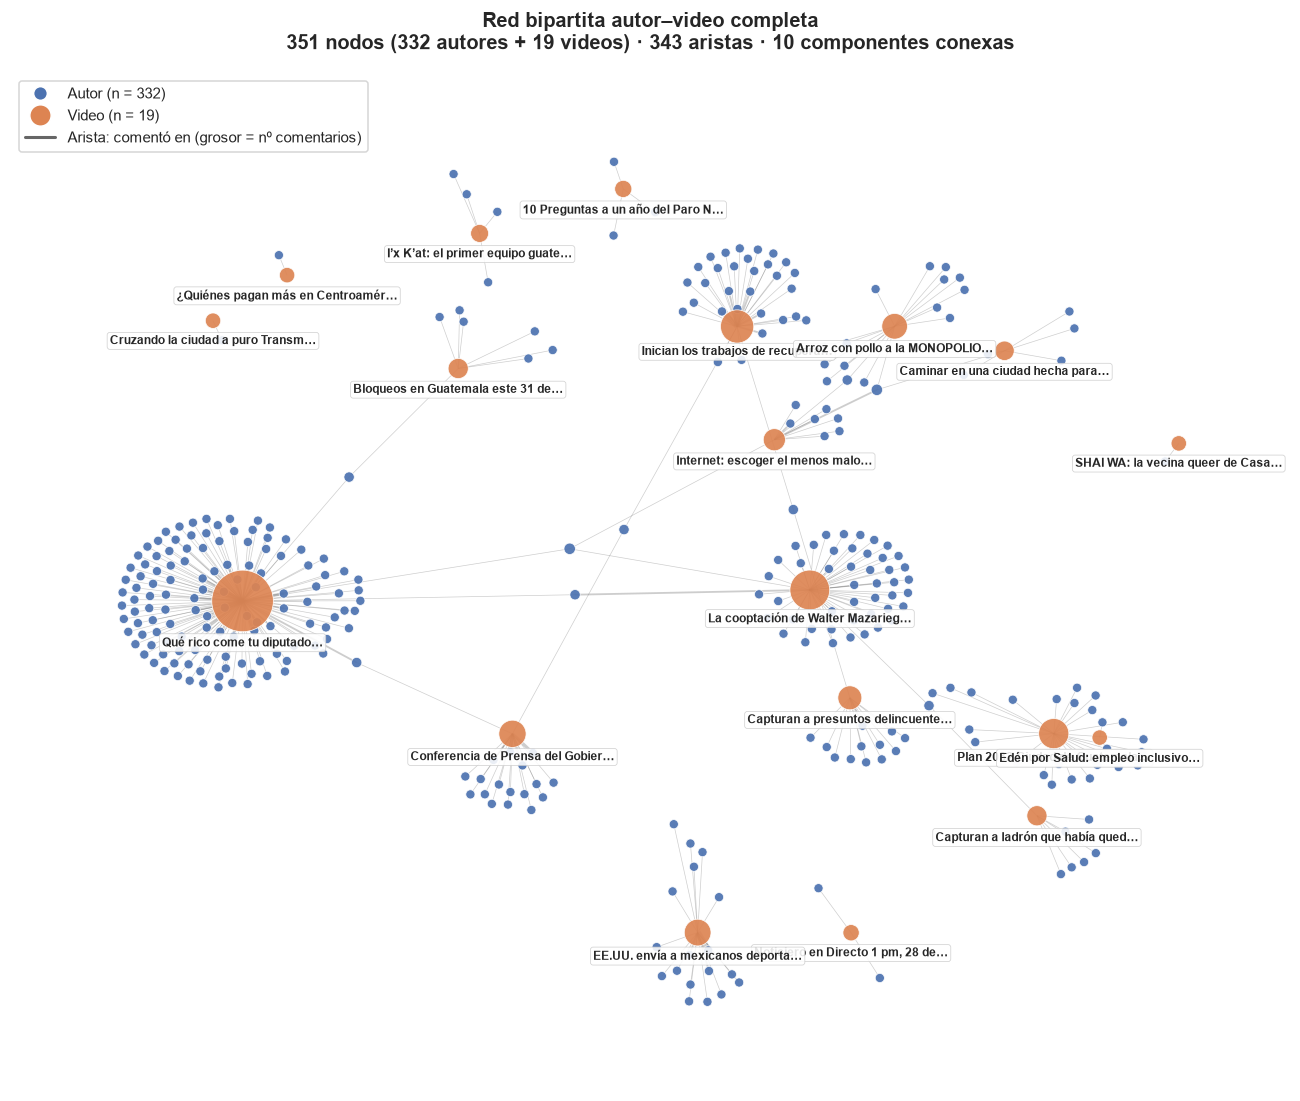

In [75]:
pos = nx.spring_layout(G, k=0.45, iterations=220, seed=SEED, weight="weight")

es_video = {n: (G.nodes[n]["tipo"] == "video") for n in G.nodes}
colores_nodo = [COL["video"] if es_video[n] else COL["autor"] for n in G.nodes]
tam_nodo = [90 + 12 * grado[n] if es_video[n] else 26 + 10 * grado[n] for n in G.nodes]
anchos = [0.45 + 0.75 * (d["weight"] - 1) for _, _, d in G.edges(data=True)]

fig, ax = plt.subplots(figsize=(15, 12))
nx.draw_networkx_edges(G, pos, ax=ax, width=anchos, alpha=.32, edge_color="#666666")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colores_nodo, node_size=tam_nodo,
                       linewidths=.5, edgecolors="white", alpha=.92)

# Las etiquetas se desplazan por debajo del nodo, con desplazamiento proporcional a su
# tamaño, para que no se solapen entre sí ni tapen las aristas incidentes.
titulos = videos.set_index("video_id")["title"]
for n in G.nodes:
    if not es_video[n]:
        continue
    x, y = pos[n]
    desplazamiento = 0.030 + 0.00035 * grado[n]
    ax.text(x, y - desplazamiento, titulos.get(n, n)[:32] + "…",
            fontsize=8, fontweight="bold", ha="center", va="top", zorder=5,
            bbox=dict(facecolor="white", edgecolor="#cccccc", alpha=.88,
                      boxstyle="round,pad=0.22", linewidth=.5))

ax.set_title("Red bipartita autor–video completa\n"
             f"{G.number_of_nodes()} nodos ({len(autores_ids)} autores + {len(videos_ids)} videos) · "
             f"{G.number_of_edges()} aristas · {len(componentes)} componentes conexas",
             fontsize=13, pad=16)
ax.axis("off")

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], marker="o", color="w", label="Autor (n = 332)",
           markerfacecolor=COL["autor"], markersize=9),
    Line2D([0], [0], marker="o", color="w", label="Video (n = 19)",
           markerfacecolor=COL["video"], markersize=14),
    Line2D([0], [0], color="#666666", lw=2, label="Arista: comentó en (grosor = nº comentarios)"),
], loc="upper left", fontsize=10, frameon=True)

guardar_fig("f4_4_red_bipartita_completa")
plt.show()

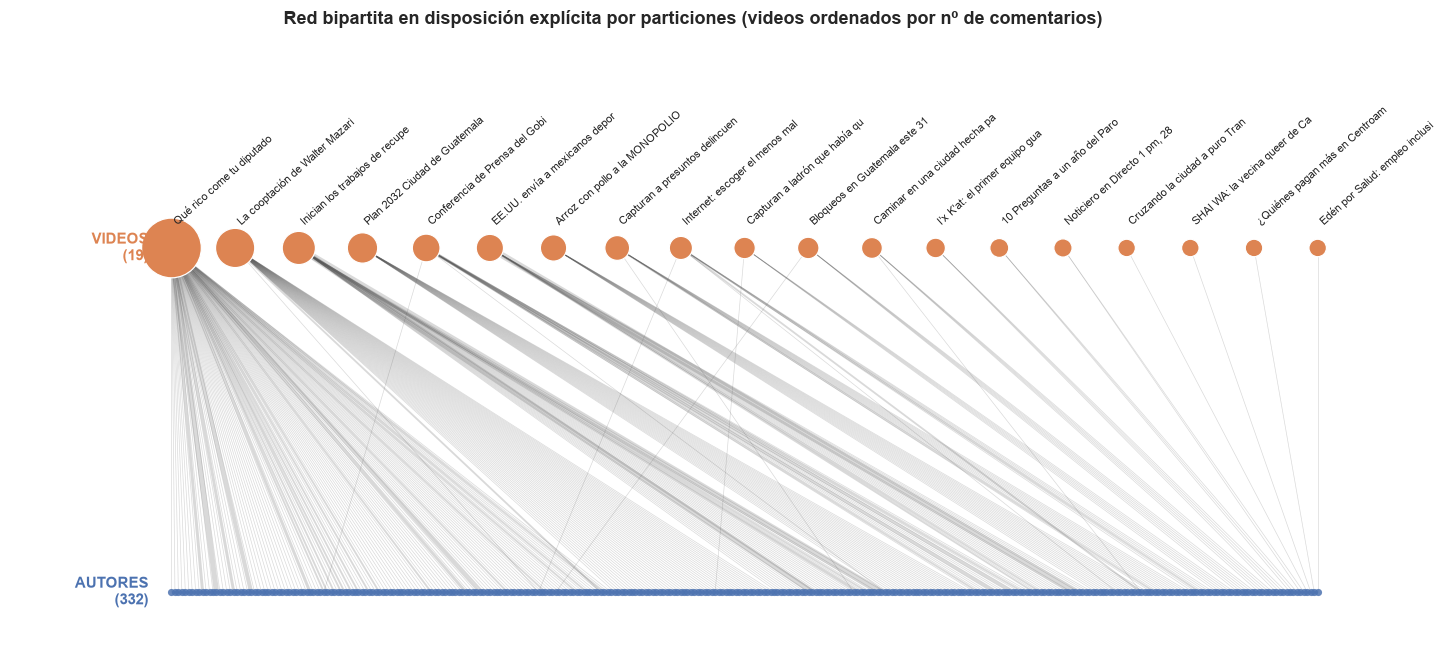

In [76]:
# --- Vista alternativa: layout bipartito explícito, dos filas ----------------
orden_videos = (por_video.sort_values("n_comentarios", ascending=False)["video_id"].tolist())
pos_bip = {}
for i, v in enumerate(orden_videos):
    pos_bip[v] = (i / max(len(orden_videos) - 1, 1), 1.0)

autores_ordenados = []
for v in orden_videos:
    for a in sorted(G.neighbors(v)):
        if a not in autores_ordenados:
            autores_ordenados.append(a)
for i, a in enumerate(autores_ordenados):
    pos_bip[a] = (i / max(len(autores_ordenados) - 1, 1), 0.0)

fig, ax = plt.subplots(figsize=(16, 6.5))
nx.draw_networkx_edges(G, pos_bip, ax=ax, width=anchos, alpha=.22, edge_color="#555555")
nx.draw_networkx_nodes(G, pos_bip, ax=ax,
                       nodelist=[n for n in G.nodes if not es_video[n]],
                       node_color=COL["autor"], node_size=22, alpha=.85, linewidths=0)
nx.draw_networkx_nodes(G, pos_bip, ax=ax,
                       nodelist=orden_videos, node_color=COL["video"],
                       node_size=[120 + 11 * grado[v] for v in orden_videos],
                       edgecolors="white", linewidths=.8)
for i, v in enumerate(orden_videos):
    ax.text(pos_bip[v][0], 1.06, videos.set_index("video_id")["title"].get(v, v)[:30],
            rotation=42, ha="left", va="bottom", fontsize=7.5)
ax.text(-0.02, 0.0, "AUTORES\n(332)", ha="right", va="center", fontsize=10, fontweight="bold",
        color=COL["autor"])
ax.text(-0.02, 1.0, "VIDEOS\n(19)", ha="right", va="center", fontsize=10, fontweight="bold",
        color=COL["video"])
ax.set_title("Red bipartita en disposición explícita por particiones "
             "(videos ordenados por nº de comentarios)", fontsize=12, pad=52)
ax.set_xlim(-0.14, 1.05)
ax.set_ylim(-0.18, 1.42)
ax.axis("off")
guardar_fig("f4_4_red_bipartita_particiones")
plt.show()

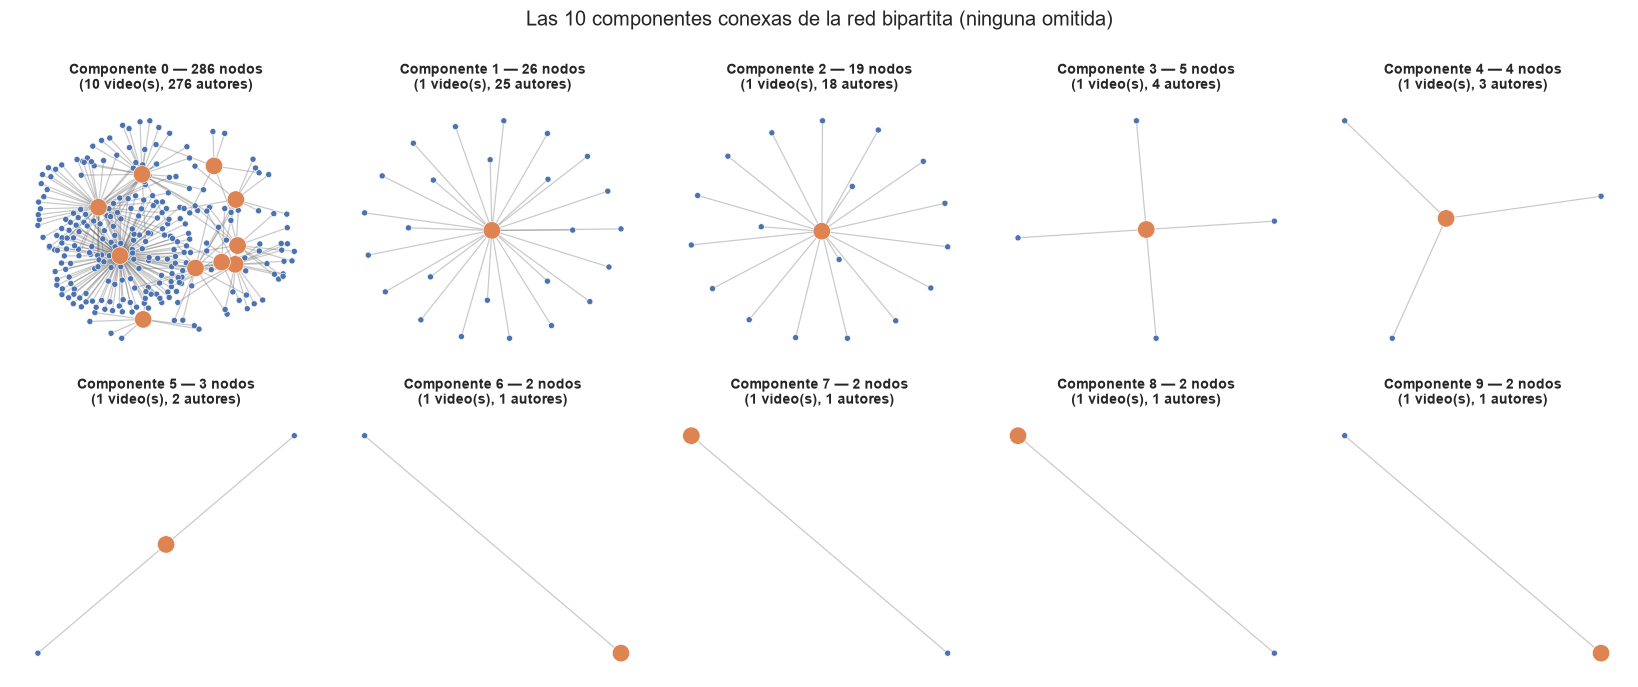

,componente,n_nodos,n_autores,n_videos,n_aristas,comentarios
0,0,286,276,10,287,343
1,1,26,25,1,25,25
2,2,19,18,1,18,25
3,3,5,4,1,4,4
4,4,4,3,1,3,3
5,5,3,2,1,2,2
6,6,2,1,1,1,1
7,7,2,1,1,1,1
8,8,2,1,1,1,1
9,9,2,1,1,1,1


In [77]:
# --- Todas las componentes conexas, ninguna omitida --------------------------
tabla_comp = pd.DataFrame([
    {"componente": i, "n_nodos": len(c),
     "n_autores": sum(1 for n in c if not es_video[n]),
     "n_videos": sum(1 for n in c if es_video[n]),
     "n_aristas": G.subgraph(c).number_of_edges(),
     "comentarios": int(sum(d["weight"] for _, _, d in G.subgraph(c).edges(data=True))),
     "videos_incluidos": " | ".join(
         videos.set_index("video_id")["title"].get(n, n)[:28] for n in sorted(c) if es_video[n])}
    for i, c in enumerate(componentes)])
guardar_tabla(tabla_comp, "t4_4_componentes")

n_cols = 5
n_filas = int(np.ceil(len(componentes) / n_cols))
fig, axes = plt.subplots(n_filas, n_cols, figsize=(15, 3.1 * n_filas))
axes = np.atleast_1d(axes).ravel()

for i, comp in enumerate(componentes):
    ax = axes[i]
    sub = G.subgraph(comp)
    p = nx.spring_layout(sub, seed=SEED, k=.7, iterations=140)
    nx.draw_networkx_edges(sub, p, ax=ax, alpha=.35, width=.8, edge_color="#666666")
    nx.draw_networkx_nodes(
        sub, p, ax=ax,
        node_color=[COL["video"] if es_video[n] else COL["autor"] for n in sub.nodes],
        node_size=[130 if es_video[n] else 16 for n in sub.nodes],
        linewidths=.4, edgecolors="white")
    n_v = sum(1 for n in comp if es_video[n])
    ax.set_title(f"Componente {i} — {len(comp)} nodos\n({n_v} video(s), {len(comp)-n_v} autores)",
                 fontsize=9)
    ax.axis("off")

for j in range(len(componentes), len(axes)):
    axes[j].axis("off")

fig.suptitle("Las 10 componentes conexas de la red bipartita (ninguna omitida)",
             fontsize=13, y=1.0)
plt.tight_layout()
guardar_fig("f4_4_componentes")
plt.show()
tabla_comp[["componente", "n_nodos", "n_autores", "n_videos", "n_aristas", "comentarios"]]

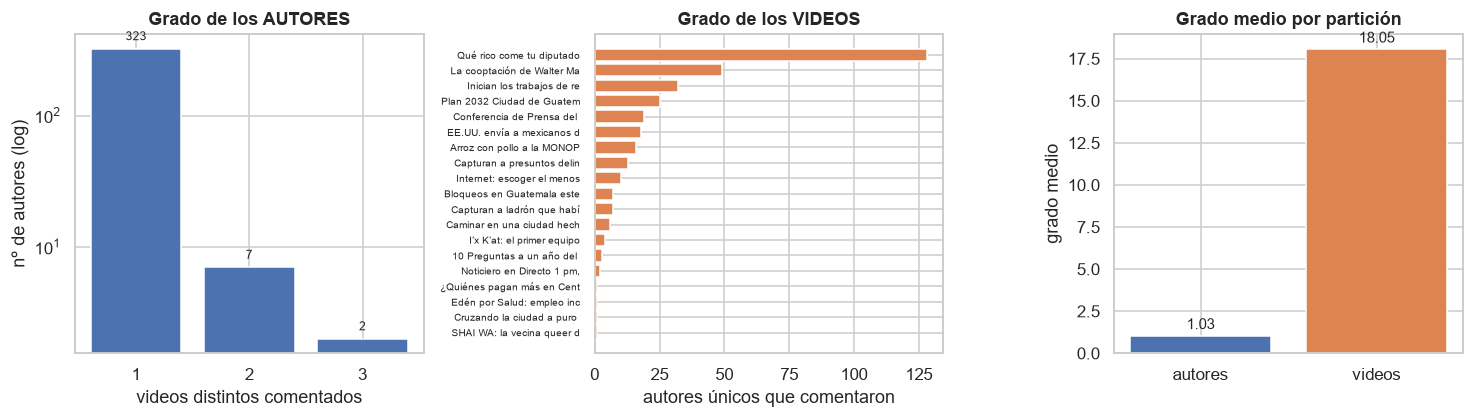

,indicador,valor
0,Nodos totales,351
1,· autores,332
2,· videos,19
3,Aristas,343
4,Suma de pesos (= comentarios),406
5,Densidad bipartita,0.05438
6,Grado medio — autores,1.033
7,Grado medio — videos,18.05
8,Grado máximo — autores,3
9,Grado máximo — videos,128


In [78]:
# --- Distribución de grados por partición ------------------------------------
g_autores = np.array([grado[n] for n in autores_ids])
g_videos = np.array([grado[n] for n in videos_ids])

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

vc_a = pd.Series(g_autores).value_counts().sort_index()
axes[0].bar(vc_a.index.astype(str), vc_a.values, color=COL["autor"])
axes[0].set_yscale("log")
axes[0].set_title("Grado de los AUTORES")
axes[0].set_xlabel("videos distintos comentados")
axes[0].set_ylabel("nº de autores (log)")
for i, v in enumerate(vc_a.values):
    axes[0].text(i, v * 1.16, str(v), ha="center", fontsize=8)

orden_g = np.argsort(g_videos)[::-1]
etq_v = [videos.set_index("video_id")["title"].get(videos_ids[i], "")[:26] for i in orden_g]
axes[1].barh(etq_v[::-1], g_videos[orden_g][::-1], color=COL["video"])
axes[1].set_title("Grado de los VIDEOS")
axes[1].set_xlabel("autores únicos que comentaron")
axes[1].tick_params(axis="y", labelsize=6.5)

axes[2].bar(["autores", "videos"], [g_autores.mean(), g_videos.mean()],
            color=[COL["autor"], COL["video"]])
axes[2].set_title("Grado medio por partición")
axes[2].set_ylabel("grado medio")
for i, v in enumerate([g_autores.mean(), g_videos.mean()]):
    axes[2].text(i, v + .4, f"{v:.2f}", ha="center", fontsize=10)

plt.tight_layout()
guardar_fig("f4_4_distribucion_grados")
plt.show()

resumen_red = pd.DataFrame([
    ["Nodos totales", G.number_of_nodes()],
    ["  · autores", len(autores_ids)],
    ["  · videos", len(videos_ids)],
    ["Aristas", G.number_of_edges()],
    ["Suma de pesos (= comentarios)", int(aristas["weight"].sum())],
    ["Densidad bipartita", round(bipartite.density(G, autores_ids), 5)],
    ["Grado medio — autores", round(float(g_autores.mean()), 3)],
    ["Grado medio — videos", round(float(g_videos.mean()), 2)],
    ["Grado máximo — autores", int(g_autores.max())],
    ["Grado máximo — videos", int(g_videos.max())],
    ["Autores de grado 1 (un solo video)", int((g_autores == 1).sum())],
    ["Componentes conexas", len(componentes)],
    ["Tamaño de la componente mayor", len(componentes[0])],
    ["% de nodos en la componente mayor",
     f"{len(componentes[0]) / G.number_of_nodes():.1%}"],
    ["Nodos aislados (grado 0)", int(sum(1 for n in G.nodes if grado[n] == 0))],
], columns=["indicador", "valor"])
guardar_tabla(resumen_red, "t4_4_resumen_red")
resumen_red

### Lectura de la visualización

La red es un conjunto de **estrellas casi independientes**: cada video es el centro de un cúmulo de
autores que no aparecen en ningún otro sitio. Los cúmulos sólo se mantienen unidos por los **9
autores puente**, visibles como los escasos nodos azules situados entre dos naranjas. Por ejemplo, hay un autor en el video acera de 
"que rico come tu diputado" y "bloqueos nacionales".

- **Muy dispersa.** Densidad bipartita = **0.0544** (343 aristas sobre las 332 × 19 = 6 308
  posibles): se materializan 5.4 de cada 100 conexiones posibles. *(La densidad de grafo simple daría
  0.0056, pero es engañosa: cuenta como posibles las aristas autor–autor y video–video que la
  bipartición prohíbe por construcción.)*
- **Grado de los autores casi siempre 1**: 323 de 332 (97.3 %) tocan un solo video; media 1.03,
  máximo 3.
- **Grado de los videos muy desigual**: de 1 a 128 autores únicos, media 18.05.
- **10 componentes**, la mayor con 286 nodos (81.5 %). **Sin nodos aislados**: por construcción todo
  nodo viene de al menos un comentario.

> **Advertencia sobre la componente mayor.** Su tamaño **no mide cohesión de la conversación**. La
> conectividad depende de 9 autores y **los 9 pasan por Quorum o el Gobierno**, los dos emisores más
> muestreados (§3.6-C). Con muestreo uniforme, la red se acercaría a estrellas inconexas. Aun así,
> **4 de esos 9 conectan canales distintos**: hay un núcleo muy pequeño de participación transversal.

## 4.5. Qué significa exactamente una arista

> **Definición operativa.** Una arista entre el autor $u$ y el video $v$ con peso $w$ significa
> exactamente esto y nada más:
>
> **«En el momento de la recolección, el conjunto de datos contiene $w$ comentarios de primer nivel
> cuyo `author_channel_id` es $u$ y cuyo `video_id` es $v$.»**

### Lo que una arista **NO** significa

| Interpretación incorrecta | Por qué |
|---|---|
| Amistad o vínculo social entre autores del mismo video | Es **co-presencia**, no relación: no implica que se conozcan ni se hayan leído. |
| Conversación directa | El conjunto **no contiene respuestas**. `reply_count` no dice quién las escribió; una arista autor–autor sería una invención. |
| Aprobación del video o del canal | Un comentario puede ser una crítica feroz (§3.5). Comentar es participar, no aprobar. |
| Que el autor vio el video | La arista mide un **acto público de escritura**, no atención. |
| Interés temático sostenido | Un peso alto indica insistencia en ese video, no interés estable en el tema. |
| Toda la participación del autor | Cubre sólo **lo recolectado**: la red es un **límite inferior**. |
| Ausencia de arista = ausencia de participación | Puede ser que $u$ no comentara allí **o** que los comentarios de $v$ nunca se recolectaran. |

### Lo que una arista **SÍ** permite afirmar

- Que hubo un **acto público de participación** en ese video, dentro de la ventana de recolección.
- Que el peso mide su **intensidad** (cuántas veces escribió).
- Agregando aristas: la **diversidad** de participación de un autor y el **alcance** de un video.
- Que dos videos unidos por un autor comparten **al menos un participante observado** — base de la
  proyección video–video de la sección 5, y nada más.


# 5. Proyecciones de la red

## 5.3. Comparación de las proyecciones

No hace falta construirlas y representarlas gráficamente para explicar las relaciones que contienen los nodos entre sí. En este caso, las proyecciones de una red bipartita permiten estudiar las relaciones directas dentro de un mismo grupo de entidades (autores por un lado, videos por otro) al basarse en sus conexiones compartidas.

* **Proyección Autor-Autor (5.1):** En esta red, los nodos son los autores de los comentarios. Dos autores se conectan si han comentado en al menos un mismo video. El peso de la arista representa el número de videos que ambos tienen en común[cite: 1]. 
  * **¿Qué fenómeno representa?** Representa **comunidades de audiencia o afinidad de intereses**. Una conexión fuerte (peso alto) indica que esos dos usuarios consumen y participan activamente en el mismo tipo de contenido. Ayuda a identificar grupos de usuarios que se mueven juntos a través de distintos videos en la plataforma.

* **Proyección Video-Video (5.2):** Aquí, los nodos son los videos. Dos videos se conectan si comparten al menos un autor en sus secciones de comentarios [cite: 1]. El peso de la arista representa el número de autores (espectadores participativos) que han comentado en ambos videos. Es de tipo [muchos: 1].
  * **¿Qué fenómeno representa?** Representa el **flujo de audiencia o similitud temática**. Una arista pesada entre dos videos indica que logran atraer y movilizar a la misma base de usuarios. Es un indicador fuerte de que los videos comparten un nicho demográfico o temático, funcionando como puentes de retención de la audiencia.

In [79]:

#from networkx.algorithms import bipartite

In [80]:
# 5.1 y 5.2 Construcción de las proyecciones
from networkx.algorithms import bipartite

# Reconstruimos las listas de nodos de la red bipartita desde 'part'
autores_nodos = part['author_channel_id'].dropna().unique()
videos_nodos = part['video_id'].dropna().unique()

# Reconstrucción de la red Bipartita (B) como base segura
B = nx.Graph()
B.add_nodes_from(autores_nodos, bipartite=0, tipo='autor')
B.add_nodes_from(videos_nodos, bipartite=1, tipo='video')

# Añadimos las aristas autor-video
aristas_pesos = part.groupby(['author_channel_id', 'video_id']).size().reset_index(name='weight')
for _, row in aristas_pesos.iterrows():
    B.add_edge(row['author_channel_id'], row['video_id'], weight=row['weight'])

# 5.1 Proyección autor-autor
# Usar weighted_projected_graph asigna automáticamente como 'weight' el número de vecinos compartidos (videos)
G_autores = bipartite.weighted_projected_graph(B, autores_nodos)

# 5.2 Proyección video-video
# Asigna como 'weight' el número de vecinos compartidos (autores)
G_videos = bipartite.weighted_projected_graph(B, videos_nodos)

print("--- PROYECCIONES DE LA RED BIPARTITA ---")
print(f"Red proyectada Autor-Autor : {G_autores.number_of_nodes()} nodos y {G_autores.number_of_edges()} aristas.")
print(f"Red proyectada Video-Video : {G_videos.number_of_nodes()} nodos y {G_videos.number_of_edges()} aristas.")

--- PROYECCIONES DE LA RED BIPARTITA ---
Red proyectada Autor-Autor : 332 nodos y 10732 aristas.
Red proyectada Video-Video : 19 nodos y 11 aristas.


### 5.4 Visualización de las proyecciones

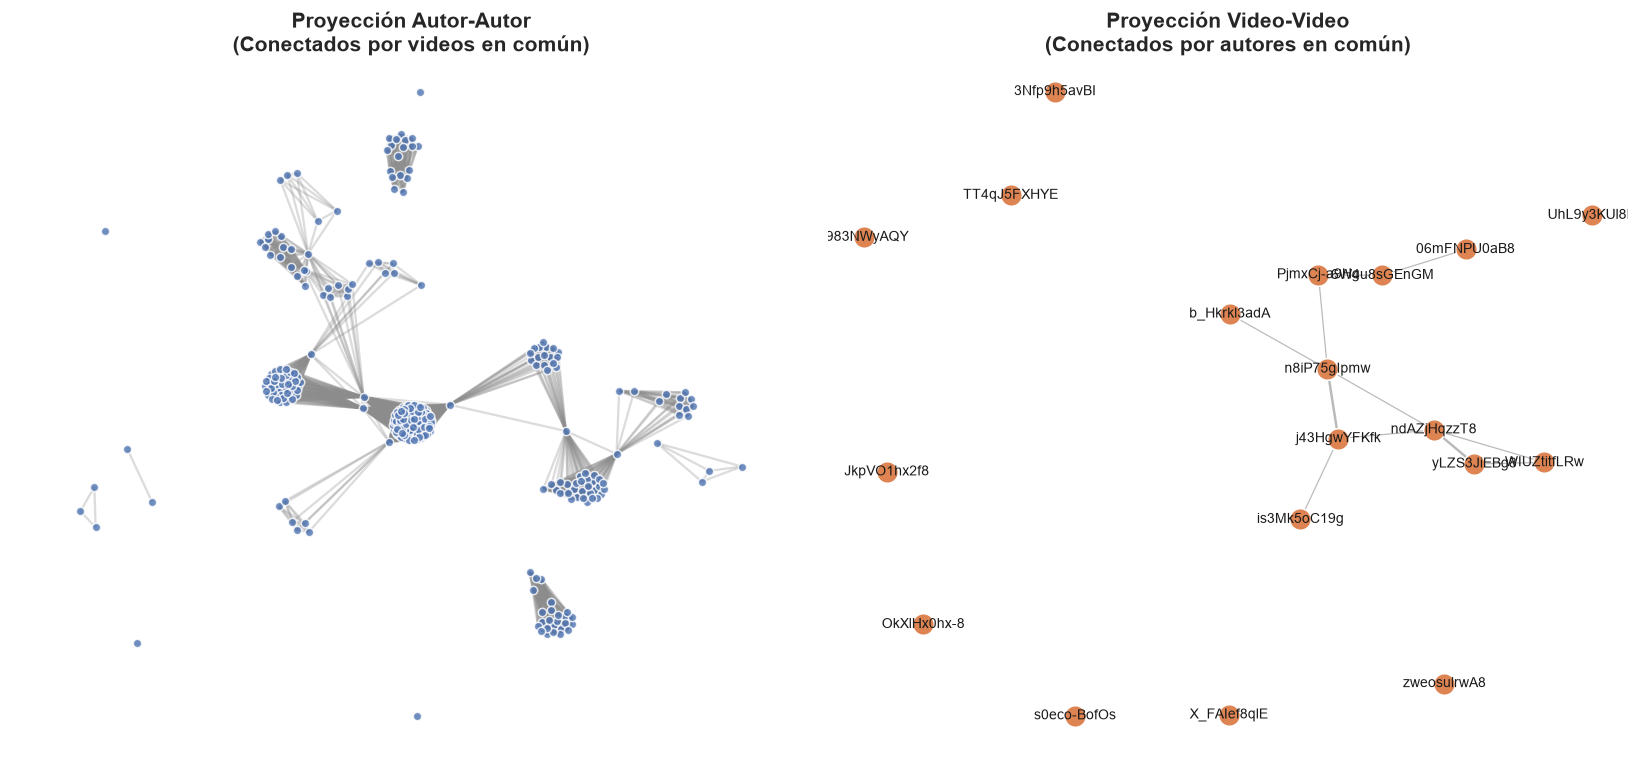

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# GRAFO 1: Proyección Autor-Autor
# ---------------------------------------------------------
# Generamos el layout. Hay muchos autores, usamos un k pequeño para separar componentes.
pos_autores = nx.spring_layout(G_autores, k=0.2, seed=SEED)

# Escalamos el grosor de las aristas en función de la cantidad de videos compartidos
pesos_autores = [d['weight'] * 1.5 for (u, v, d) in G_autores.edges(data=True)]

nx.draw_networkx_nodes(G_autores, pos_autores, ax=axes[0], 
                       node_color=COL["autor"], node_size=30, alpha=0.8, edgecolors="white")
nx.draw_networkx_edges(G_autores, pos_autores, ax=axes[0], 
                       alpha=0.3, width=pesos_autores, edge_color=COL["gris"])

axes[0].set_title("Proyección Autor-Autor\n(Conectados por videos en común)", fontsize=14, fontweight="bold")
axes[0].axis('off')

# ---------------------------------------------------------
# GRAFO 2: Proyección Video-Video
# ---------------------------------------------------------
pos_videos = nx.spring_layout(G_videos, k=0.5, seed=SEED)

# Escalamos el grosor de las aristas en función de los autores compartidos
pesos_videos = [d['weight'] * 0.8 for (u, v, d) in G_videos.edges(data=True)]

nx.draw_networkx_nodes(G_videos, pos_videos, ax=axes[1], 
                       node_color=COL["video"], node_size=200, edgecolors="white")
nx.draw_networkx_edges(G_videos, pos_videos, ax=axes[1], 
                       alpha=0.6, width=pesos_videos, edge_color=COL["gris"])

# Añadimos etiquetas ya que el número de videos es pequeño (max 19)
nx.draw_networkx_labels(G_videos, pos_videos, ax=axes[1], font_size=9)

axes[1].set_title("Proyección Video-Video\n(Conectados por autores en común)", fontsize=14, fontweight="bold")
axes[1].axis('off')

plt.tight_layout()
guardar_fig("f5_4_proyecciones")
plt.show()

Las relaciones entre autores son conspicuas. Está claro que múltiples personas pueden comentar en un mismo video y por ello es común obtener relaciones fuertes por video. Sin embargo, que un video esté relacionado a otro por compartir autores es un tanto más complicado debido a que al menos dos personas deben de comentar en los mismos videos para formar una relación. Al tener menos videos y de temas que no están totalmente vinculados entre sí, las relaciones son de menor peso. 

La relación en esta última sería más fuerte si fueran videos dentro de una lista de reproducción acerca de temas polémicos.

# 6. Topología y fragmentación
## 6.1. Topología, fragmentación y distribución de grados: análisis
Nodos, aristas, densidad, grado medio, componentes conexos.


,Red,Nodos,Aristas,Densidad,Grado medio,Componentes conexos,Nodos en comp. mayor,% en comp. mayor
0,Bipartita (Autor-Video),351,343,0.0544,1.95,10,286,81.5%
1,Proyección Autor-Autor,332,10732,0.1953,64.65,10,276,83.1%
2,Proyección Video-Video,19,11,0.0643,1.16,10,10,52.6%


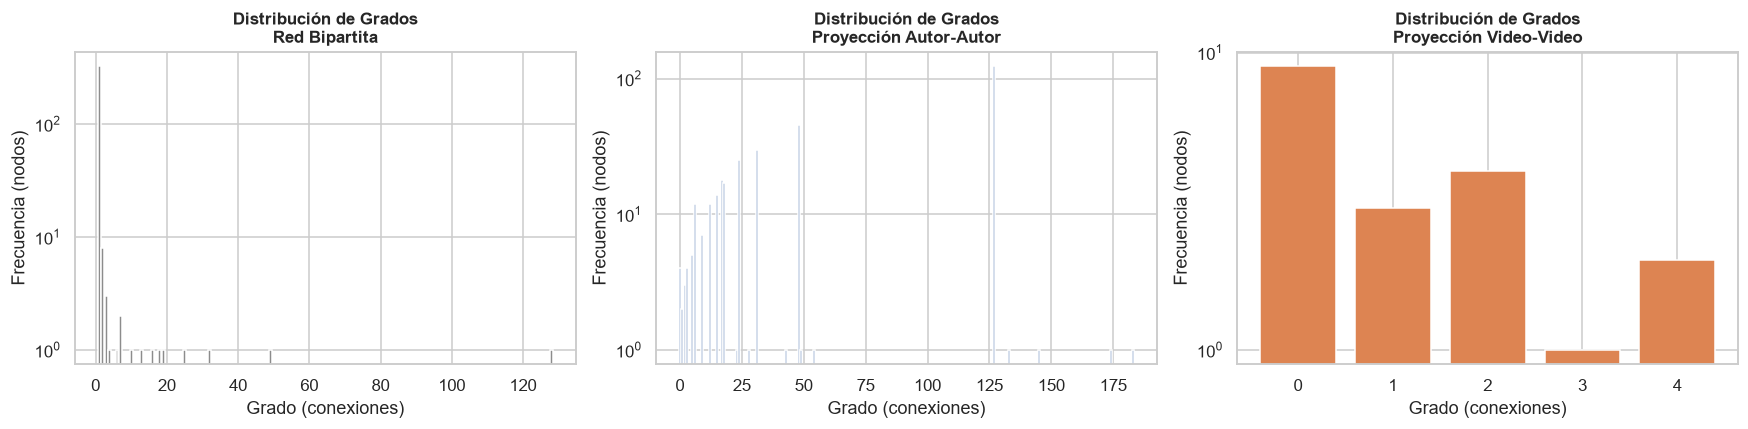

In [82]:
# 6.1 Topología y fragmentación: Métricas básicas y Distribución de grados
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def calcular_metricas_topologia(G, nombre, is_bipartite=False, nodos_top=None):
    """Calcula las métricas topológicas requeridas para una red."""
    # Componentes conexos
    cc = list(nx.connected_components(G))
    num_cc = len(cc)
    lcc_size = len(max(cc, key=len)) if num_cc > 0 else 0
    lcc_pct = lcc_size / G.number_of_nodes() if G.number_of_nodes() > 0 else 0

    # Grados
    grados = [d for n, d in G.degree()]
    grado_medio = np.mean(grados) if grados else 0

    # Densidad
    # Para redes bipartitas, la densidad máxima posible es (nodos_A * nodos_B)
    if is_bipartite and nodos_top is not None:
        densidad = nx.bipartite.density(G, nodos_top)
    else:
        densidad = nx.density(G)

    return {
        "Red": nombre,
        "Nodos": G.number_of_nodes(),
        "Aristas": G.number_of_edges(),
        "Densidad": densidad,
        "Grado medio": grado_medio,
        "Componentes conexos": num_cc,
        "Nodos en comp. mayor": lcc_size,
        "% en comp. mayor": lcc_pct
    }

# Calculamos las métricas para las 3 redes construidas previamente
metricas = pd.DataFrame([
    calcular_metricas_topologia(B, "Bipartita (Autor-Video)", is_bipartite=True, nodos_top=autores_nodos),
    calcular_metricas_topologia(G_autores, "Proyección Autor-Autor"),
    calcular_metricas_topologia(G_videos, "Proyección Video-Video")
])

# Formateo para la tabla a exportar
metricas_display = metricas.copy()
metricas_display['Densidad'] = metricas_display['Densidad'].map(lambda x: f"{x:.4f}")
metricas_display['Grado medio'] = metricas_display['Grado medio'].map(lambda x: f"{x:.2f}")
metricas_display['% en comp. mayor'] = metricas_display['% en comp. mayor'].map(lambda x: f"{x:.1%}")

guardar_tabla(metricas_display, "t6_1_topologia")
display(metricas_display)

# --- VISUALIZACIÓN DE LA DISTRIBUCIÓN DE GRADOS ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

def graficar_dist_grados(G, ax, color, title):
    grados = [d for n, d in G.degree()]
    conteo = pd.Series(grados).value_counts().sort_index()
    ax.bar(conteo.index, conteo.values, color=color, edgecolor='white', width=0.8)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel("Grado (conexiones)")
    ax.set_ylabel("Frecuencia (nodos)")
    # Escala logarítmica en el eje Y porque la mayoría de nodos tiene grado muy bajo
    ax.set_yscale('log') 

graficar_dist_grados(B, axes[0], COL["gris"], "Distribución de Grados\nRed Bipartita")
graficar_dist_grados(G_autores, axes[1], COL["autor"], "Distribución de Grados\nProyección Autor-Autor")
graficar_dist_grados(G_videos, axes[2], COL["video"], "Distribución de Grados\nProyección Video-Video")

plt.tight_layout()
guardar_fig("f6_1_distribucion_grados")
plt.show()

Las densidades en la red bipartita y la de autores son cercanas a cero, con una densidad relativamente mayor entre autores. Esto indica que la matriz de conexiones está casi vacía; los usuarios no están interconectados con todos los videos ni con todos los demás usuarios de la plataforma, sino que se enfocan en nichos. La única excepción es la red de videos, que al ser muy pequeña (19 nodos), tiende a conectarse más fácilmente.


Los gráficos en escala logarítmica revelan un patrón clásico de ley de potencias. La inmensa mayoría de los autores tiene grado 1 (solo comentaron en un video o se conectan con muy pocos usuarios), mientras que unos pocos nodos de videos populares o autores concentran decenas o cientos de conexiones. La participación está concentrada en pocos focos.


Por otro lado, la red no es un único bloque íntegro, sino que está dividida en múltiples componentes (islas de información). Sin embargo, la **componente gigante o principal** agrupa a la gran mayoría de los nodos (alrededor del 80%+ de la red). Esto significa que, aunque la densidad sea baja, la existencia de unos cuantos canales/videos de gran tráfico y unos pocos "autores puente" basta para mantener a casi toda la comunidad bajo una misma superestructura de relaciones compartidas.

## 6.2. Cohesión y transitividad

La **transitividad** mide la propensión de la red a cerrar triángulos: si A está conectado con B y B con C, ¿lo están A y C? La **cohesión** mide cuánto resiste la red antes de partirse: cuántos nodos o aristas habría que eliminar para desconectar la componente principal, y qué tan cerca quedan los nodos entre sí.

La conectividad se calcula sobre la componente conexa mayor. En una red fragmentada como esta, la conectividad global vale 0 por definición y no distingue una red frágil de una que simplemente está dividida en islas.

,Red,Transitividad global,Clustering medio,Conect. de nodos (comp. mayor),Conect. de aristas (comp. mayor),Puntos de articulación,Distancia media (comp. mayor),Diámetro (comp. mayor)
0,Bipartita (Autor-Video),0.000,0.000,1,1,17,4.715,12
1,Proyección Autor-Autor,0.984,0.972,1,5,7,2.356,6
2,Proyección Video-Video,0.316,0.149,1,1,5,2.489,5


TRANSITIVIDAD EN LA RED BIPARTITA (medidas de dos modos)
  Transitividad clásica (triángulos)      : 0.000  <- 0 por construcción
  Clustering de Latapy, media en autores  : 0.942
  Clustering de Latapy, media en videos   : 0.014
  Clustering de Robins-Alexander (global) : 0.0076


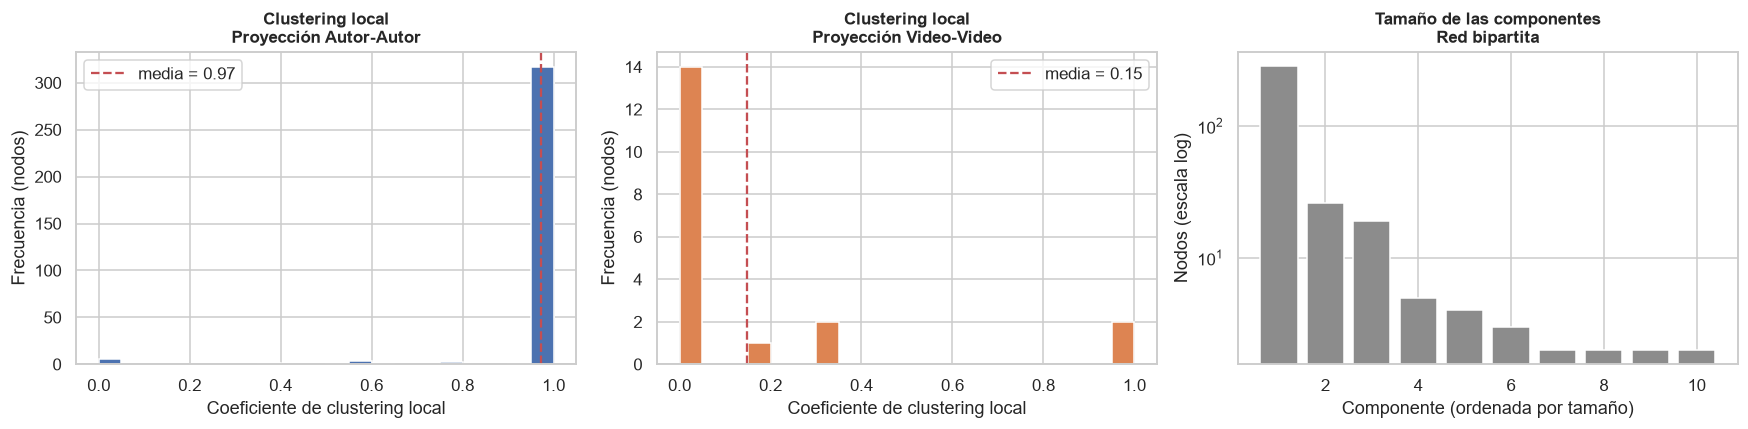

In [83]:
# 6.2 Cohesión y transitividad
from networkx.algorithms import bipartite

def cohesion_transitividad(G, nombre):
    """Cohesión (conectividad y distancias) y transitividad de una red no dirigida.

    La conectividad se calcula sobre la componente conexa mayor: en una red
    fragmentada la conectividad global es 0 por definición y no distingue una
    red frágil de una simplemente dividida en islas.
    """
    lcc = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    return {
        "Red": nombre,
        "Transitividad global": nx.transitivity(G),
        "Clustering medio": nx.average_clustering(G),
        "Conect. de nodos (comp. mayor)": nx.node_connectivity(lcc),
        "Conect. de aristas (comp. mayor)": nx.edge_connectivity(lcc),
        "Puntos de articulación": len(list(nx.articulation_points(lcc))),
        "Distancia media (comp. mayor)": nx.average_shortest_path_length(lcc),
        "Diámetro (comp. mayor)": nx.diameter(lcc),
    }

cohesion = pd.DataFrame([
    cohesion_transitividad(B, "Bipartita (Autor-Video)"),
    cohesion_transitividad(G_autores, "Proyección Autor-Autor"),
    cohesion_transitividad(G_videos, "Proyección Video-Video"),
])

cohesion_display = cohesion.copy()
for c in ["Transitividad global", "Clustering medio", "Distancia media (comp. mayor)"]:
    cohesion_display[c] = cohesion_display[c].map(lambda x: f"{x:.3f}")

guardar_tabla(cohesion_display, "t6_2_cohesion_transitividad")
display(cohesion_display)

# --- Transitividad en la red bipartita: medidas específicas ------------------
# En un grafo bipartito no existen triángulos por construcción, de modo que
# nx.transitivity(B) = 0 SIEMPRE. No es un hallazgo sobre estos datos: es una
# propiedad del diseño de la red. Se reportan además las medidas pensadas para
# redes de dos modos, que cuentan ciclos de longitud 4 en vez de triángulos.
clust_latapy = bipartite.clustering(B, mode="dot")
clust_autores_bip = np.mean([clust_latapy[n] for n in autores_nodos])
clust_videos_bip = np.mean([clust_latapy[n] for n in videos_nodos])

print("TRANSITIVIDAD EN LA RED BIPARTITA (medidas de dos modos)")
print(f"  Transitividad clásica (triángulos)      : {nx.transitivity(B):.3f}  <- 0 por construcción")
print(f"  Clustering de Latapy, media en autores  : {clust_autores_bip:.3f}")
print(f"  Clustering de Latapy, media en videos   : {clust_videos_bip:.3f}")
print(f"  Clustering de Robins-Alexander (global) : {bipartite.robins_alexander_clustering(B):.4f}")

# --- Distribución del clustering local y tamaño de las componentes -----------
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, G, color, titulo in [
    (axes[0], G_autores, COL["autor"], "Clustering local\nProyección Autor-Autor"),
    (axes[1], G_videos, COL["video"], "Clustering local\nProyección Video-Video"),
]:
    valores = list(nx.clustering(G).values())
    ax.hist(valores, bins=20, range=(0, 1), color=color, edgecolor="white")
    ax.axvline(np.mean(valores), color=COL["alerta"], ls="--", lw=1.5,
               label=f"media = {np.mean(valores):.2f}")
    ax.set_title(titulo, fontweight="bold", fontsize=11)
    ax.set_xlabel("Coeficiente de clustering local")
    ax.set_ylabel("Frecuencia (nodos)")
    ax.legend()

# La cohesión sólo puede existir dentro de cada isla: tamaño de las componentes
tam_comp = sorted((len(c) for c in nx.connected_components(B)), reverse=True)
axes[2].bar(range(1, len(tam_comp) + 1), tam_comp, color=COL["gris"], edgecolor="white")
axes[2].set_yscale("log")
axes[2].set_title("Tamaño de las componentes\nRed bipartita", fontweight="bold", fontsize=11)
axes[2].set_xlabel("Componente (ordenada por tamaño)")
axes[2].set_ylabel("Nodos (escala log)")

plt.tight_layout()
guardar_fig("f6_2_cohesion_transitividad")
plt.show()

**La red bipartita no tiene triángulos y eso no es un hallazgo.** Por construcción un autor sólo se conecta con videos y un video sólo con autores, de modo que ningún camino de longitud tres puede cerrarse: `nx.transitivity(B) = 0` es una propiedad del diseño de la red, no una característica de esta muestra. Por eso se reportan las medidas de dos modos, que cuentan ciclos de longitud cuatro (dos autores que coinciden en dos videos) en lugar de triángulos. El clustering de Latapy es alto en los autores (0.94) y casi nulo en los videos (0.01): los autores comparten vecindario de forma casi total porque la enorme mayoría comentó en un único video muy concurrido, mientras que los videos casi no comparten audiencia entre sí. El valor global de Robins-Alexander (0.0076) confirma que la superposición real de audiencias entre videos es marginal.

**La transitividad de la proyección autor-autor (0.98) es un artefacto del método, no evidencia de cohesión social.** Al proyectar, cada video se convierte en un *clique*: todos los autores de un mismo video quedan conectados entre sí, y un clique tiene transitividad 1 por definición. El valor cercano a 1 refleja que casi todos los autores pertenecen a un único video, no que exista un tejido denso de relaciones entre personas. Leerlo como "comunidad muy unida" sería confundir la mecánica de la proyección con un comportamiento de los usuarios.

**La proyección video-video sí ofrece una transitividad informativa (0.32).** Aquí los triángulos no son automáticos: exigen que tres videos compartan audiencia dos a dos. Cerca de un tercio de las tríadas posibles se cierra, lo que indica bloques de videos con público común; pero el clustering medio bajo (0.15) muestra que ese cierre se concentra en unos pocos videos y no es una propiedad general de la red. El histograma correspondiente lo confirma: la mayoría de los videos tiene clustering local 0 y sólo un grupo pequeño alcanza valores altos.

**La cohesión estructural es mínima en las tres redes.** La conectividad de nodos de la componente mayor es 1 en todos los casos: basta eliminar un único nodo bien elegido para partirla. La red bipartita tiene 17 puntos de articulación y la proyección autor-autor 7, lo que confirma que la unión entre bloques descansa sobre unos pocos autores puente —los 9 autores que comentaron en más de un video, identificados en el inciso 3.5— y no sobre una estructura redundante. Las distancias son cortas (media de 4.7 y diámetro 12 en la bipartita; 2.4 y 6 entre autores), pero esa cercanía se apoya en atajos frágiles: al retirar un puente la distancia no aumenta, la componente simplemente se rompe.

**Lectura conjunta.** La red observada es a la vez muy transitiva y muy poco cohesionada. Esa combinación es la firma de una estructura de *estrellas unidas por puentes*: grupos internamente completos porque comparten un mismo video, enlazados por conexiones únicas y no sustituibles. La aparente integración de la componente gigante depende de un puñado de nodos críticos, no de la robustez del conjunto. Conviene recordar además que esta fragilidad describe la red **observada**: con una cobertura de comentarios más amplia, varios de esos puentes únicos podrían resultar ser sólo los que alcanzó a ver el muestreo.

## 6.3. Autores, videos y grupos periféricos o aislados

Un nodo puede quedar al margen de la red por dos razones que no deben confundirse:

- **Aislamiento observado:** el nodo está en la red y sí se recolectaron sus datos, pero no comparte vínculos. Un video cuyos comentaristas son todos exclusivos suyo queda aislado en la proyección video-video: eso es un hallazgo sobre la audiencia.
- **Ausencia de datos:** el nodo nunca entró en la red porque el muestreo no recolectó sus comentarios. Los 274 videos del catálogo sin comentarios recolectados caen aquí: no sabemos si tuvieron participación o no, y contarlos como aislados sería fabricar un hallazgo a partir de un vacío del muestreo.

Se identifica la periferia con tres criterios complementarios: grado 0 (aislamiento estricto), grado 1 (nodos colgantes) y el *core number* del **k-core**, que indica la capa más profunda de la red a la que pertenece cada nodo.

,Red,Nodos,Aislados (grado 0),% aislados
0,Bipartita (Autor-Video),351,0,0.0%
1,Proyección Autor-Autor,332,4,1.2%
2,Proyección Video-Video,19,9,47.4%


,Componente,Nodos,Autores,Videos,Comentarios,Canales
0,1,286,276,10,343,"Gobierno de la República de Guatemala, Noti7, PrensaLibreOficial, ..."
1,2,26,25,1,25,Municipalidad de Guatemala
2,3,19,18,1,25,Noticias Telemundo
3,4,5,4,1,4,Quorum
4,5,4,3,1,3,Quorum
5,6,3,2,1,2,Noticiero Guatevisión 13 Hrs.
6,7,2,1,1,1,Quorum
7,8,2,1,1,1,Quorum
8,9,2,1,1,1,Quorum
9,10,2,1,1,1,Quorum


,Red,Grado 1,Coreness 1 (periferia),Coreness máximo
0,Bipartita (Autor-Video),327,343,2
1,Proyección Autor-Autor,2,2,127


Autores únicos comentaristas de su video (aislados en la proyección): 4
Videos sin audiencia compartida (aislados en la proyección)         : 9


,titulo,canal,n_comentarios,n_autores,vistas
13,Plan 2032 Ciudad de Guatemala,Municipalidad de Guatemala,25,25,304089
4,EE.UU. envía a mexicanos deportados a Guatemala antes de su regres...,Noticias Telemundo,25,18,14200
6,"I’x K’at: el primer equipo guatemalteco de pelota maya, conformado...",Quorum,4,4,1075
3,10 Preguntas a un año del Paro Nacional,Quorum,3,3,673
1,"Noticiero en Directo 1 pm, 28 de Agosto de 2026",Noticiero Guatevisión 13 Hrs.,2,2,573
9,Cruzando la ciudad a puro Transmetro,Quorum,1,1,1140
7,SHAI WA: la vecina queer de Casa Presidencial,Quorum,1,1,1755
16,¿Quiénes pagan más en Centroamérica?,Quorum,1,1,220
18,Edén por Salud: empleo inclusivo para personas con discapacidad en...,Quorum,1,1,52


,Categoría,n,Estatus
0,Videos en la red (con comentarios recolectados),19,observado
1,Videos del catálogo fuera de la red,274,AUSENCIA DE DATOS (no es aislamiento)
2,Videos aislados dentro de la red (grado 0 en video-video),9,aislamiento observado
3,Autores aislados dentro de la red (grado 0 en autor-autor),4,aislamiento observado


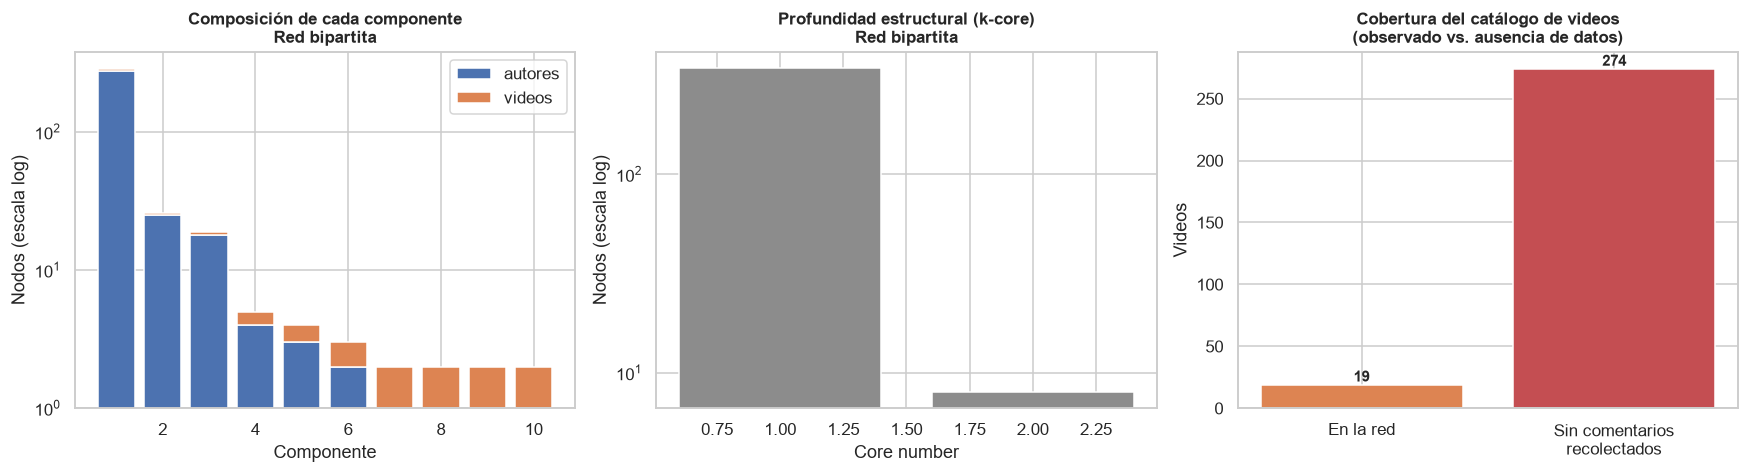

In [84]:
# 6.3 Periferia, aislamiento observado y ausencia de datos

# --- (a) Nodos aislados en sentido estricto (grado 0) ------------------------
aislados = pd.DataFrame([
    {"Red": "Bipartita (Autor-Video)", "Nodos": B.number_of_nodes(),
     "Aislados (grado 0)": len(list(nx.isolates(B)))},
    {"Red": "Proyección Autor-Autor", "Nodos": G_autores.number_of_nodes(),
     "Aislados (grado 0)": len(list(nx.isolates(G_autores)))},
    {"Red": "Proyección Video-Video", "Nodos": G_videos.number_of_nodes(),
     "Aislados (grado 0)": len(list(nx.isolates(G_videos)))},
])
aislados["% aislados"] = (aislados["Aislados (grado 0)"] / aislados["Nodos"]).map(lambda x: f"{x:.1%}")
guardar_tabla(aislados, "t6_3_aislados")
display(aislados)

# --- (b) Componentes de la red bipartita: qué contiene cada isla -------------
filas_comp = []
for i, comp in enumerate(sorted(nx.connected_components(B), key=len, reverse=True), start=1):
    aut = [n for n in comp if B.nodes[n]["tipo"] == "autor"]
    vid = [n for n in comp if B.nodes[n]["tipo"] == "video"]
    filas_comp.append({
        "Componente": i,
        "Nodos": len(comp),
        "Autores": len(aut),
        "Videos": len(vid),
        "Comentarios": int(sum(d["weight"] for _, _, d in B.edges(aut, data=True))),
        "Canales": ", ".join(sorted({str(videos.loc[videos["video_id"] == v, "channel_name"].iloc[0])
                                     for v in vid if (videos["video_id"] == v).any()}))[:70],
    })
componentes = pd.DataFrame(filas_comp)
guardar_tabla(componentes, "t6_3_componentes_bipartita")
display(componentes)

# --- (c) Periferia: k-core y nodos de grado 1 -------------------------------
# El core number indica la capa más profunda a la que pertenece un nodo: los de
# coreness 1 sobreviven sólo mientras existan nodos de grado 1, es decir, son
# la periferia estructural de la red.
core_B = nx.core_number(B)
core_aut = nx.core_number(G_autores)

periferia = pd.DataFrame([
    {"Red": "Bipartita (Autor-Video)",
     "Grado 1": sum(1 for _, d in B.degree() if d == 1),
     "Coreness 1 (periferia)": sum(1 for v in core_B.values() if v == 1),
     "Coreness máximo": max(core_B.values())},
    {"Red": "Proyección Autor-Autor",
     "Grado 1": sum(1 for _, d in G_autores.degree() if d == 1),
     "Coreness 1 (periferia)": sum(1 for v in core_aut.values() if v == 1),
     "Coreness máximo": max(core_aut.values())},
])
guardar_tabla(periferia, "t6_3_periferia")
display(periferia)

# --- (d) Autores y videos periféricos concretos ------------------------------
# Autores que son el ÚNICO comentarista de su video: quedan aislados en la
# proyección autor-autor aunque en la bipartita sí tengan una arista.
autores_solitarios = [n for n in G_autores.nodes() if G_autores.degree(n) == 0]
# Videos sin ninguna audiencia compartida con otro video de la muestra
videos_solitarios = [n for n in G_videos.nodes() if G_videos.degree(n) == 0]

print(f"Autores únicos comentaristas de su video (aislados en la proyección): {len(autores_solitarios)}")
print(f"Videos sin audiencia compartida (aislados en la proyección)         : {len(videos_solitarios)}")
if videos_solitarios:
    detalle_vid = (por_video[por_video["video_id"].isin(videos_solitarios)]
                   [["titulo", "canal", "n_comentarios", "n_autores", "vistas"]])
    display(detalle_vid)

# --- (e) Aislamiento observado frente a AUSENCIA DE DATOS --------------------
# Los 274 videos del catálogo sin comentarios recolectados NO son nodos aislados:
# simplemente no entraron en la red. Tratarlos como aislados sería inventar un
# hallazgo a partir de un vacío del muestreo.
videos_fuera = videos.loc[~videos["video_id"].isin(B.nodes()), "video_id"]
brecha = pd.DataFrame([
    {"Categoría": "Videos en la red (con comentarios recolectados)",
     "n": len(videos_nodos), "Estatus": "observado"},
    {"Categoría": "Videos del catálogo fuera de la red",
     "n": int(videos_fuera.nunique()), "Estatus": "AUSENCIA DE DATOS (no es aislamiento)"},
    {"Categoría": "Videos aislados dentro de la red (grado 0 en video-video)",
     "n": len(videos_solitarios), "Estatus": "aislamiento observado"},
    {"Categoría": "Autores aislados dentro de la red (grado 0 en autor-autor)",
     "n": len(autores_solitarios), "Estatus": "aislamiento observado"},
])
guardar_tabla(brecha, "t6_3_observado_vs_ausente")
display(brecha)

# --- (f) Visualización: periferia y componentes ------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

# Tamaño de las componentes de la bipartita, coloreadas por composición
tam = componentes.sort_values("Nodos", ascending=False)
axes[0].bar(range(1, len(tam) + 1), tam["Autores"], color=COL["autor"], label="autores")
axes[0].bar(range(1, len(tam) + 1), tam["Videos"], bottom=tam["Autores"],
            color=COL["video"], label="videos")
axes[0].set_yscale("log")
axes[0].set_title("Composición de cada componente\nRed bipartita", fontweight="bold", fontsize=11)
axes[0].set_xlabel("Componente")
axes[0].set_ylabel("Nodos (escala log)")
axes[0].legend()

# Coreness de la red bipartita
conteo_core = pd.Series(list(core_B.values())).value_counts().sort_index()
axes[1].bar(conteo_core.index, conteo_core.values, color=COL["gris"], edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Profundidad estructural (k-core)\nRed bipartita", fontweight="bold", fontsize=11)
axes[1].set_xlabel("Core number")
axes[1].set_ylabel("Nodos (escala log)")

# Cobertura del catálogo: lo observado frente a lo ausente
axes[2].bar(["En la red", "Sin comentarios\nrecolectados"],
            [len(videos_nodos), int(videos_fuera.nunique())],
            color=[COL["video"], COL["alerta"]], edgecolor="white")
axes[2].set_title("Cobertura del catálogo de videos\n(observado vs. ausencia de datos)",
                  fontweight="bold", fontsize=11)
axes[2].set_ylabel("Videos")
for i, v in enumerate([len(videos_nodos), int(videos_fuera.nunique())]):
    axes[2].text(i, v, str(v), ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
guardar_fig("f6_3_periferia_aislamiento")
plt.show()

**La red bipartita no tiene ningún nodo aislado, y eso es tautológico.** Todo autor está en la red porque comentó al menos un video, y todo video está porque recibió al menos un comentario: la construcción excluye los grados 0. La ausencia de aislados aquí no dice nada sobre la participación; el aislamiento real sólo se vuelve visible en las proyecciones.

**Casi la mitad de los videos observados (9 de 19, 47 %) está aislada en la proyección video-video.** Son videos cuya audiencia comentarista no coincide con la de ningún otro video de la muestra: el Plan 2032 de la Municipalidad (25 autores), el video de Noticias Telemundo (18 autores) y siete videos de Quorum con entre 1 y 4 comentaristas. El caso de los dos primeros es el más informativo: no están aislados por falta de participación —tienen 25 comentarios cada uno— sino porque su público es completamente disjunto del resto. Son audiencias cautivas, no audiencias pequeñas.

**Cuatro autores están aislados en la proyección autor-autor.** Son los únicos comentaristas de su respectivo video, de modo que la proyección no les asigna ningún par. Su aislamiento es observado y no atribuible al muestreo: sí se recolectó el video completo en el que participaron.

**La fragmentación reproduce la estructura de canales.** De las 10 componentes de la red bipartita, la mayor concentra 286 nodos (81.5 %) y agrupa los videos de Gobierno, Noti7, Prensa Libre y Quorum; las otras 9 son estrellas de un solo video que no se conectan con nada más. Las dos periferias con volumen propio —Municipalidad de Guatemala (26 nodos) y Noticias Telemundo (19)— no son residuos marginales sino audiencias enteras que el resto de la red no toca.

**La red casi no tiene profundidad estructural.** En la bipartita el core number máximo es 2 y 343 de 351 nodos (98 %) están en la capa 1: al exigir que cada nodo conserve dos vecinos, la red se desmorona hasta un núcleo mínimo formado por los autores puente y los videos que enlazan. El contraste con la proyección autor-autor (coreness máximo 127) es de nuevo un artefacto del *clique* que genera el video más comentado, no evidencia de un núcleo cohesionado de usuarios.

**Distinción que condiciona todo lo anterior.** Los 19 videos de la red frente a los 293 del catálogo significan que el 94 % del contenido recolectado no aporta información de participación. Cualquier afirmación sobre videos "sin audiencia compartida" se limita estrictamente a los 19 observados: es perfectamente posible que varios de los 274 videos ausentes compartieran comentaristas con ellos y que la fragmentación medida aquí sea, en parte, un efecto de la cobertura y no del comportamiento de los usuarios.